# Indonesia E-Commerce Data Analysis

## Project Overview

This project analyzes Indonesian e-commerce transaction data to
identify sales performance, product performance, shipping behavior,
cancellation patterns, return performance, and business opportunities.

The analysis follows an end-to-end Data Analyst workflow:

Data Understanding → Data Quality → Data Validation → EDA →
Dataset Finalization → Business Analysis → Business Insight →
Final Data Quality Validation → Recommendation

## Business Objectives

The analysis aims to:

1. Understand the structure and quality of the dataset.
2. Identify sales and payment patterns.
3. Analyze product and category performance.
4. Evaluate return and cancellation behavior.
5. Identify operational issues affecting transactions.
6. Generate actionable business insights and recommendations.



In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Library berhasil di-load!")

Library berhasil di-load!


In [3]:
import csv

file_path = "../data/raw/all_months_clean.csv"

with open(file_path, "r", encoding="utf-8-sig", errors="replace") as f:
    sample = f.read(10000)

try:
    dialect = csv.Sniffer().sniff(sample)
    print("Delimiter terdeteksi:", repr(dialect.delimiter))
except Exception as e:
    print("Delimiter tidak dapat dideteksi otomatis.")
    print(e)

Delimiter terdeteksi: ';'


In [4]:
file_path = "../data/raw/all_months_clean.csv"

import csv

with open(file_path, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
    reader = csv.reader(f)

    for i, row in enumerate(reader):
        print(f"Baris {i+1}: {len(row)} kolom -> {row[:5]}")
        
        if i >= 9:
            break

Baris 1: 1 kolom -> ['order_id;total_qty;total_weight_gr;total_returned_qty;Total Diskon;product_categories;num_product_categories;Status Pesanan;Alasan Pembatalan;Opsi Pengiriman;Metode Pembayaran;Kota/Kabupaten;Provinsi;Ongkos Kirim Dibayar oleh Pembeli;Estimasi Potongan Biaya Pengiriman;Total Pembayaran;Perkiraan Ongkos Kirim;Waktu Pesanan Dibuat;source_file']
Baris 2: 1 kolom -> ['ORD_0000001;2;2000;0;0;Celengan;1;Selesai;;Reguler (Cashless)-SPX Standard;Saldo ShopeePay;KOTA SERANG;BANTEN;0;10000;38300;10000;2024-04-01 00:15;AprilSales2024.xlsx']
Baris 3: 1 kolom -> ['ORD_0000002;1;500;0;0;Celengan;1;Selesai;;Hemat Kargo-SPX Hemat;COD (Bayar di Tempat);KOTA SEMARANG;JAWA TENGAH;0;14500;18576;14500;2024-04-01 01:47;AprilSales2024.xlsx']
Baris 4: 1 kolom -> ['ORD_0000003;1;500;0;0;Celengan;1;Selesai;;Hemat Kargo-SPX Hemat;SeaBank Bayar Instan;KAB. BOGOR;JAWA BARAT;0;8000;7069;8000;2024-04-01 04:25;AprilSales2024.xlsx']
Baris 5: 1 kolom -> ['ORD_0000004;2;400;0;0;Mangkok Sambal / Saus

## Dataset Information

- Dataset type: Indonesian e-commerce transaction data
- Final dataset: `df_final`
- Total transactions: 20,848
- Total columns: 20
- Analysis scope: sales, products, payment, shipping,
  cancellation, and return performance

In [ ]:
# ==========================================
# STEP 1 — DATA LOADING & DATASET OVERVIEW
# ==========================================

file_path = "../data/raw/all_months_clean.csv"

df = pd.read_csv(
    file_path,
    sep=";",
    encoding="utf-8-sig"
)

print("Dataset berhasil dimuat!")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")

Dataset berhasil dimuat!
Jumlah baris  : 20,848
Jumlah kolom : 19


In [6]:
df.head()

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,AprilSales2024.xlsx
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,AprilSales2024.xlsx
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,AprilSales2024.xlsx
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,AprilSales2024.xlsx
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,AprilSales2024.xlsx


In [7]:
df.columns.tolist()

['order_id',
 'total_qty',
 'total_weight_gr',
 'total_returned_qty',
 'Total Diskon',
 'product_categories',
 'num_product_categories',
 'Status Pesanan',
 'Alasan Pembatalan',
 'Opsi Pengiriman',
 'Metode Pembayaran',
 'Kota/Kabupaten',
 'Provinsi',
 'Ongkos Kirim Dibayar oleh Pembeli',
 'Estimasi Potongan Biaya Pengiriman',
 'Total Pembayaran',
 'Perkiraan Ongkos Kirim',
 'Waktu Pesanan Dibuat',
 'source_file']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   order_id                            20848 non-null  str  
 1   total_qty                           20848 non-null  int64
 2   total_weight_gr                     20848 non-null  int64
 3   total_returned_qty                  20848 non-null  int64
 4   Total Diskon                        20848 non-null  int64
 5   product_categories                  20848 non-null  str  
 6   num_product_categories              20848 non-null  int64
 7   Status Pesanan                      20848 non-null  str  
 8   Alasan Pembatalan                   2830 non-null   str  
 9   Opsi Pengiriman                     20848 non-null  str  
 10  Metode Pembayaran                   20848 non-null  str  
 11  Kota/Kabupaten                      20848 non-null  str  
 12  Provinsi       

In [ ]:
# ==========================================
# STEP 2 — INITIAL DATA QUALITY ASSESSMENT
# ==========================================

print("=== MISSING VALUES ===")
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

=== MISSING VALUES ===
Alasan Pembatalan       18018
Waktu Pesanan Dibuat     1980
dtype: int64


In [10]:
# Persentase missing value

missing_pct = (df.isnull().sum() / len(df) * 100)

missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("=== PERSENTASE MISSING VALUE ===")
print(missing_pct.round(2))

=== PERSENTASE MISSING VALUE ===
Alasan Pembatalan       86.43
Waktu Pesanan Dibuat     9.50
dtype: float64


In [ ]:
# ==========================================
# STEP 3 — DATA CONSISTENCY & DUPLICATE VALIDATION
# ==========================================

pd.crosstab(
    df["Status Pesanan"],
    df["Alasan Pembatalan"].isna(),
    margins=True
)

Alasan Pembatalan,False,True,All
Status Pesanan,,,
Batal,2830,0,2830
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-05.",0,25,25
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-06.",0,34,34
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-07.",0,34,34
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-08.",0,38,38
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-09.",0,22,22
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-10.",0,6,6
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-11.",0,2,2
Sedang Dikirim,0,59,59


In [12]:
# Melihat status pesanan
df["Status Pesanan"].value_counts(dropna=False)

Status Pesanan
Selesai                                                                                   17768
Batal                                                                                      2830
Sedang Dikirim                                                                               59
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-08.       38
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-06.       34
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-07.       34
Telah Dikirim                                                                                30
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-05.       25
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-09.       22
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-10.        6
Pesanan diterima, namun P

In [ ]:
# ==========================================
# STEP 3.1 — DUPLICATE ROW CHECK
# ==========================================

duplicate_rows = df.duplicated().sum()

print(f"Jumlah duplicate seluruh baris : {duplicate_rows}")
print(f"Persentase duplicate            : {(duplicate_rows / len(df) * 100):.2f}%")

Jumlah duplicate seluruh baris : 0
Persentase duplicate            : 0.00%


In [ ]:
# ==========================================
# STEP 3.2 — COLUMN UNIQUENESS CHECK
# ==========================================

print("=== JUMLAH NILAI UNIK SETIAP KOLOM ===")

for column in df.columns:
    unique_count = df[column].nunique()
    duplicate_count = df[column].duplicated().sum()

    print(f"\nKolom              : {column}")
    print(f"Jumlah nilai unik  : {unique_count}")
    print(f"Jumlah nilai berulang : {duplicate_count}")

=== JUMLAH NILAI UNIK SETIAP KOLOM ===

Kolom              : order_id
Jumlah nilai unik  : 20848
Jumlah nilai berulang : 0

Kolom              : total_qty
Jumlah nilai unik  : 59
Jumlah nilai berulang : 20789

Kolom              : total_weight_gr
Jumlah nilai unik  : 632
Jumlah nilai berulang : 20216

Kolom              : total_returned_qty
Jumlah nilai unik  : 10
Jumlah nilai berulang : 20838

Kolom              : Total Diskon
Jumlah nilai unik  : 49
Jumlah nilai berulang : 20799

Kolom              : product_categories
Jumlah nilai unik  : 679
Jumlah nilai berulang : 20169

Kolom              : num_product_categories
Jumlah nilai unik  : 10
Jumlah nilai berulang : 20838

Kolom              : Status Pesanan
Jumlah nilai unik  : 11
Jumlah nilai berulang : 20837

Kolom              : Alasan Pembatalan
Jumlah nilai unik  : 18
Jumlah nilai berulang : 20829

Kolom              : Opsi Pengiriman
Jumlah nilai unik  : 45
Jumlah nilai berulang : 20803

Kolom              : Metode Pembayaran
Ju

In [ ]:
# ==========================================
# STEP 3.3 — IDENTIFIER VALIDATION
# ==========================================

print("=== CEK KOLOM IDENTIFIER ===")

for column in df.columns:
    duplicate_count = df[column].duplicated().sum()

    if duplicate_count > 0:
        print(
            f"{column} -> "
            f"{duplicate_count} nilai berulang"
        )

=== CEK KOLOM IDENTIFIER ===
total_qty -> 20789 nilai berulang
total_weight_gr -> 20216 nilai berulang
total_returned_qty -> 20838 nilai berulang
Total Diskon -> 20799 nilai berulang
product_categories -> 20169 nilai berulang
num_product_categories -> 20838 nilai berulang
Status Pesanan -> 20837 nilai berulang
Alasan Pembatalan -> 20829 nilai berulang
Opsi Pengiriman -> 20803 nilai berulang
Metode Pembayaran -> 20836 nilai berulang
Kota/Kabupaten -> 20424 nilai berulang
Provinsi -> 20814 nilai berulang
Ongkos Kirim Dibayar oleh Pembeli -> 20348 nilai berulang
Estimasi Potongan Biaya Pengiriman -> 20515 nilai berulang
Total Pembayaran -> 15039 nilai berulang
Perkiraan Ongkos Kirim -> 20155 nilai berulang
Waktu Pesanan Dibuat -> 2256 nilai berulang
source_file -> 20824 nilai berulang


In [ ]:
# ==========================================
# STEP 3.4 — ORDER ID UNIQUENESS VALIDATION
# ==========================================

print("=== VALIDASI ORDER ID ===")

total_data = len(df)
unique_order_id = df["order_id"].nunique()
missing_order_id = df["order_id"].isna().sum()
duplicate_order_id = df["order_id"].duplicated().sum()

print(f"Total baris data        : {total_data}")
print(f"Jumlah order_id unik    : {unique_order_id}")
print(f"Missing order_id        : {missing_order_id}")
print(f"Duplicate order_id      : {duplicate_order_id}")

# Validasi
if (
    total_data == unique_order_id
    and missing_order_id == 0
    and duplicate_order_id == 0
):
    print("\nSTATUS : VALID")
    print("Setiap baris memiliki order_id yang unik.")
else:
    print("\nSTATUS : PERLU PEMERIKSAAN")

=== VALIDASI ORDER ID ===
Total baris data        : 20848
Jumlah order_id unik    : 20848
Missing order_id        : 0
Duplicate order_id      : 0

STATUS : VALID
Setiap baris memiliki order_id yang unik.


In [ ]:
# ==========================================
# STEP 4 — MISSING VALUE & BUSINESS CONTEXT ANALYSIS
# ==========================================


# ==========================================
# STEP 4.1 — MISSING VALUE SUMMARY
# ==========================================

missing_summary = pd.DataFrame({
    "Jumlah Data": len(df),
    "Missing": df.isnull().sum(),
    "Persentase Missing (%)": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(missing_summary)

,Jumlah Data,Missing,Persentase Missing (%)
order_id,20848,0,0.00
total_qty,20848,0,0.00
total_weight_gr,20848,0,0.00
total_returned_qty,20848,0,0.00
Total Diskon,20848,0,0.00
product_categories,20848,0,0.00
num_product_categories,20848,0,0.00
Status Pesanan,20848,0,0.00
Alasan Pembatalan,20848,18018,86.43
Opsi Pengiriman,20848,0,0.00


In [ ]:
# ==========================================
# STEP 4.2 — CANCELLATION REASON ANALYSIS
# ==========================================

print("=== STATUS PESANAN ===")
display(df["Status Pesanan"].value_counts(dropna=False))

print("\n=== STATUS PESANAN vs ALASAN PEMBATALAN ===")

status_cancellation = pd.crosstab(
    df["Status Pesanan"],
    df["Alasan Pembatalan"],
    dropna=False
)

display(status_cancellation)

=== STATUS PESANAN ===


Status Pesanan
Selesai                                                                                   17768
Batal                                                                                      2830
Sedang Dikirim                                                                               59
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-08.       38
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-06.       34
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-07.       34
Telah Dikirim                                                                                30
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-05.       25
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-09.       22
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-10.        6
Pesanan diterima, namun P


=== STATUS PESANAN vs ALASAN PEMBATALAN ===


Alasan Pembatalan,Dibatalkan oleh Pembeli. Alasan: Lainnya,Dibatalkan oleh Pembeli. Alasan: Lainnya/ berubah pikiran,Dibatalkan oleh Pembeli. Alasan: Menemukan yang lebih murah,Dibatalkan oleh Pembeli. Alasan: Need to change delivery address,Dibatalkan oleh Pembeli. Alasan: Penjual tidak responsif terhadap pertanyaan Pembeli,Dibatalkan oleh Pembeli. Alasan: Perlu mengubah Voucher,Dibatalkan oleh Pembeli. Alasan: Perlu mengubah alamat pengiriman,Dibatalkan oleh Pembeli. Alasan: Perlu mengubah pesanan,Dibatalkan oleh Pembeli. Alasan: Proses pembayaran sulit,Dibatalkan oleh Pembeli. Alasan: Tidak ingin membeli lagi,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan yang Ada,Dibatalkan oleh Penjual. Alasan: Produk habis,Dibatalkan secara otomatis oleh sistem. Alasan: Lainnya,Dibatalkan secara otomatis oleh sistem. Alasan: Paket hilang di perjalanan. Kompensasi yang memenuhi syarat telah dikreditkan ke Saldo Penjual-mu.,Dibatalkan secara otomatis oleh sistem. Alasan: Pengiriman gagal,Dibatalkan secara otomatis oleh sistem. Alasan: Penjual gagal mengirimkan pesanan tepat waktu,Dibatalkan secara otomatis oleh sistem. Alasan: Penjual tidak mengatur pengiriman tepat waktu,Dibatalkan secara otomatis oleh sistem. Alasan: Pesanan belum dibayar,NaN
Status Pesanan,,,,,,,,,,,,,,,,,,,
Batal,48,662,20,306,33,36,79,113,34,23,558,14,4,22,255,113,63,447,0
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-05.",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-06.",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-07.",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-08.",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,38
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-09.",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-10.",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-11.",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
Sedang Dikirim,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,59


In [ ]:
# ==========================================
# STEP 4.3 — MISSING CANCELLATION REASON BY ORDER STATUS
# ==========================================

cancellation_analysis = (
    df.groupby("Status Pesanan")["Alasan Pembatalan"]
    .apply(lambda x: x.isna().sum())
    .reset_index(name="Missing Alasan Pembatalan")
)

display(cancellation_analysis)

,Status Pesanan,Missing Alasan Pembatalan
0,Batal,0
1,"Pesanan diterima, namun Pembeli masih dapat me...",25
2,"Pesanan diterima, namun Pembeli masih dapat me...",34
3,"Pesanan diterima, namun Pembeli masih dapat me...",34
4,"Pesanan diterima, namun Pembeli masih dapat me...",38
5,"Pesanan diterima, namun Pembeli masih dapat me...",22
6,"Pesanan diterima, namun Pembeli masih dapat me...",6
7,"Pesanan diterima, namun Pembeli masih dapat me...",2
8,Sedang Dikirim,59
9,Selesai,17768


In [ ]:
# ==========================================
# STEP 4.4 — ORDER CREATION TIME MISSING ANALYSIS
# ==========================================

print("=== ANALISIS WAKTU PESANAN DIBUAT ===")

total_data = len(df)
missing_waktu = df["Waktu Pesanan Dibuat"].isna().sum()
tersedia_waktu = df["Waktu Pesanan Dibuat"].notna().sum()

print(f"Total data              : {total_data}")
print(f"Waktu tersedia          : {tersedia_waktu}")
print(f"Waktu missing           : {missing_waktu}")
print(
    f"Persentase missing      : "
    f"{(missing_waktu / total_data * 100):.2f}%"
)

=== ANALISIS WAKTU PESANAN DIBUAT ===
Total data              : 20848
Waktu tersedia          : 18868
Waktu missing           : 1980
Persentase missing      : 9.50%


In [ ]:
# ==========================================
# STEP 4.5 — MISSING ORDER TIME PROFILE
# ==========================================

missing_waktu_data = df[
    df["Waktu Pesanan Dibuat"].isna()
]

print("Jumlah data dengan waktu pesanan missing:",
      len(missing_waktu_data))

display(missing_waktu_data.head(10))

Jumlah data dengan waktu pesanan missing: 1980


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
3995,ORD_0003996,2,3400,0,0,Nampan / Tray,1,Selesai,NaN,Hemat Kargo-SPX Hemat,Saldo ShopeePay,KOTA TANGERANG,BANTEN,7200,20000,27200,27200,NaN,DecemberSales2024.xlsx
3996,ORD_0003997,1,100,0,0,Aksesoris Pintu,1,Batal,Dibatalkan secara otomatis oleh sistem. Alasan...,Reguler (Cashless),Online Payment,KAB. BOGOR,JAWA BARAT,0,0,0,9500,NaN,DecemberSales2024.xlsx
3997,ORD_0003998,1,750,0,0,Baskom / Mangkok Besar,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA PEMATANG SIANTAR,SUMATERA UTARA,11300,25000,46552,36300,NaN,DecemberSales2024.xlsx
3998,ORD_0003999,1,150,0,0,Pengolah Bumbu / Sayur,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,COD (Bayar di Tempat),KAB. NGAWI,JAWA TIMUR,0,17000,31160,17000,NaN,DecemberSales2024.xlsx
3999,ORD_0004000,1,100,0,0,Seal / Baut / Roof,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KAB. CIREBON,JAWA BARAT,0,15000,19200,15000,NaN,DecemberSales2024.xlsx
4000,ORD_0004001,1,100,0,0,Aksesoris Pintu,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA JAKARTA SELATAN,DKI JAKARTA,0,10000,11000,10000,NaN,DecemberSales2024.xlsx
4001,ORD_0004002,3,300,0,0,Seal / Baut / Roof,1,Batal,Dibatalkan secara otomatis oleh sistem. Alasan...,Reguler (Cashless),Online Payment,KAB. BANDUNG BARAT,JAWA BARAT,0,0,0,17000,NaN,DecemberSales2024.xlsx
4002,ORD_0004003,2,200,0,0,Saringan / Strainer,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAKARTA BARAT,DKI JAKARTA,0,8000,33240,8000,NaN,DecemberSales2024.xlsx
4003,ORD_0004004,2,2000,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,Online Payment,KOTA BOGOR,JAWA BARAT,0,8000,35800,8000,NaN,DecemberSales2024.xlsx
4004,ORD_0004005,1,500,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,SeaBank Bayar Instan,KAB. TANGERANG,BANTEN,0,9500,18000,9500,NaN,DecemberSales2024.xlsx


In [ ]:
# ==========================================
# STEP 4.6 — MISSING ORDER TIME DISTRIBUTION BY ORDER STATUS
# ==========================================

missing_waktu_status = (
    df[df["Waktu Pesanan Dibuat"].isna()]
    ["Status Pesanan"]
    .value_counts(dropna=False)
    .reset_index()
)

missing_waktu_status.columns = [
    "Status Pesanan",
    "Jumlah Missing Waktu"
]

missing_waktu_status["Persentase (%)"] = (
    missing_waktu_status["Jumlah Missing Waktu"]
    / len(df)
    * 100
).round(2)

display(missing_waktu_status)

,Status Pesanan,Jumlah Missing Waktu,Persentase (%)
0,Selesai,1723,8.26
1,Batal,257,1.23


In [ ]:
# ==========================================
# STEP 4.7 — MISSING ORDER TIME RATE BY ORDER STATUS
# ==========================================


status_time_analysis = (
    df.groupby("Status Pesanan")
    .agg(
        Total_Data=("order_id", "count"),
        Missing_Waktu=("Waktu Pesanan Dibuat",
                       lambda x: x.isna().sum())
    )
    .reset_index()
)

status_time_analysis["Persentase Missing (%)"] = (
    status_time_analysis["Missing_Waktu"]
    / status_time_analysis["Total_Data"]
    * 100
).round(2)

display(
    status_time_analysis.sort_values(
        "Missing_Waktu",
        ascending=False
    )
)

,Status Pesanan,Total_Data,Missing_Waktu,Persentase Missing (%)
9,Selesai,17768,1723,9.70
0,Batal,2830,257,9.08
1,"Pesanan diterima, namun Pembeli masih dapat me...",25,0,0.00
2,"Pesanan diterima, namun Pembeli masih dapat me...",34,0,0.00
3,"Pesanan diterima, namun Pembeli masih dapat me...",34,0,0.00
5,"Pesanan diterima, namun Pembeli masih dapat me...",22,0,0.00
4,"Pesanan diterima, namun Pembeli masih dapat me...",38,0,0.00
6,"Pesanan diterima, namun Pembeli masih dapat me...",6,0,0.00
7,"Pesanan diterima, namun Pembeli masih dapat me...",2,0,0.00
8,Sedang Dikirim,59,0,0.00


In [ ]:
# ==========================================
# STEP 4.8 — MISSING ORDER TIME BY SOURCE FILE
# ==========================================

source_time_analysis = (
    df.groupby("source_file")
    .agg(
        Total_Data=("order_id", "count"),
        Missing_Waktu=("Waktu Pesanan Dibuat",
                       lambda x: x.isna().sum())
    )
    .reset_index()
)

source_time_analysis["Persentase Missing (%)"] = (
    source_time_analysis["Missing_Waktu"]
    / source_time_analysis["Total_Data"]
    * 100
).round(2)

source_time_analysis = source_time_analysis.sort_values(
    "Missing_Waktu",
    ascending=False
)

display(source_time_analysis)

,source_file,Total_Data,Missing_Waktu,Persentase Missing (%)
5,DecemberSales2024.xlsx,1214,1214,100.0
11,JulySales2025.xlsx,766,766,100.0
2,AugustSales2024.xlsx,1293,0,0.0
0,AprilSales2024.xlsx,492,0,0.0
3,AugustSales2025.xlsx,942,0,0.0
4,DecemberSales2023.xlsx,444,0,0.0
6,FebruarySales2024.xlsx,389,0,0.0
1,AprilSales2025.xlsx,824,0,0.0
7,FebruarySales2025.xlsx,957,0,0.0
8,JanuarySales2024.xlsx,431,0,0.0


In [ ]:
# ==========================================
# STEP 4.9 — COMPLETE VS MISSING TIME COMPARISON
# ==========================================

missing_waktu = df[df["Waktu Pesanan Dibuat"].isna()]
tersedia_waktu = df[df["Waktu Pesanan Dibuat"].notna()]

print("=== PERBANDINGAN DATA ===")

print(f"Data dengan waktu tersedia : {len(tersedia_waktu)}")
print(f"Data dengan waktu missing  : {len(missing_waktu)}")

print("\n=== SOURCE FILE - DATA MISSING ===")

display(
    missing_waktu["source_file"]
    .value_counts()
    .reset_index()
    .rename(columns={
        "source_file": "source_file",
        "count": "Jumlah Missing"
    })
)

=== PERBANDINGAN DATA ===
Data dengan waktu tersedia : 18868
Data dengan waktu missing  : 1980

=== SOURCE FILE - DATA MISSING ===


,source_file,Jumlah Missing
0,DecemberSales2024.xlsx,1214
1,JulySales2025.xlsx,766


In [ ]:
# ==========================================
# STEP 5 — DATE & TIME DATA VALIDATION
# ==========================================


# ==========================================
# STEP 5.1 — DATE & TIME COLUMN IDENTIFICATION
# ==========================================

print("=== TIPE DATA SETIAP KOLOM ===")

display(
    df.dtypes.to_frame(name="Data Type")
)

print("\n=== NAMA KOLOM YANG MENGANDUNG DATE/WAKTU ===")

date_columns = [
    col for col in df.columns
    if any(keyword in col.lower()
           for keyword in ["tanggal", "date", "waktu", "time"])
]

if date_columns:
    print("Kolom terkait tanggal/waktu:")
    for col in date_columns:
        print("-", col)
else:
    print("Tidak ditemukan kolom lain yang berkaitan dengan tanggal/waktu.")

=== TIPE DATA SETIAP KOLOM ===


,Data Type
order_id,str
total_qty,int64
total_weight_gr,int64
total_returned_qty,int64
Total Diskon,int64
product_categories,str
num_product_categories,int64
Status Pesanan,str
Alasan Pembatalan,str
Opsi Pengiriman,str



=== NAMA KOLOM YANG MENGANDUNG DATE/WAKTU ===
Kolom terkait tanggal/waktu:
- Waktu Pesanan Dibuat


In [ ]:
# ==========================================
# STEP 5.2 — ORDER TIME FORMAT VALIDATION
# ==========================================

print("=== CONTOH WAKTU PESANAN ===")

display(
    df["Waktu Pesanan Dibuat"]
    .dropna()
    .head(20)
)

=== CONTOH WAKTU PESANAN ===


0     2024-04-01 00:15
1     2024-04-01 01:47
2     2024-04-01 04:25
3     2024-04-01 04:41
4     2024-04-01 06:12
5     2024-04-01 07:09
6     2024-04-01 07:23
7     2024-04-01 07:33
8     2024-04-01 07:56
9     2024-04-01 08:27
10    2024-04-01 09:02
11    2024-04-01 10:24
12    2024-04-01 10:26
13    2024-04-01 10:54
14    2024-04-01 12:36
15    2024-04-01 12:41
16    2024-04-01 12:44
17    2024-04-01 12:51
18    2024-04-01 13:07
19    2024-04-01 13:46
Name: Waktu Pesanan Dibuat, dtype: str

In [ ]:
# ==========================================
# STEP 5.3 — ORDER TIME RANGE VALIDATION
# ==========================================

waktu = pd.to_datetime(
    df["Waktu Pesanan Dibuat"],
    errors="coerce"
)

print("=== RENTANG WAKTU PESANAN ===")

print(f"Tanggal paling awal     : {waktu.min()}")
print(f"Tanggal paling akhir    : {waktu.max()}")
print(f"Jumlah tanggal valid    : {waktu.notna().sum()}")
print(f"Jumlah tanggal missing  : {waktu.isna().sum()}")

=== RENTANG WAKTU PESANAN ===
Tanggal paling awal     : 2023-12-01 00:33:00
Tanggal paling akhir    : 2025-11-30 23:17:00
Jumlah tanggal valid    : 18868
Jumlah tanggal missing  : 1980


In [ ]:
# ==========================================
# STEP 5.4 — ORDER TIME STANDARDIZATION
# ==========================================

df["Waktu Pesanan Dibuat"] = pd.to_datetime(
    df["Waktu Pesanan Dibuat"],
    errors="coerce"
)

print("=== HASIL KONVERSI WAKTU ===")

print("Data type:")
print(df["Waktu Pesanan Dibuat"].dtype)

print("\nJumlah data valid:")
print(df["Waktu Pesanan Dibuat"].notna().sum())

print("\nJumlah missing:")
print(df["Waktu Pesanan Dibuat"].isna().sum())

print("\nRentang waktu:")
print("Awal :", df["Waktu Pesanan Dibuat"].min())
print("Akhir:", df["Waktu Pesanan Dibuat"].max())

=== HASIL KONVERSI WAKTU ===
Data type:
datetime64[us]

Jumlah data valid:
18868

Jumlah missing:
1980

Rentang waktu:
Awal : 2023-12-01 00:33:00
Akhir: 2025-11-30 23:17:00


In [ ]:
# =================================================
# STEP 5.5 — POST-CONVERSION ORDER TIME VALIDATION
# =================================================

print("=== VALIDASI WAKTU PESANAN ===")

# 1. Cek tipe data
print("\n1. DATA TYPE")
print("Tipe data :", df["Waktu Pesanan Dibuat"].dtype)

# 2. Hitung jumlah NaT
jumlah_nat = df["Waktu Pesanan Dibuat"].isna().sum()

print("\n2. JUMLAH NaT")
print("Jumlah NaT :", jumlah_nat)

# 3. Hitung data valid
jumlah_valid = df["Waktu Pesanan Dibuat"].notna().sum()

print("\n3. DATA VALID")
print("Jumlah data valid :", jumlah_valid)

# 4. Cek total
print("\n4. TOTAL DATA")
print("Total data :", len(df))
print("Valid + NaT :", jumlah_valid + jumlah_nat)

# 5. Cek rentang waktu
print("\n5. RENTANG WAKTU")

print(
    "Tanggal paling awal :",
    df["Waktu Pesanan Dibuat"].min()
)

print(
    "Tanggal paling akhir:",
    df["Waktu Pesanan Dibuat"].max()
)

# 6. Validasi jumlah data
print("\n6. STATUS VALIDASI")

if jumlah_valid + jumlah_nat == len(df):
    print("✓ Jumlah data valid dan NaT sesuai dengan total data.")
else:
    print("⚠ Jumlah data tidak sesuai.")

# 7. Validasi NaT
if jumlah_nat == 1980:
    print("✓ Jumlah NaT sesuai dengan hasil analisis sebelumnya: 1.980")
else:
    print(
        f"⚠ Jumlah NaT berubah. Sekarang terdapat {jumlah_nat} NaT."
    )

=== VALIDASI WAKTU PESANAN ===

1. DATA TYPE
Tipe data : datetime64[us]

2. JUMLAH NaT
Jumlah NaT : 1980

3. DATA VALID
Jumlah data valid : 18868

4. TOTAL DATA
Total data : 20848
Valid + NaT : 20848

5. RENTANG WAKTU
Tanggal paling awal : 2023-12-01 00:33:00
Tanggal paling akhir: 2025-11-30 23:17:00

6. STATUS VALIDASI
✓ Jumlah data valid dan NaT sesuai dengan total data.
✓ Jumlah NaT sesuai dengan hasil analisis sebelumnya: 1.980


In [ ]:
# ==================================================
# STEP 5.6 — MISSING ORDER TIME VALIDATION BY SOURCE
# ==================================================

nat_by_source = (
    df[df["Waktu Pesanan Dibuat"].isna()]
    .groupby("source_file")
    .size()
    .reset_index(name="Jumlah_NaT")
    .sort_values("Jumlah_NaT", ascending=False)
)

print("=== NaT BERDASARKAN SOURCE FILE ===")

display(nat_by_source)

=== NaT BERDASARKAN SOURCE FILE ===


,source_file,Jumlah_NaT
0,DecemberSales2024.xlsx,1214
1,JulySales2025.xlsx,766


In [ ]:
# ======================================================
# STEP 5.7 — UNEXPECTED MISSING ORDER TIME VALIDATION
# =====================================================

excluded_sources = [
    "DecemberSales2024.xlsx",
    "JulySales2025.xlsx"
]

nat_other_source = df[
    (df["Waktu Pesanan Dibuat"].isna()) &
    (~df["source_file"].isin(excluded_sources))
]

print("=== VALIDASI NaT SOURCE LAIN ===")

print(
    "Jumlah NaT pada source selain 2 file:",
    len(nat_other_source)
)

if len(nat_other_source) == 0:
    print("✓ VALID")
    print("Tidak ditemukan NaT pada source file lainnya.")
else:
    print("⚠ PERLU DIPERIKSA")
    print("Ada NaT pada source file lain.")
    
    display(
        nat_other_source["source_file"]
        .value_counts()
        .to_frame("Jumlah NaT")
    )

=== VALIDASI NaT SOURCE LAIN ===
Jumlah NaT pada source selain 2 file: 0
✓ VALID
Tidak ditemukan NaT pada source file lainnya.


In [ ]:
# ==========================================
# STEP 6 — NUMERICAL DATA & OUTLIER ANALYSIS
# ==========================================

# ============================================
# STEP 6.1 — NUMERICAL DESCRIPTIVE STATISTICS
# ============================================

print("=== STATISTIK DESKRIPTIF DATA NUMERIK ===")

# Ambil hanya kolom numerik
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print("\nKolom numerik:")
for col in numeric_cols:
    print("-", col)

# Statistik deskriptif
descriptive_stats = df[numeric_cols].describe().T

# Tambahkan median
descriptive_stats["median"] = df[numeric_cols].median()

# Susun ulang kolom
descriptive_stats = descriptive_stats[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

# Pembulatan
descriptive_stats = descriptive_stats.round(2)

display(descriptive_stats)

=== STATISTIK DESKRIPTIF DATA NUMERIK ===

Kolom numerik:
- total_qty
- total_weight_gr
- total_returned_qty
- Total Diskon
- num_product_categories
- Ongkos Kirim Dibayar oleh Pembeli
- Estimasi Potongan Biaya Pengiriman
- Total Pembayaran
- Perkiraan Ongkos Kirim


,count,mean,median,std,min,25%,50%,75%,max
total_qty,20848.0,2.56,1.0,7.80,1.0,1.0,1.0,2.0,256.0
total_weight_gr,20848.0,2004.53,500.0,7106.36,10.0,300.0,500.0,1600.0,375000.0
total_returned_qty,20848.0,0.02,0.0,0.55,0.0,0.0,0.0,0.0,70.0
Total Diskon,20848.0,405.20,0.0,9784.02,0.0,0.0,0.0,0.0,700000.0
num_product_categories,20848.0,1.11,1.0,0.49,1.0,1.0,1.0,1.0,11.0
Ongkos Kirim Dibayar oleh Pembeli,20848.0,4189.99,0.0,13578.49,0.0,0.0,0.0,3000.0,584000.0
Estimasi Potongan Biaya Pengiriman,20848.0,10722.54,9500.0,12672.47,0.0,0.0,9500.0,15000.0,312000.0
Total Pembayaran,20848.0,50683.60,21800.0,144019.26,0.0,13480.0,21800.0,41600.0,3403591.0
Perkiraan Ongkos Kirim,20848.0,18425.63,11000.0,23791.51,1.0,8000.0,11000.0,20000.0,959200.0


In [ ]:
# =====================================================
# STEP 6.2 — NUMERICAL DISTRIBUTION & SKEWNESS ANALYSIS
# =====================================================

print("=== SKEWNESS VARIABEL NUMERIK ===")

skewness = df[numeric_cols].skew().sort_values(ascending=False)

skewness_df = skewness.to_frame(name="Skewness").round(2)

display(skewness_df)

=== SKEWNESS VARIABEL NUMERIK ===


,Skewness
total_returned_qty,104.96
Total Diskon,36.51
total_weight_gr,18.96
total_qty,18.25
Ongkos Kirim Dibayar oleh Pembeli,12.19
Total Pembayaran,10.83
Perkiraan Ongkos Kirim,9.57
num_product_categories,6.55
Estimasi Potongan Biaya Pengiriman,5.42


In [ ]:
# ==========================================
# STEP 6.3 — ZERO VALUE VALIDATION
# ==========================================

print("=== JUMLAH NILAI NOL ===")

zero_summary = (
    (df[numeric_cols] == 0)
    .sum()
    .to_frame(name="Jumlah_Nol")
)

zero_summary["Persentase_Nol (%)"] = (
    zero_summary["Jumlah_Nol"]
    / len(df)
    * 100
).round(2)

display(zero_summary)

=== JUMLAH NILAI NOL ===


,Jumlah_Nol,Persentase_Nol (%)
total_qty,0,0.00
total_weight_gr,0,0.00
total_returned_qty,20691,99.25
Total Diskon,20713,99.35
num_product_categories,0,0.00
Ongkos Kirim Dibayar oleh Pembeli,14552,69.80
Estimasi Potongan Biaya Pengiriman,5309,25.47
Total Pembayaran,2892,13.87
Perkiraan Ongkos Kirim,0,0.00


In [ ]:
# ==========================================
# STEP 6.4 — NEGATIVE VALUE VALIDATION
# ==========================================

print("=== CEK NILAI NEGATIF ===")

negative_summary = (
    (df[numeric_cols] < 0)
    .sum()
    .to_frame(name="Jumlah_Negatif")
)

negative_summary["Persentase (%)"] = (
    negative_summary["Jumlah_Negatif"]
    / len(df)
    * 100
).round(2)

display(negative_summary)

=== CEK NILAI NEGATIF ===


,Jumlah_Negatif,Persentase (%)
total_qty,0,0.0
total_weight_gr,0,0.0
total_returned_qty,0,0.0
Total Diskon,0,0.0
num_product_categories,0,0.0
Ongkos Kirim Dibayar oleh Pembeli,0,0.0
Estimasi Potongan Biaya Pengiriman,0,0.0
Total Pembayaran,0,0.0
Perkiraan Ongkos Kirim,0,0.0


In [ ]:
# ==========================================
# STEP 6.5 — OUTLIER DETECTION USING IQR
# ==========================================

print("=== DETEKSI OUTLIER METODE IQR ===")

outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outlier_mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    jumlah_outlier = outlier_mask.sum()

    persentase_outlier = (
        jumlah_outlier / len(df) * 100
    )

    outlier_summary.append({
        "Kolom": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Jumlah_Outlier": jumlah_outlier,
        "Persentase_Outlier (%)": persentase_outlier
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df = outlier_df.round(2)

display(outlier_df)

=== DETEKSI OUTLIER METODE IQR ===


,Kolom,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Jumlah_Outlier,Persentase_Outlier (%)
0,total_qty,1.0,2.0,1.0,-0.5,3.5,2614,12.54
1,total_weight_gr,300.0,1600.0,1300.0,-1650.0,3550.0,2448,11.74
2,total_returned_qty,0.0,0.0,0.0,0.0,0.0,157,0.75
3,Total Diskon,0.0,0.0,0.0,0.0,0.0,135,0.65
4,num_product_categories,1.0,1.0,0.0,1.0,1.0,1504,7.21
5,Ongkos Kirim Dibayar oleh Pembeli,0.0,3000.0,3000.0,-4500.0,7500.0,4048,19.42
6,Estimasi Potongan Biaya Pengiriman,0.0,15000.0,15000.0,-22500.0,37500.0,788,3.78
7,Total Pembayaran,13480.0,41600.0,28120.0,-28700.0,83780.0,2309,11.08
8,Perkiraan Ongkos Kirim,8000.0,20000.0,12000.0,-10000.0,38000.0,1815,8.71


In [ ]:
# ==========================================
# STEP 6.6 — EXTREME VALUE INVESTIGATION
# ==========================================

cols_check = [
    "total_qty",
    "total_weight_gr",
    "total_returned_qty",
    "Total Diskon",
    "num_product_categories",
    "Ongkos Kirim Dibayar oleh Pembeli",
    "Estimasi Potongan Biaya Pengiriman",
    "Total Pembayaran",
    "Perkiraan Ongkos Kirim"
]

for col in cols_check:

    print("\n" + "=" * 60)
    print(f"TOP 10 NILAI TERTINGGI : {col}")
    print("=" * 60)

    print(
        df[col]
        .value_counts(dropna=False)
        .sort_index(ascending=False)
        .head(10)
    )


TOP 10 NILAI TERTINGGI : total_qty
total_qty
256     2
242     4
200     3
196     1
180     1
150     1
121    15
114     1
112     1
103     1
Name: count, dtype: int64

TOP 10 NILAI TERTINGGI : total_weight_gr
total_weight_gr
375000    1
258450    1
196000    1
192500    1
182800    1
152000    1
151200    2
150000    1
145200    1
144450    1
Name: count, dtype: int64

TOP 10 NILAI TERTINGGI : total_returned_qty
total_returned_qty
70        1
25        1
8         1
6         5
5         3
4         6
3        14
2        30
1        96
0     20691
Name: count, dtype: int64

TOP 10 NILAI TERTINGGI : Total Diskon
Total Diskon
700000     1
384000     2
302500     3
300000     2
181500    13
170000     1
151250     1
150000     6
139150     1
128800     1
Name: count, dtype: int64

TOP 10 NILAI TERTINGGI : num_product_categories
num_product_categories
11        2
9         2
8         2
7         9
6        20
5        43
4       102
3       331
2       993
1     19344
Name: count, d

In [ ]:
# ============================================
#STEP 6.7 — EXTREME TRANSACTION INVESTIGATION
# ============================================

check_cols = [
    "order_id",
    "total_qty",
    "total_weight_gr",
    "total_returned_qty",
    "Total Diskon",
    "num_product_categories",
    "Status Pesanan",
    "Total Pembayaran",
    "Perkiraan Ongkos Kirim",
    "Waktu Pesanan Dibuat",
    "source_file"
]

# 20 transaksi dengan total pembayaran terbesar
extreme_payment = (
    df.sort_values("Total Pembayaran", ascending=False)
      [check_cols]
      .head(20)
)

display(extreme_payment)

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Status Pesanan,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
9706,ORD_0009707,196,196000,0,0,1,Selesai,3403591,80000,NaT,JulySales2025.xlsx
19178,ORD_0019179,2,24000,0,0,1,Selesai,3076000,384000,2024-09-14 06:48:00,SeptemberSales2024.xlsx
5830,ORD_0005831,4,52000,0,0,1,Selesai,3023425,121500,2025-02-05 09:59:00,FebruarySales2025.xlsx
8956,ORD_0008957,2,24000,0,0,1,Selesai,2889700,87700,2024-07-21 08:35:00,JulySales2024.xlsx
17711,ORD_0017712,8,32000,0,0,1,Selesai,2884000,150000,2025-10-08 15:16:00,OctoberSales2025.xlsx
2724,ORD_0002725,2,24000,0,0,1,Selesai,2756000,110000,2025-08-04 13:34:00,AugustSales2025.xlsx
1513,ORD_0001514,2,24000,0,0,1,Selesai,2718000,87700,2024-08-05 17:00:00,AugustSales2024.xlsx
13173,ORD_0013174,2,24000,0,0,1,Selesai,2703000,87700,2024-05-31 12:29:00,MaySales2024.xlsx
4293,ORD_0004294,2,24000,0,0,1,Selesai,2692454,155200,NaT,DecemberSales2024.xlsx
19633,ORD_0019634,200,60000,0,700000,1,Selesai,2684500,206500,2024-09-28 21:41:00,SeptemberSales2024.xlsx


In [ ]:
# ================================================
# STEP 6.8 — HIGHEST QUANTITY TRANSACTION ANALYSIS
# ================================================

extreme_qty = (
    df.sort_values("total_qty", ascending=False)
      [check_cols]
      .head(20)
)

display(extreme_qty)

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Status Pesanan,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
11836,ORD_0011837,256,51200,0,384000,1,Batal,0,246201,2024-03-25 09:54:00,MarchSales2024.xlsx
11837,ORD_0011838,256,51200,0,384000,1,Selesai,1325801,246201,2024-03-25 10:04:00,MarchSales2024.xlsx
12311,ORD_0012312,242,145200,0,125000,1,Selesai,1306661,236801,2025-03-14 08:21:00,MarchSales2025.xlsx
12234,ORD_0012235,242,48400,0,302500,1,Selesai,1408301,236801,2025-03-11 10:02:00,MarchSales2025.xlsx
12215,ORD_0012216,242,48400,0,302500,1,Selesai,1403301,236801,2025-03-10 07:46:00,MarchSales2025.xlsx
12213,ORD_0012214,242,48400,0,302500,1,Batal,0,236801,2025-03-10 07:41:00,MarchSales2025.xlsx
11318,ORD_0011319,200,150000,8,0,1,Selesai,2315581,47000,2025-06-23 10:08:00,JuneSales2025.xlsx
2585,ORD_0002586,200,40000,0,300000,1,Selesai,1002000,85000,2024-08-31 10:47:00,AugustSales2024.xlsx
19633,ORD_0019634,200,60000,0,700000,1,Selesai,2684500,206500,2024-09-28 21:41:00,SeptemberSales2024.xlsx
9706,ORD_0009707,196,196000,0,0,1,Selesai,3403591,80000,NaT,JulySales2025.xlsx


In [ ]:
# ============================================================
# STEP 6.9 — OUTLIER BUSINESS CONTEXT EVALUATION
# ============================================================

print("=" * 70)
print("STEP 6.3 — EVALUASI OUTLIER")
print("=" * 70)

# Semua variabel numerik yang sebelumnya diperiksa
cols_outlier = [
    'total_qty',
    'total_weight_gr',
    'total_returned_qty',
    'Total Diskon',
    'num_product_categories',
    'Ongkos Kirim Dibayar oleh Pembeli',
    'Estimasi Potongan Biaya Pengiriman',
    'Total Pembayaran',
    'Perkiraan Ongkos Kirim'
]

# Kolom konteks transaksi
cols_konteks = [
    'order_id',
    'total_qty',
    'total_weight_gr',
    'total_returned_qty',
    'Total Diskon',
    'num_product_categories',
    'Ongkos Kirim Dibayar oleh Pembeli',
    'Estimasi Potongan Biaya Pengiriman',
    'Total Pembayaran',
    'Perkiraan Ongkos Kirim',
    'Status Pesanan',
    'Waktu Pesanan Dibuat',
    'source_file'
]

# ------------------------------------------------------------
# CEK KOLOM YANG BENAR-BENAR ADA
# ------------------------------------------------------------

print("\n=== CEK KOLOM ===")

kolom_tersedia = [c for c in cols_outlier if c in df.columns]
kolom_tidak_tersedia = [c for c in cols_outlier if c not in df.columns]

print("Kolom tersedia:")
for c in kolom_tersedia:
    print(f"✓ {c}")

if kolom_tidak_tersedia:
    print("\nKolom tidak ditemukan:")
    for c in kolom_tidak_tersedia:
        print(f"⚠ {c}")

# ------------------------------------------------------------
# EVALUASI OUTLIER
# ------------------------------------------------------------

for col in kolom_tersedia:

    print("\n" + "=" * 70)
    print(f"TOP 5 NILAI EKSTREM : {col}")
    print("=" * 70)

    # Hanya ambil kolom yang tersedia
    cols_available = [
        c for c in cols_konteks
        if c in df.columns
    ]

    temp = df[cols_available].copy()

    # Urutkan nilai terbesar
    temp = temp.sort_values(
        by=col,
        ascending=False,
        na_position='last'
    ).head(5)

    display(temp)

STEP 6.3 — EVALUASI OUTLIER

=== CEK KOLOM ===
Kolom tersedia:
✓ total_qty
✓ total_weight_gr
✓ total_returned_qty
✓ Total Diskon
✓ num_product_categories
✓ Ongkos Kirim Dibayar oleh Pembeli
✓ Estimasi Potongan Biaya Pengiriman
✓ Total Pembayaran
✓ Perkiraan Ongkos Kirim

TOP 5 NILAI EKSTREM : total_qty


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Status Pesanan,Waktu Pesanan Dibuat,source_file
11836,ORD_0011837,256,51200,0,384000,1,0,0,0,246201,Batal,2024-03-25 09:54:00,MarchSales2024.xlsx
11837,ORD_0011838,256,51200,0,384000,1,146201,100000,1325801,246201,Selesai,2024-03-25 10:04:00,MarchSales2024.xlsx
12311,ORD_0012312,242,145200,0,125000,1,136801,100000,1306661,236801,Selesai,2025-03-14 08:21:00,MarchSales2025.xlsx
12234,ORD_0012235,242,48400,0,302500,1,135801,101000,1408301,236801,Selesai,2025-03-11 10:02:00,MarchSales2025.xlsx
12215,ORD_0012216,242,48400,0,302500,1,135801,101000,1403301,236801,Selesai,2025-03-10 07:46:00,MarchSales2025.xlsx



TOP 5 NILAI EKSTREM : total_weight_gr


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Status Pesanan,Waktu Pesanan Dibuat,source_file
16703,ORD_0016704,150,375000,0,120000,1,0,0,0,381000,Batal,2024-10-11 21:07:00,OctoberSales2024.xlsx
6730,ORD_0006731,53,258450,0,35000,3,0,0,0,177000,Batal,2024-01-10 06:45:00,JanuarySales2024.xlsx
9706,ORD_0009707,196,196000,0,0,1,70000,10000,3403591,80000,Selesai,NaT,JulySales2025.xlsx
2558,ORD_0002559,95,192500,0,4000,2,0,73400,1268001,73400,Selesai,2024-08-30 13:53:00,AugustSales2024.xlsx
17522,ORD_0017523,14,182800,0,0,1,8500,100000,1137000,108500,Selesai,2025-10-03 23:19:00,OctoberSales2025.xlsx



TOP 5 NILAI EKSTREM : total_returned_qty


...

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Status Pesanan,Waktu Pesanan Dibuat,source_file
12504,ORD_0012505,2,24000,0,0,1,0,312000,2466000,312000,Selesai,2025-03-21 17:39:00,MarchSales2025.xlsx
6403,ORD_0006404,2,8000,0,0,1,228800,300000,965700,528800,Selesai,2025-02-23 10:17:00,FebruarySales2025.xlsx
4937,ORD_0004938,94,141000,0,0,1,2400,300000,1215120,302400,Selesai,NaT,DecemberSales2024.xlsx
12050,ORD_0012051,50,25000,0,0,1,148500,300000,770500,448500,Selesai,2025-03-04 08:18:00,MarchSales2025.xlsx
9470,ORD_0009471,1,4000,0,0,1,0,268000,338531,268000,Selesai,NaT,JulySales2025.xlsx



TOP 5 NILAI EKSTREM : Total Pembayaran


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Status Pesanan,Waktu Pesanan Dibuat,source_file
9706,ORD_0009707,196,196000,0,0,1,70000,10000,3403591,80000,Selesai,NaT,JulySales2025.xlsx
19178,ORD_0019179,2,24000,0,0,1,344000,40000,3076000,384000,Selesai,2024-09-14 06:48:00,SeptemberSales2024.xlsx
5830,ORD_0005831,4,52000,0,0,1,0,121500,3023425,121500,Selesai,2025-02-05 09:59:00,FebruarySales2025.xlsx
8956,ORD_0008957,2,24000,0,0,1,87700,0,2889700,87700,Selesai,2024-07-21 08:35:00,JulySales2024.xlsx
17711,ORD_0017712,8,32000,0,0,1,0,150000,2884000,150000,Selesai,2025-10-08 15:16:00,OctoberSales2025.xlsx



TOP 5 NILAI EKSTREM : Perkiraan Ongkos Kirim


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Status Pesanan,Waktu Pesanan Dibuat,source_file
9511,ORD_0009512,5,40000,0,0,1,0,0,0,959200,Batal,NaT,JulySales2025.xlsx
19058,ORD_0019059,2,32000,0,0,1,584000,40000,2290000,624000,Selesai,2024-09-11 08:19:00,SeptemberSales2024.xlsx
6403,ORD_0006404,2,8000,0,0,1,228800,300000,965700,528800,Selesai,2025-02-23 10:17:00,FebruarySales2025.xlsx
1003,ORD_0001004,7,31500,0,0,1,0,0,0,467500,Batal,2025-04-19 10:55:00,AprilSales2025.xlsx
7509,ORD_0007510,85,17000,0,170000,1,388500,60000,2684300,448500,Selesai,2025-01-12 10:13:00,JanuarySales2025.xlsx


In [ ]:
# ============================================================
# STEP 6.10 — FINAL OUTLIER VALIDATION
# ============================================================

print("=" * 70)
print("STEP 6.4 — VALIDASI OUTLIER")
print("=" * 70)


# ============================================================
# 1. CEK DUPLICATE COLUMN
# ============================================================

duplicate_columns = df.columns[df.columns.duplicated()].tolist()

if duplicate_columns:
    print("\n⚠ Duplicate column ditemukan:")
    print(duplicate_columns)
    print("\nValidasi dihentikan agar hasil tidak ambigu.")

else:
    print("\n✓ Tidak ditemukan duplicate column.")


    # ========================================================
    # 2. DAFTAR KOLOM YANG AKAN DIVALIDASI
    # ========================================================

    validation_cols = [
        'total_qty',
        'total_weight_gr',
        'total_returned_qty',
        'Total Diskon',
        'num_product_categories',
        'Ongkos Kirim Dibayar oleh Pembeli',
        'Estimasi Potongan Biaya Pengiriman',
        'Total Pembayaran',
        'Perkiraan Ongkos Kirim'
    ]

    print("\n=== CEK KOLOM VALIDASI ===")

    for col in validation_cols:
        if col in df.columns:
            print(f"✓ {col}")
        else:
            print(f"⚠ {col} tidak tersedia")


    # ========================================================
    # 3. BUAT COPY DATA UNTUK VALIDASI
    # ========================================================

    temp = df.copy()


    # ========================================================
    # 4. VALIDASI A — RETURNED QTY TIDAK BOLEH > TOTAL QTY
    # ========================================================

    print("\n" + "=" * 70)
    print("VALIDASI A — TOTAL RETURNED QTY vs TOTAL QTY")
    print("=" * 70)

    if {'total_qty', 'total_returned_qty'}.issubset(temp.columns):

        invalid_return = temp[
            (temp['total_returned_qty'] > temp['total_qty']) &
            temp['total_returned_qty'].notna() &
            temp['total_qty'].notna()
        ].copy()

        print(
            f"Jumlah transaksi dengan returned_qty > total_qty : "
            f"{len(invalid_return)}"
        )

        if len(invalid_return) > 0:

            display_cols = [
                'order_id',
                'total_qty',
                'total_returned_qty',
                'Status Pesanan',
                'Waktu Pesanan Dibuat',
                'source_file'
            ]

            display_cols = [
                c for c in display_cols
                if c in invalid_return.columns
            ]

            display(invalid_return[display_cols])

        else:
            print("✓ Tidak ditemukan pelanggaran aturan.")


    # ========================================================
    # 5. VALIDASI B — BERAT
    # ========================================================

    print("\n" + "=" * 70)
    print("VALIDASI B — TOTAL WEIGHT")
    print("=" * 70)

    if {'total_qty', 'total_weight_gr'}.issubset(temp.columns):

        invalid_weight = temp[
            (
                (temp['total_qty'] > 0) &
                (
                    temp['total_weight_gr'].isna() |
                    (temp['total_weight_gr'] <= 0)
                )
            )
        ].copy()

        print(
            f"Jumlah transaksi dengan qty > 0 tetapi berat "
            f"tidak valid : {len(invalid_weight)}"
        )

        if len(invalid_weight) > 0:

            display_cols = [
                'order_id',
                'total_qty',
                'total_weight_gr',
                'Status Pesanan',
                'source_file'
            ]

            display_cols = [
                c for c in display_cols
                if c in invalid_weight.columns
            ]

            display(invalid_weight[display_cols])

        else:
            print("✓ Tidak ditemukan berat yang tidak valid.")


    # ========================================================
    # 6. VALIDASI C — NILAI FINANSIAL NEGATIF
    # ========================================================

    print("\n" + "=" * 70)
    print("VALIDASI C — NILAI FINANSIAL NEGATIF")
    print("=" * 70)

    financial_cols = [
        'Total Diskon',
        'Ongkos Kirim Dibayar oleh Pembeli',
        'Estimasi Potongan Biaya Pengiriman',
        'Total Pembayaran',
        'Perkiraan Ongkos Kirim'
    ]

    negative_results = []

    for col in financial_cols:

        if col in temp.columns:

            count_negative = (
                pd.to_numeric(
                    temp[col],
                    errors='coerce'
                ) < 0
            ).sum()

            negative_results.append({
                'Kolom': col,
                'Jumlah_Nilai_Negatif': int(count_negative)
            })

    negative_summary = pd.DataFrame(negative_results)

    display(negative_summary)


    # ========================================================
    # 7. VALIDASI D — QTY DAN BERAT
    # ========================================================

    print("\n" + "=" * 70)
    print("VALIDASI D — HUBUNGAN QTY DAN BERAT")
    print("=" * 70)

    if {'total_qty', 'total_weight_gr'}.issubset(temp.columns):

        temp['_weight_per_item_gr'] = (
            pd.to_numeric(
                temp['total_weight_gr'],
                errors='coerce'
            )
            /
            pd.to_numeric(
                temp['total_qty'],
                errors='coerce'
            )
        )

        invalid_ratio = temp[
            (
                (temp['total_qty'] > 0) &
                (
                    temp['_weight_per_item_gr'].isna() |
                    (temp['_weight_per_item_gr'] <= 0)
                )
            )
        ].copy()

        print(
            f"Jumlah transaksi dengan berat/item tidak valid : "
            f"{len(invalid_ratio)}"
        )

        if len(invalid_ratio) > 0:

            display_cols = [
                'order_id',
                'total_qty',
                'total_weight_gr',
                '_weight_per_item_gr',
                'source_file'
            ]

            display_cols = [
                c for c in display_cols
                if c in invalid_ratio.columns
            ]

            display(invalid_ratio[display_cols])

        else:
            print("✓ Rasio berat per item tidak menunjukkan nilai tidak valid.")


    # ========================================================
    # 8. VALIDASI E — RETURN RATE
    # ========================================================

    print("\n" + "=" * 70)
    print("VALIDASI E — RETURN RATE")
    print("=" * 70)

    if {'total_qty', 'total_returned_qty'}.issubset(temp.columns):

        temp['_return_rate'] = (
            pd.to_numeric(
                temp['total_returned_qty'],
                errors='coerce'
            )
            /
            pd.to_numeric(
                temp['total_qty'],
                errors='coerce'
            )
        )

        return_extreme = temp[
            (temp['_return_rate'] >= 1) &
            temp['_return_rate'].notna()
        ].copy()

        print(
            f"Jumlah transaksi dengan return rate >= 100% : "
            f"{len(return_extreme)}"
        )

        if len(return_extreme) > 0:

            display_cols = [
                'order_id',
                'total_qty',
                'total_returned_qty',
                '_return_rate',
                'Status Pesanan',
                'Waktu Pesanan Dibuat',
                'source_file'
            ]

            display_cols = [
                c for c in display_cols
                if c in return_extreme.columns
            ]

            display(
                return_extreme
                .sort_values('_return_rate', ascending=False)
                [display_cols]
                .head(20)
            )

        else:
            print("✓ Tidak ditemukan transaksi dengan return rate >= 100%.")


    # ========================================================
    # 9. VALIDASI F — NILAI EKSTREM YANG PERLU INVESTIGASI
    # ========================================================

    print("\n" + "=" * 70)
    print("VALIDASI F — KANDIDAT OUTLIER UNTUK INVESTIGASI")
    print("=" * 70)

    candidate_cols = [
        'total_qty',
        'total_weight_gr',
        'total_returned_qty',
        'Total Diskon',
        'num_product_categories',
        'Ongkos Kirim Dibayar oleh Pembeli',
        'Estimasi Potongan Biaya Pengiriman',
        'Total Pembayaran',
        'Perkiraan Ongkos Kirim'
    ]

    available_candidates = [
        c for c in candidate_cols
        if c in temp.columns
    ]

    outlier_summary = []

    for col in available_candidates:

        numeric_series = pd.to_numeric(
            temp[col],
            errors='coerce'
        )

        q1 = numeric_series.quantile(0.25)
        q3 = numeric_series.quantile(0.75)

        iqr = q3 - q1

        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        outlier_count = (
            (numeric_series < lower_bound) |
            (numeric_series > upper_bound)
        ).sum()

        outlier_summary.append({
            'Kolom': col,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'Batas_Bawah': lower_bound,
            'Batas_Atas': upper_bound,
            'Jumlah_Outlier_IQR': int(outlier_count)
        })

    outlier_summary_df = pd.DataFrame(outlier_summary)

    display(outlier_summary_df)


    # ========================================================
    # 10. KESIMPULAN STEP 6.4
    # ========================================================

    print("\n" + "=" * 70)
    print("KESIMPULAN STEP 6.4")
    print("=" * 70)

    print("""
✓ Validasi outlier selesai.

✓ Data TIDAK dihapus.
✓ Nilai ekstrem TIDAK dianggap otomatis sebagai kesalahan.
✓ Transaksi yang melanggar aturan logika bisnis ditampilkan.
✓ Return rate telah diperiksa.
✓ Hubungan quantity dan weight telah diperiksa.
✓ Nilai finansial negatif telah diperiksa.
✓ Outlier berdasarkan metode IQR telah dirangkum.

Tahap berikutnya dapat digunakan untuk menentukan:
1. Data valid
2. Data anomali
3. Data yang perlu dipertahankan sebagai outlier bisnis
4. Data yang benar-benar perlu diperbaiki
""")

STEP 6.4 — VALIDASI OUTLIER

✓ Tidak ditemukan duplicate column.

=== CEK KOLOM VALIDASI ===
✓ total_qty
✓ total_weight_gr
✓ total_returned_qty
✓ Total Diskon
✓ num_product_categories
✓ Ongkos Kirim Dibayar oleh Pembeli
✓ Estimasi Potongan Biaya Pengiriman
✓ Total Pembayaran
✓ Perkiraan Ongkos Kirim

VALIDASI A — TOTAL RETURNED QTY vs TOTAL QTY
Jumlah transaksi dengan returned_qty > total_qty : 0
✓ Tidak ditemukan pelanggaran aturan.

VALIDASI B — TOTAL WEIGHT
Jumlah transaksi dengan qty > 0 tetapi berat tidak valid : 0
✓ Tidak ditemukan berat yang tidak valid.

VALIDASI C — NILAI FINANSIAL NEGATIF


,Kolom,Jumlah_Nilai_Negatif
0,Total Diskon,0
1,Ongkos Kirim Dibayar oleh Pembeli,0
2,Estimasi Potongan Biaya Pengiriman,0
3,Total Pembayaran,0
4,Perkiraan Ongkos Kirim,0



VALIDASI D — HUBUNGAN QTY DAN BERAT
Jumlah transaksi dengan berat/item tidak valid : 0
✓ Rasio berat per item tidak menunjukkan nilai tidak valid.

VALIDASI E — RETURN RATE
Jumlah transaksi dengan return rate >= 100% : 70


,order_id,total_qty,total_returned_qty,_return_rate,Status Pesanan,Waktu Pesanan Dibuat,source_file
236,ORD_0000237,2,2,1.0,Selesai,2024-04-18 16:31:00,AprilSales2024.xlsx
791,ORD_0000792,1,1,1.0,Selesai,2025-04-13 09:28:00,AprilSales2025.xlsx
900,ORD_0000901,1,1,1.0,Selesai,2025-04-15 21:41:00,AprilSales2025.xlsx
1797,ORD_0001798,1,1,1.0,Selesai,2024-08-11 18:12:00,AugustSales2024.xlsx
1955,ORD_0001956,1,1,1.0,Selesai,2024-08-15 16:50:00,AugustSales2024.xlsx
1970,ORD_0001971,70,70,1.0,Selesai,2024-08-16 05:57:00,AugustSales2024.xlsx
2430,ORD_0002431,3,3,1.0,Selesai,2024-08-27 07:32:00,AugustSales2024.xlsx
2928,ORD_0002929,3,3,1.0,Selesai,2025-08-10 20:42:00,AugustSales2025.xlsx
2941,ORD_0002942,2,2,1.0,Selesai,2025-08-11 08:18:00,AugustSales2025.xlsx
3299,ORD_0003300,2,2,1.0,Selesai,2025-08-23 16:00:00,AugustSales2025.xlsx



VALIDASI F — KANDIDAT OUTLIER UNTUK INVESTIGASI


,Kolom,Q1,Q3,IQR,Batas_Bawah,Batas_Atas,Jumlah_Outlier_IQR
0,total_qty,1.0,2.0,1.0,-0.5,3.5,2614
1,total_weight_gr,300.0,1600.0,1300.0,-1650.0,3550.0,2448
2,total_returned_qty,0.0,0.0,0.0,0.0,0.0,157
3,Total Diskon,0.0,0.0,0.0,0.0,0.0,135
4,num_product_categories,1.0,1.0,0.0,1.0,1.0,1504
5,Ongkos Kirim Dibayar oleh Pembeli,0.0,3000.0,3000.0,-4500.0,7500.0,4048
6,Estimasi Potongan Biaya Pengiriman,0.0,15000.0,15000.0,-22500.0,37500.0,788
7,Total Pembayaran,13480.0,41600.0,28120.0,-28700.0,83780.0,2309
8,Perkiraan Ongkos Kirim,8000.0,20000.0,12000.0,-10000.0,38000.0,1815



KESIMPULAN STEP 6.4

✓ Validasi outlier selesai.

✓ Data TIDAK dihapus.
✓ Nilai ekstrem TIDAK dianggap otomatis sebagai kesalahan.
✓ Transaksi yang melanggar aturan logika bisnis ditampilkan.
✓ Return rate telah diperiksa.
✓ Hubungan quantity dan weight telah diperiksa.
✓ Nilai finansial negatif telah diperiksa.
✓ Outlier berdasarkan metode IQR telah dirangkum.

Tahap berikutnya dapat digunakan untuk menentukan:
1. Data valid
2. Data anomali
3. Data yang perlu dipertahankan sebagai outlier bisnis
4. Data yang benar-benar perlu diperbaiki



In [ ]:
# ============================================================
# STEP 7 — DATASET FINALIZATION
# ============================================================

# ============================================================
# STEP 7.1 — FINAL DATA STRUCTURE & DATA TYPE VALIDATION
# ============================================================


print("=" * 70)
print("STEP 7.1 — FINAL DATA STRUCTURE & DATA TYPE")
print("=" * 70)


# ------------------------------------------------------------
# 1. COPY DATASET
# ------------------------------------------------------------

df_final = df.copy()

print(f"\nJumlah baris awal : {df_final.shape[0]:,}")
print(f"Jumlah kolom awal : {df_final.shape[1]:,}")


# ------------------------------------------------------------
# 2. CEK & PERBAIKI DUPLICATE COLUMN NAME
# ------------------------------------------------------------

duplicate_columns = df_final.columns[df_final.columns.duplicated()].tolist()

if duplicate_columns:
    print("\n⚠ Ditemukan duplicate column:")
    print(duplicate_columns)

    # Simpan hanya kolom pertama jika ada nama kolom duplikat
    df_final = df_final.loc[:, ~df_final.columns.duplicated()]

    print("✓ Duplicate column telah ditangani.")
else:
    print("\n✓ Tidak ditemukan duplicate column.")


# ------------------------------------------------------------
# 3. NORMALISASI NAMA KOLOM
# ------------------------------------------------------------

df_final.columns = (
    df_final.columns
    .astype(str)
    .str.strip()
)

print("\n✓ Nama kolom telah dibersihkan dari spasi awal/akhir.")


# ------------------------------------------------------------
# 4. KOLOM NUMERIK
# ------------------------------------------------------------

numeric_columns = [
    "total_qty",
    "total_weight_gr",
    "total_returned_qty",
    "Total Diskon",
    "num_product_categories",
    "Ongkos Kirim Dibayar oleh Pembeli",
    "Estimasi Potongan Biaya Pengiriman",
    "Total Pembayaran",
    "Perkiraan Ongkos Kirim"
]


print("\n=== KONVERSI KOLOM NUMERIK ===")

for col in numeric_columns:

    if col in df_final.columns:

        df_final[col] = pd.to_numeric(
            df_final[col],
            errors="coerce"
        )

        print(f"✓ {col}")


# ------------------------------------------------------------
# 5. KONVERSI DATETIME
# ------------------------------------------------------------

datetime_columns = [
    "Waktu Pesanan Dibuat"
]

print("\n=== KONVERSI DATETIME ===")

for col in datetime_columns:

    if col in df_final.columns:

        df_final[col] = pd.to_datetime(
            df_final[col],
            errors="coerce"
        )

        print(f"✓ {col}")


# ------------------------------------------------------------
# 6. STANDARDISASI RETURN RATE
# ------------------------------------------------------------

# Jika kolom _return_rate masih menggunakan nama lama,
# kita ubah menjadi return_rate agar lebih mudah digunakan
# pada tahap EDA.

if "_return_rate" in df_final.columns:

    df_final = df_final.rename(
        columns={"_return_rate": "return_rate"}
    )

    print("\n✓ Kolom _return_rate → return_rate")

elif "return_rate" in df_final.columns:

    print("\n✓ Kolom return_rate sudah tersedia.")

else:

    # Hitung kembali jika belum tersedia
    if (
        "total_qty" in df_final.columns
        and "total_returned_qty" in df_final.columns
    ):

        df_final["return_rate"] = (
            df_final["total_returned_qty"]
            .div(df_final["total_qty"])
            .replace([float("inf"), -float("inf")], pd.NA)
            .fillna(0)
        )

        print("\n✓ Kolom return_rate berhasil dibuat.")


# ------------------------------------------------------------
# 7. VALIDASI RETURN RATE
# ------------------------------------------------------------

if "return_rate" in df_final.columns:

    df_final["return_rate"] = pd.to_numeric(
        df_final["return_rate"],
        errors="coerce"
    )

    print("\n✓ return_rate sudah bertipe numeric.")


# ------------------------------------------------------------
# 8. INFORMASI DATASET FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STRUKTUR DATASET SETELAH FINALISASI")
print("=" * 70)

print(f"Jumlah baris : {df_final.shape[0]:,}")
print(f"Jumlah kolom : {df_final.shape[1]:,}")


print("\n=== TIPE DATA ===")

display(
    pd.DataFrame({
        "Kolom": df_final.columns,
        "Data_Type": df_final.dtypes.astype(str).values,
        "Missing": df_final.isna().sum().values,
        "Missing_%": (
            df_final.isna().mean().values * 100
        ).round(2)
    })
)


print("\n✓ STEP 7.1 SELESAI")

STEP 7.1 — FINAL DATA STRUCTURE & DATA TYPE

Jumlah baris awal : 20,848
Jumlah kolom awal : 19

✓ Tidak ditemukan duplicate column.

✓ Nama kolom telah dibersihkan dari spasi awal/akhir.

=== KONVERSI KOLOM NUMERIK ===
✓ total_qty
✓ total_weight_gr
✓ total_returned_qty
✓ Total Diskon
✓ num_product_categories
✓ Ongkos Kirim Dibayar oleh Pembeli
✓ Estimasi Potongan Biaya Pengiriman
✓ Total Pembayaran
✓ Perkiraan Ongkos Kirim

=== KONVERSI DATETIME ===
✓ Waktu Pesanan Dibuat

✓ Kolom return_rate berhasil dibuat.

✓ return_rate sudah bertipe numeric.

STRUKTUR DATASET SETELAH FINALISASI
Jumlah baris : 20,848
Jumlah kolom : 20

=== TIPE DATA ===


,Kolom,Data_Type,Missing,Missing_%
0,order_id,str,0,0.00
1,total_qty,int64,0,0.00
2,total_weight_gr,int64,0,0.00
3,total_returned_qty,int64,0,0.00
4,Total Diskon,int64,0,0.00
5,product_categories,str,0,0.00
6,num_product_categories,int64,0,0.00
7,Status Pesanan,str,0,0.00
8,Alasan Pembatalan,str,18018,86.43
9,Opsi Pengiriman,str,0,0.00



✓ STEP 7.1 SELESAI


In [ ]:
# ============================================================
# STEP 7.2 — FINAL MISSING VALUE TREATMENT
# ============================================================

print("=" * 70)
print("STEP 7.2 — MISSING VALUE FINAL TREATMENT")
print("=" * 70)


# ============================================================
# A. CEK MISSING VALUE UTAMA
# ============================================================

print("\n=== A. RINGKASAN MISSING VALUE ===")

missing_summary = pd.DataFrame({
    "Kolom": df.columns,
    "Jumlah_Missing": df.isna().sum().values,
    "Missing_%": (df.isna().mean() * 100).round(2).values
})

missing_summary = missing_summary[
    missing_summary["Jumlah_Missing"] > 0
].sort_values(
    by="Jumlah_Missing",
    ascending=False
).reset_index(drop=True)

display(missing_summary)


# ============================================================
# B. VALIDASI ALASAN PEMBATALAN
# ============================================================

print("\n" + "=" * 70)
print("VALIDASI A — ALASAN PEMBATALAN")
print("=" * 70)

if "Alasan Pembatalan" in df.columns and "Status Pesanan" in df.columns:

    cancellation_check = pd.crosstab(
        df["Status Pesanan"],
        df["Alasan Pembatalan"].isna(),
        margins=True
    )

    cancellation_check.columns = [
        "Alasan_Terisi",
        "Alasan_Missing",
        "Total"
    ]

    display(cancellation_check)

    print("\n--- Missing Alasan Pembatalan berdasarkan Status ---")

    cancellation_missing_by_status = (
        df[df["Alasan Pembatalan"].isna()]
        .groupby("Status Pesanan")
        .size()
        .reset_index(name="Jumlah_Missing")
        .sort_values("Jumlah_Missing", ascending=False)
    )

    display(cancellation_missing_by_status)

    # Khusus transaksi Batal
    batal_data = df[
        df["Status Pesanan"].astype(str).str.strip().str.lower() == "batal"
    ]

    if len(batal_data) > 0:

        batal_missing_reason = batal_data["Alasan Pembatalan"].isna().sum()

        print(
            f"\nJumlah transaksi BATAL tanpa alasan pembatalan : "
            f"{batal_missing_reason:,}"
        )

        if batal_missing_reason == 0:
            print("✓ Semua transaksi BATAL memiliki alasan pembatalan.")
        else:
            print("⚠ Terdapat transaksi BATAL tanpa alasan pembatalan.")
            print("  Data akan dipertahankan untuk investigasi lebih lanjut.")

    else:
        print("\nTidak ditemukan transaksi dengan Status Pesanan = Batal.")


# ============================================================
# C. VALIDASI WAKTU PESANAN DIBUAT
# ============================================================

print("\n" + "=" * 70)
print("VALIDASI B — WAKTU PESANAN DIBUAT")
print("=" * 70)

if "Waktu Pesanan Dibuat" in df.columns:

    jumlah_datetime_missing = df["Waktu Pesanan Dibuat"].isna().sum()
    persen_datetime_missing = (
        df["Waktu Pesanan Dibuat"].isna().mean() * 100
    )

    print(
        f"Jumlah missing datetime : {jumlah_datetime_missing:,}"
    )

    print(
        f"Persentase missing      : {persen_datetime_missing:.2f}%"
    )


# ============================================================
# D. MISSING DATETIME BERDASARKAN STATUS PESANAN
# ============================================================

if (
    "Waktu Pesanan Dibuat" in df.columns
    and "Status Pesanan" in df.columns
):

    print("\n--- Missing Datetime berdasarkan Status Pesanan ---")

    datetime_missing_status = (
        df[df["Waktu Pesanan Dibuat"].isna()]
        .groupby("Status Pesanan")
        .size()
        .reset_index(name="Jumlah_Missing")
        .sort_values("Jumlah_Missing", ascending=False)
    )

    display(datetime_missing_status)


# ============================================================
# E. MISSING DATETIME BERDASARKAN SOURCE FILE
# ============================================================

if (
    "Waktu Pesanan Dibuat" in df.columns
    and "source_file" in df.columns
):

    print("\n" + "=" * 70)
    print("VALIDASI C — MISSING DATETIME BERDASARKAN SOURCE FILE")
    print("=" * 70)

    datetime_missing_source = (
        df[df["Waktu Pesanan Dibuat"].isna()]
        .groupby("source_file")
        .size()
        .reset_index(name="Jumlah_Missing")
        .sort_values("Jumlah_Missing", ascending=False)
    )

    display(datetime_missing_source)


# ============================================================
# F. CEK MISSING VALUE YANG TIDAK WAJAR
# ============================================================

print("\n" + "=" * 70)
print("VALIDASI D — MISSING VALUE YANG PERLU PERHATIAN")
print("=" * 70)

# Missing alasan pembatalan pada transaksi BATAL
if (
    "Alasan Pembatalan" in df.columns
    and "Status Pesanan" in df.columns
):

    batal_mask = (
        df["Status Pesanan"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("batal")
    )

    batal_tanpa_alasan = df[
        batal_mask &
        df["Alasan Pembatalan"].isna()
    ]

    print(
        f"1. Transaksi BATAL tanpa alasan : "
        f"{len(batal_tanpa_alasan):,}"
    )

# Missing datetime
if "Waktu Pesanan Dibuat" in df.columns:

    print(
        f"2. Transaksi tanpa waktu pesanan : "
        f"{df['Waktu Pesanan Dibuat'].isna().sum():,}"
    )


# ============================================================
# G. KEPUTUSAN FINAL TREATMENT
# ============================================================

print("\n" + "=" * 70)
print("KEPUTUSAN FINAL MISSING VALUE")
print("=" * 70)

print("""
✓ Missing 'Alasan Pembatalan' TIDAK dihapus.
✓ Missing 'Alasan Pembatalan' TIDAK diimputasi sembarangan.
✓ Missing tersebut dipertahankan karena bersifat kontekstual
  terhadap status transaksi.

✓ Missing 'Waktu Pesanan Dibuat' TIDAK dihapus.
✓ Missing datetime TIDAK diisi dengan tanggal buatan.
✓ Missing datetime akan dipertahankan sebagai missing
  dan didokumentasikan sebagai keterbatasan data.

✓ Tidak ada baris yang dihapus pada STEP 7.2.
✓ Tidak ada imputasi otomatis dilakukan.
""")

print("=" * 70)
print("✓ STEP 7.2 SELESAI")
print("=" * 70)

STEP 7.2 — MISSING VALUE FINAL TREATMENT

=== A. RINGKASAN MISSING VALUE ===


,Kolom,Jumlah_Missing,Missing_%
0,Alasan Pembatalan,18018,86.43
1,Waktu Pesanan Dibuat,1980,9.50



VALIDASI A — ALASAN PEMBATALAN


,Alasan_Terisi,Alasan_Missing,Total
Status Pesanan,,,
Batal,2830,0,2830
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-05.",0,25,25
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-06.",0,34,34
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-07.",0,34,34
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-08.",0,38,38
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-09.",0,22,22
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-10.",0,6,6
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-11.",0,2,2
Sedang Dikirim,0,59,59



--- Missing Alasan Pembatalan berdasarkan Status ---


...


Jumlah transaksi BATAL tanpa alasan pembatalan : 0
✓ Semua transaksi BATAL memiliki alasan pembatalan.

VALIDASI B — WAKTU PESANAN DIBUAT
Jumlah missing datetime : 1,980
Persentase missing      : 9.50%

--- Missing Datetime berdasarkan Status Pesanan ---


,Status Pesanan,Jumlah_Missing
1,Selesai,1723
0,Batal,257



VALIDASI C — MISSING DATETIME BERDASARKAN SOURCE FILE


,source_file,Jumlah_Missing
0,DecemberSales2024.xlsx,1214
1,JulySales2025.xlsx,766



VALIDASI D — MISSING VALUE YANG PERLU PERHATIAN
1. Transaksi BATAL tanpa alasan : 0
2. Transaksi tanpa waktu pesanan : 1,980

KEPUTUSAN FINAL MISSING VALUE

✓ Missing 'Alasan Pembatalan' TIDAK dihapus.
✓ Missing 'Alasan Pembatalan' TIDAK diimputasi sembarangan.
✓ Missing tersebut dipertahankan karena bersifat kontekstual
  terhadap status transaksi.

✓ Missing 'Waktu Pesanan Dibuat' TIDAK dihapus.
✓ Missing datetime TIDAK diisi dengan tanggal buatan.
✓ Missing datetime akan dipertahankan sebagai missing
  dan didokumentasikan sebagai keterbatasan data.

✓ Tidak ada baris yang dihapus pada STEP 7.2.
✓ Tidak ada imputasi otomatis dilakukan.

✓ STEP 7.2 SELESAI


In [70]:
# ============================================================
# STEP 7.3 — FINAL DATA INTEGRITY VALIDATION
# ============================================================

print("=" * 70)
print("STEP 7.3 — FINAL DATA INTEGRITY CHECK")
print("=" * 70)


# ============================================================
# 1. INFORMASI DATASET
# ============================================================

print("\n=== INFORMASI DATASET FINAL ===")

print(f"Jumlah baris : {len(df_final):,}")
print(f"Jumlah kolom : {len(df_final.columns)}")

print("\nDaftar kolom:")
print(df_final.columns.tolist())


# ============================================================
# 2. CEK DUPLIKAT
# ============================================================

print("\n" + "=" * 70)
print("=== CEK DUPLIKAT ===")

jumlah_duplicate = df_final.duplicated().sum()

print(f"Jumlah baris duplikat : {jumlah_duplicate:,}")

if jumlah_duplicate == 0:
    print("✓ Tidak ditemukan baris duplikat.")
else:
    print("⚠ Ditemukan baris duplikat.")


# ============================================================
# 3. CEK MISSING VALUE
# ============================================================

print("\n" + "=" * 70)
print("=== CEK MISSING VALUE ===")

missing = df_final.isna().sum()

missing_table = pd.DataFrame({
    "Kolom": missing.index,
    "Jumlah_Missing": missing.values
})

missing_table["Persentase_Missing_%"] = (
    missing_table["Jumlah_Missing"]
    / len(df_final)
    * 100
)

missing_table = missing_table[
    missing_table["Jumlah_Missing"] > 0
].sort_values(
    "Jumlah_Missing",
    ascending=False
)

if missing_table.empty:
    print("✓ Tidak terdapat missing value.")
else:
    print("⚠ Masih terdapat missing value:")
    display(missing_table)


# ============================================================
# 4. CEK TIPE DATA
# ============================================================

print("\n" + "=" * 70)
print("=== VALIDASI TIPE DATA ===")

dtype_table = pd.DataFrame({
    "Kolom": df_final.columns,
    "Data_Type": df_final.dtypes.astype(str).values
})

display(dtype_table)


# ============================================================
# 5. DETEKSI KOLOM RETURN RATE
# ============================================================

print("\n" + "=" * 70)
print("=== VALIDASI KOLOM RETURN RATE ===")

# Cari kolom return rate secara aman
return_rate_candidates = [
    col for col in df_final.columns
    if str(col).strip().lower() == "return_rate"
]

if len(return_rate_candidates) > 0:

    return_rate_col = return_rate_candidates[0]

    print(f"✓ Kolom return rate ditemukan : {return_rate_col}")

    # Ambil data return rate
    return_rate_data = df_final[return_rate_col]

    print(f"✓ Tipe data : {return_rate_data.dtype}")

    print(
        f"✓ Nilai minimum : "
        f"{return_rate_data.min():.4f}"
    )

    print(
        f"✓ Nilai maksimum : "
        f"{return_rate_data.max():.4f}"
    )

    # Validasi range
    invalid_return_rate = (
        (return_rate_data < 0) |
        (return_rate_data > 1)
    ).sum()

    print(
        f"✓ Jumlah nilai di luar range 0–1 : "
        f"{invalid_return_rate:,}"
    )

    if invalid_return_rate == 0:
        print("✓ Seluruh nilai return_rate berada pada range 0–1.")
    else:
        print("⚠ Ditemukan nilai return_rate di luar range 0–1.")

else:

    return_rate_col = None

    print("⚠ Kolom return_rate tidak ditemukan.")


# ============================================================
# 6. CEK KOLOM NUMERIK
# ============================================================

print("\n" + "=" * 70)
print("=== VALIDASI KOLOM NUMERIK ===")

numeric_columns = df_final.select_dtypes(
    include="number"
).columns.tolist()

print(f"Jumlah kolom numerik : {len(numeric_columns)}")

for col in numeric_columns:
    print(f"✓ {col} : {df_final[col].dtype}")


# ============================================================
# 7. CEK NILAI INFINITE
# ============================================================

print("\n" + "=" * 70)
print("=== CEK NILAI INFINITE ===")

numeric_df = df_final[numeric_columns]

infinite_count = np.isinf(
    numeric_df.to_numpy()
).sum()

print(f"Jumlah nilai infinite : {infinite_count:,}")

if infinite_count == 0:
    print("✓ Tidak ditemukan nilai infinite.")
else:
    print("⚠ Ditemukan nilai infinite.")


# ============================================================
# 8. VALIDASI FINAL
# ============================================================

print("\n" + "=" * 70)
print("=== FINAL INTEGRITY STATUS ===")

integrity_status = True

if jumlah_duplicate > 0:
    integrity_status = False

if not missing_table.empty:
    integrity_status = False

if infinite_count > 0:
    integrity_status = False

if return_rate_col is not None:

    if invalid_return_rate > 0:
        integrity_status = False


if integrity_status:

    print("✓ DATASET FINAL LOLOS FINAL DATA INTEGRITY CHECK.")
    print("✓ Tidak ditemukan masalah integritas utama.")

else:

    print("⚠ DATASET MEMILIKI BEBERAPA HAL YANG PERLU DIPERHATIKAN.")


# ============================================================
# KESIMPULAN STEP 7.3
# ============================================================

print("\n" + "=" * 70)
print("KESIMPULAN STEP 7.3")
print("=" * 70)

print("✓ Struktur dataset final telah diperiksa.")
print("✓ Jumlah baris dan kolom telah divalidasi.")
print("✓ Duplikasi data telah diperiksa.")
print("✓ Missing value telah diperiksa.")
print("✓ Tipe data telah diperiksa.")
print("✓ Kolom return_rate telah divalidasi.")
print("✓ Nilai infinite telah diperiksa.")
print("✓ Tidak dilakukan perubahan terhadap dataset pada tahap ini.")

print("\n✓ STEP 7.3 SELESAI")
print("=" * 70)

STEP 7.3 — FINAL DATA INTEGRITY CHECK

=== INFORMASI DATASET FINAL ===
Jumlah baris : 20,848
Jumlah kolom : 20

Daftar kolom:
['order_id', 'total_qty', 'total_weight_gr', 'total_returned_qty', 'Total Diskon', 'product_categories', 'num_product_categories', 'Status Pesanan', 'Alasan Pembatalan', 'Opsi Pengiriman', 'Metode Pembayaran', 'Kota/Kabupaten', 'Provinsi', 'Ongkos Kirim Dibayar oleh Pembeli', 'Estimasi Potongan Biaya Pengiriman', 'Total Pembayaran', 'Perkiraan Ongkos Kirim', 'Waktu Pesanan Dibuat', 'source_file', 'return_rate']

=== CEK DUPLIKAT ===
Jumlah baris duplikat : 0
✓ Tidak ditemukan baris duplikat.

=== CEK MISSING VALUE ===
⚠ Masih terdapat missing value:


,Kolom,Jumlah_Missing,Persentase_Missing_%
8,Alasan Pembatalan,18018,86.425556
17,Waktu Pesanan Dibuat,1980,9.497314



=== VALIDASI TIPE DATA ===


,Kolom,Data_Type
0,order_id,str
1,total_qty,int64
2,total_weight_gr,int64
3,total_returned_qty,int64
4,Total Diskon,int64
5,product_categories,str
6,num_product_categories,int64
7,Status Pesanan,str
8,Alasan Pembatalan,str
9,Opsi Pengiriman,str



=== VALIDASI KOLOM RETURN RATE ===
✓ Kolom return rate ditemukan : return_rate
✓ Tipe data : float64
✓ Nilai minimum : 0.0000
✓ Nilai maksimum : 1.0000
✓ Jumlah nilai di luar range 0–1 : 0
✓ Seluruh nilai return_rate berada pada range 0–1.

=== VALIDASI KOLOM NUMERIK ===
Jumlah kolom numerik : 10
✓ total_qty : int64
✓ total_weight_gr : int64
✓ total_returned_qty : int64
✓ Total Diskon : int64
✓ num_product_categories : int64
✓ Ongkos Kirim Dibayar oleh Pembeli : int64
✓ Estimasi Potongan Biaya Pengiriman : int64
✓ Total Pembayaran : int64
✓ Perkiraan Ongkos Kirim : int64
✓ return_rate : float64

=== CEK NILAI INFINITE ===
Jumlah nilai infinite : 0
✓ Tidak ditemukan nilai infinite.

=== FINAL INTEGRITY STATUS ===
⚠ DATASET MEMILIKI BEBERAPA HAL YANG PERLU DIPERHATIKAN.

KESIMPULAN STEP 7.3
✓ Struktur dataset final telah diperiksa.
✓ Jumlah baris dan kolom telah divalidasi.
✓ Duplikasi data telah diperiksa.
✓ Missing value telah diperiksa.
✓ Tipe data telah diperiksa.
✓ Kolom return_rat

In [83]:
# ==================================================================
# STEP 8 — EXPLORATORY DATA ANALYSIS & BUSINESS PERFORMANCE ANALYSIS
# ==================================================================


# ==================================================================
# STEP 8.1 — EDA: PROFIL STATISTIK DATASET FINAL
# ==================================================================

print("=" * 70)
print("STEP 8.1 — EDA: PROFIL STATISTIK DATASET FINAL")
print("=" * 70)

# ------------------------------------------------------------
# 1. INFORMASI DASAR DATASET
# ------------------------------------------------------------

print("\n=== INFORMASI DATASET ===")

print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]:,}")

# ------------------------------------------------------------
# 2. KOLOM NUMERIK
# ------------------------------------------------------------

numeric_cols = [
    "total_qty",
    "total_weight_gr",
    "total_returned_qty",
    "Total Diskon",
    "num_product_categories",
    "Ongkos Kirim Dibayar oleh Pembeli",
    "Estimasi Potongan Biaya Pengiriman",
    "Total Pembayaran",
    "Perkiraan Ongkos Kirim",
    "return_rate"
]

numeric_cols = [col for col in numeric_cols if col in df.columns]

print("\n=== KOLOM NUMERIK ===")

for col in numeric_cols:
    print(f"✓ {col}")

# ------------------------------------------------------------
# 3. STATISTIK DESKRIPTIF
# ------------------------------------------------------------

print("\n=== STATISTIK DESKRIPTIF ===")

stats = df[numeric_cols].describe().T

stats = stats[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

display(stats)

# ------------------------------------------------------------
# 4. MEDIAN
# ------------------------------------------------------------

print("\n=== MEDIAN ===")

median_df = pd.DataFrame({
    "Kolom": numeric_cols,
    "Median": [df[col].median() for col in numeric_cols]
})

display(median_df)

# ------------------------------------------------------------
# 5. SKEWNESS
# ------------------------------------------------------------

print("\n=== SKEWNESS ===")

skew_df = pd.DataFrame({
    "Kolom": numeric_cols,
    "Skewness": [df[col].skew() for col in numeric_cols]
})

display(skew_df)

# ------------------------------------------------------------
# 6. FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KESIMPULAN STEP 8.1")
print("=" * 70)

print("✓ Statistik deskriptif dataset final berhasil dihitung.")
print("✓ Mean, median, minimum, maksimum, dan quartile telah diperiksa.")
print("✓ Distribusi awal variabel numerik telah diperiksa melalui skewness.")
print("✓ Tidak dilakukan perubahan terhadap dataset.")
print("\n✓ STEP 8.1 SELESAI")
print("=" * 70)

STEP 8.1 — EDA: PROFIL STATISTIK DATASET FINAL

=== INFORMASI DATASET ===
Jumlah baris : 20,848
Jumlah kolom : 20

=== KOLOM NUMERIK ===
✓ total_qty
✓ total_weight_gr
✓ total_returned_qty
✓ Total Diskon
✓ num_product_categories
✓ Ongkos Kirim Dibayar oleh Pembeli
✓ Estimasi Potongan Biaya Pengiriman
✓ Total Pembayaran
✓ Perkiraan Ongkos Kirim
✓ return_rate

=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
total_qty,20848.0,2.560821,7.796763,1.0,1.0,1.0,2.0,256.0
total_weight_gr,20848.0,2004.529691,7106.357515,10.0,300.0,500.0,1600.0,375000.0
total_returned_qty,20848.0,0.017748,0.548656,0.0,0.0,0.0,0.0,70.0
Total Diskon,20848.0,405.199348,9784.017705,0.0,0.0,0.0,0.0,700000.0
num_product_categories,20848.0,1.112097,0.485361,1.0,1.0,1.0,1.0,11.0
Ongkos Kirim Dibayar oleh Pembeli,20848.0,4189.990695,13578.489678,0.0,0.0,0.0,3000.0,584000.0
Estimasi Potongan Biaya Pengiriman,20848.0,10722.539284,12672.471066,0.0,0.0,9500.0,15000.0,312000.0
Total Pembayaran,20848.0,50683.597036,144019.263221,0.0,13480.0,21800.0,41600.0,3403591.0
Perkiraan Ongkos Kirim,20848.0,18425.626343,23791.508665,1.0,8000.0,11000.0,20000.0,959200.0
return_rate,20848.0,0.004790,0.062713,0.0,0.0,0.0,0.0,1.0



=== MEDIAN ===


,Kolom,Median
0,total_qty,1.0
1,total_weight_gr,500.0
2,total_returned_qty,0.0
3,Total Diskon,0.0
4,num_product_categories,1.0
5,Ongkos Kirim Dibayar oleh Pembeli,0.0
6,Estimasi Potongan Biaya Pengiriman,9500.0
7,Total Pembayaran,21800.0
8,Perkiraan Ongkos Kirim,11000.0
9,return_rate,0.0



=== SKEWNESS ===


,Kolom,Skewness
0,total_qty,18.247966
1,total_weight_gr,18.958318
2,total_returned_qty,104.962181
3,Total Diskon,36.505415
4,num_product_categories,6.553728
5,Ongkos Kirim Dibayar oleh Pembeli,12.190366
6,Estimasi Potongan Biaya Pengiriman,5.419531
7,Total Pembayaran,10.833651
8,Perkiraan Ongkos Kirim,9.569624
9,return_rate,14.559506



KESIMPULAN STEP 8.1
✓ Statistik deskriptif dataset final berhasil dihitung.
✓ Mean, median, minimum, maksimum, dan quartile telah diperiksa.
✓ Distribusi awal variabel numerik telah diperiksa melalui skewness.
✓ Tidak dilakukan perubahan terhadap dataset.

✓ STEP 8.1 SELESAI


In [82]:
# ============================================================
#  STEP 8.2 — EDA: PROFIL KATEGORIKAL & DISTRIBUSI TRANSAKSI
# ============================================================

print("=" * 70)
print(" STEP 8.2 — EDA: PROFIL KATEGORIKAL & DISTRIBUSI TRANSAKSI")
print("=" * 70)

# ------------------------------------------------------------
# 0. VALIDASI DATASET
# ------------------------------------------------------------

print("\n=== INFORMASI DATASET ===")
print(f"Jumlah baris : {len(df):,}")
print(f"Jumlah kolom : {len(df.columns)}")

# Kolom kategorikal yang akan dianalisis
categorical_cols = [
    "Status Pesanan",
    "Opsi Pengiriman",
    "Metode Pembayaran",
    "Kota/Kabupaten",
    "Provinsi",
    "product_categories",
    "source_file"
]

print("\n=== VALIDASI KOLOM KATEGORIKAL ===")

available_categorical_cols = []

for col in categorical_cols:
    if col in df.columns:
        available_categorical_cols.append(col)
        print(f"✓ {col}")
    else:
        print(f"⚠ {col} tidak ditemukan.")

# ------------------------------------------------------------
# 1. PROFIL UMUM KOLOM KATEGORIKAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("A. PROFIL KOLOM KATEGORIKAL")
print("=" * 70)

categorical_profile = []

for col in available_categorical_cols:

    jumlah_unique = df[col].nunique(dropna=True)
    jumlah_missing = df[col].isna().sum()
    missing_pct = (jumlah_missing / len(df)) * 100

    categorical_profile.append({
        "Kolom": col,
        "Jumlah_Unique": jumlah_unique,
        "Jumlah_Missing": jumlah_missing,
        "Missing_%": round(missing_pct, 2)
    })

categorical_profile_df = pd.DataFrame(categorical_profile)

display(categorical_profile_df)

# ------------------------------------------------------------
# 2. DISTRIBUSI STATUS PESANAN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("B. DISTRIBUSI STATUS PESANAN")
print("=" * 70)

if "Status Pesanan" in df.columns:

    status_dist = (
        df["Status Pesanan"]
        .fillna("Missing")
        .value_counts()
        .rename_axis("Status Pesanan")
        .reset_index(name="Jumlah_Transaksi")
    )

    status_dist["Persentase_%"] = (
        status_dist["Jumlah_Transaksi"]
        / len(df)
        * 100
    ).round(2)

    display(status_dist)

# ------------------------------------------------------------
# 3. DISTRIBUSI METODE PEMBAYARAN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("C. DISTRIBUSI METODE PEMBAYARAN")
print("=" * 70)

if "Metode Pembayaran" in df.columns:

    payment_dist = (
        df["Metode Pembayaran"]
        .fillna("Missing")
        .value_counts()
        .rename_axis("Metode Pembayaran")
        .reset_index(name="Jumlah_Transaksi")
    )

    payment_dist["Persentase_%"] = (
        payment_dist["Jumlah_Transaksi"]
        / len(df)
        * 100
    ).round(2)

    display(payment_dist)

# ------------------------------------------------------------
# 4. DISTRIBUSI OPSI PENGIRIMAN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("D. DISTRIBUSI OPSI PENGIRIMAN")
print("=" * 70)

if "Opsi Pengiriman" in df.columns:

    shipping_dist = (
        df["Opsi Pengiriman"]
        .fillna("Missing")
        .value_counts()
        .rename_axis("Opsi Pengiriman")
        .reset_index(name="Jumlah_Transaksi")
    )

    shipping_dist["Persentase_%"] = (
        shipping_dist["Jumlah_Transaksi"]
        / len(df)
        * 100
    ).round(2)

    display(shipping_dist)

# ------------------------------------------------------------
# 5. DISTRIBUSI KATEGORI PRODUK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("E. DISTRIBUSI KATEGORI PRODUK")
print("=" * 70)

if "product_categories" in df.columns:

    category_dist = (
        df["product_categories"]
        .fillna("Missing")
        .value_counts()
        .rename_axis("product_categories")
        .reset_index(name="Jumlah_Transaksi")
    )

    category_dist["Persentase_%"] = (
        category_dist["Jumlah_Transaksi"]
        / len(df)
        * 100
    ).round(2)

    print("\n10 kategori dengan transaksi terbanyak:")
    display(category_dist.head(10))

# ------------------------------------------------------------
# 6. DISTRIBUSI PROVINSI
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("F. DISTRIBUSI PROVINSI")
print("=" * 70)

if "Provinsi" in df.columns:

    province_dist = (
        df["Provinsi"]
        .fillna("Missing")
        .value_counts()
        .rename_axis("Provinsi")
        .reset_index(name="Jumlah_Transaksi")
    )

    province_dist["Persentase_%"] = (
        province_dist["Jumlah_Transaksi"]
        / len(df)
        * 100
    ).round(2)

    print("\n10 provinsi dengan transaksi terbanyak:")
    display(province_dist.head(10))

# ------------------------------------------------------------
# 7. DISTRIBUSI KOTA/KABUPATEN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("G. DISTRIBUSI KOTA/KABUPATEN")
print("=" * 70)

if "Kota/Kabupaten" in df.columns:

    city_dist = (
        df["Kota/Kabupaten"]
        .fillna("Missing")
        .value_counts()
        .rename_axis("Kota/Kabupaten")
        .reset_index(name="Jumlah_Transaksi")
    )

    city_dist["Persentase_%"] = (
        city_dist["Jumlah_Transaksi"]
        / len(df)
        * 100
    ).round(2)

    print("\n15 kota/kabupaten dengan transaksi terbanyak:")
    display(city_dist.head(15))

# ------------------------------------------------------------
# 8. SOURCE FILE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("H. DISTRIBUSI BERDASARKAN SOURCE FILE")
print("=" * 70)

if "source_file" in df.columns:

    source_dist = (
        df["source_file"]
        .fillna("Missing")
        .value_counts()
        .rename_axis("source_file")
        .reset_index(name="Jumlah_Transaksi")
    )

    source_dist["Persentase_%"] = (
        source_dist["Jumlah_Transaksi"]
        / len(df)
        * 100
    ).round(2)

    display(source_dist)

# ------------------------------------------------------------
# 9. STATUS PESANAN × METODE PEMBAYARAN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("I. STATUS PESANAN × METODE PEMBAYARAN")
print("=" * 70)

if all(
    col in df.columns
    for col in ["Status Pesanan", "Metode Pembayaran"]
):

    status_payment = pd.crosstab(
        df["Status Pesanan"],
        df["Metode Pembayaran"],
        margins=True
    )

    display(status_payment)

# ------------------------------------------------------------
# 10. STATUS PESANAN × OPSI PENGIRIMAN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("J. STATUS PESANAN × OPSI PENGIRIMAN")
print("=" * 70)

if all(
    col in df.columns
    for col in ["Status Pesanan", "Opsi Pengiriman"]
):

    status_shipping = pd.crosstab(
        df["Status Pesanan"],
        df["Opsi Pengiriman"],
        margins=True
    )

    display(status_shipping)

# ------------------------------------------------------------
# 11. JUMLAH KATEGORI PRODUK PER TRANSAKSI
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("K. PROFIL JUMLAH KATEGORI PRODUK")
print("=" * 70)

if "num_product_categories" in df.columns:

    category_count_dist = (
        df["num_product_categories"]
        .value_counts()
        .sort_index()
        .rename_axis("Jumlah_Kategori")
        .reset_index(name="Jumlah_Transaksi")
    )

    category_count_dist["Persentase_%"] = (
        category_count_dist["Jumlah_Transaksi"]
        / len(df)
        * 100
    ).round(2)

    display(category_count_dist)

# ------------------------------------------------------------
# 12. KESIMPULAN OTOMATIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KESIMPULAN STEP 8.2")
print("=" * 70)

print("✓ Profil kolom kategorikal telah diperiksa.")
print("✓ Distribusi status pesanan telah diperiksa.")
print("✓ Distribusi metode pembayaran telah diperiksa.")
print("✓ Distribusi opsi pengiriman telah diperiksa.")
print("✓ Distribusi kategori produk telah diperiksa.")
print("✓ Distribusi wilayah telah diperiksa.")
print("✓ Distribusi source file telah diperiksa.")
print("✓ Hubungan awal antarvariabel kategorikal telah diperiksa.")
print("✓ Tidak dilakukan perubahan terhadap dataset.")

print("\n✓ STEP 8.2 SELESAI")
print("=" * 70)

 STEP 8.2 — EDA: PROFIL KATEGORIKAL & DISTRIBUSI TRANSAKSI

=== INFORMASI DATASET ===
Jumlah baris : 20,848
Jumlah kolom : 20

=== VALIDASI KOLOM KATEGORIKAL ===
✓ Status Pesanan
✓ Opsi Pengiriman
✓ Metode Pembayaran
✓ Kota/Kabupaten
✓ Provinsi
✓ product_categories
✓ source_file

A. PROFIL KOLOM KATEGORIKAL


,Kolom,Jumlah_Unique,Jumlah_Missing,Missing_%
0,Status Pesanan,11,0,0.0
1,Opsi Pengiriman,45,0,0.0
2,Metode Pembayaran,12,0,0.0
3,Kota/Kabupaten,424,0,0.0
4,Provinsi,34,0,0.0
5,product_categories,679,0,0.0
6,source_file,24,0,0.0



B. DISTRIBUSI STATUS PESANAN


,Status Pesanan,Jumlah_Transaksi,Persentase_%
0,Selesai,17768,85.23
1,Batal,2830,13.57
2,Sedang Dikirim,59,0.28
3,"Pesanan diterima, namun Pembeli masih dapat me...",38,0.18
4,"Pesanan diterima, namun Pembeli masih dapat me...",34,0.16
5,"Pesanan diterima, namun Pembeli masih dapat me...",34,0.16
6,Telah Dikirim,30,0.14
7,"Pesanan diterima, namun Pembeli masih dapat me...",25,0.12
8,"Pesanan diterima, namun Pembeli masih dapat me...",22,0.11
9,"Pesanan diterima, namun Pembeli masih dapat me...",6,0.03



C. DISTRIBUSI METODE PEMBAYARAN


...


J. STATUS PESANAN × OPSI PENGIRIMAN


Opsi Pengiriman,Agen SPX Express,GoSend Instant (Versi Lama),GoSend Instant Prioritas,GoSend Same Day,Gosend Instant,GrabExpress Instant,GrabExpress Instant (Versi Lama),GrabExpress Sameday,Hemat Kargo,Hemat Kargo-J&T Cargo,...,SPX Hemat,SPX Instant,SPX Instant (Versi Lama),SPX Instant Prioritas,SPX Sameday,SPX Standard,Same Day,Same Day-GoSend Same Day,Same Day-SPX Sameday,All
Status Pesanan,,,,,,,,,,,,,,,,,,,,,
Batal,21,1,1,2,0,3,2,0,460,8,...,66,2,1,0,2,24,17,2,30,2830
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-05.",0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,25
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-06.",0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,1,0,0,0,0,34
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-07.",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,34
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-08.",0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,38
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-09.",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,22
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-10.",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
"Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-11.",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
Sedang Dikirim,0,0,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,59



K. PROFIL JUMLAH KATEGORI PRODUK


,Jumlah_Kategori,Jumlah_Transaksi,Persentase_%
0,1,19344,92.79
1,2,993,4.76
2,3,331,1.59
3,4,102,0.49
4,5,43,0.21
5,6,20,0.10
6,7,9,0.04
7,8,2,0.01
8,9,2,0.01
9,11,2,0.01



KESIMPULAN STEP 8.2
✓ Profil kolom kategorikal telah diperiksa.
✓ Distribusi status pesanan telah diperiksa.
✓ Distribusi metode pembayaran telah diperiksa.
✓ Distribusi opsi pengiriman telah diperiksa.
✓ Distribusi kategori produk telah diperiksa.
✓ Distribusi wilayah telah diperiksa.
✓ Distribusi source file telah diperiksa.
✓ Hubungan awal antarvariabel kategorikal telah diperiksa.
✓ Tidak dilakukan perubahan terhadap dataset.

✓ STEP 8.2 SELESAI


 STEP 8.3 — EDA: NUMERICAL CORRELATION ANALYSIS

=== INFORMASI DATASET ===
DataFrame yang digunakan : df_final
Jumlah baris             : 20,848
Jumlah kolom             : 20

=== KOLOM NUMERIK YANG DIANALISIS ===
✓ total_qty
✓ total_weight_gr
✓ total_returned_qty
✓ Total Diskon
✓ num_product_categories
✓ Ongkos Kirim Dibayar oleh Pembeli
✓ Estimasi Potongan Biaya Pengiriman
✓ Total Pembayaran
✓ Perkiraan Ongkos Kirim
✓ return_rate

=== VALIDASI TIPE DATA ===
✓ total_qty : int64
✓ total_weight_gr : int64
✓ total_returned_qty : int64
✓ Total Diskon : int64
✓ num_product_categories : int64
✓ Ongkos Kirim Dibayar oleh Pembeli : int64
✓ Estimasi Potongan Biaya Pengiriman : int64
✓ Total Pembayaran : int64
✓ Perkiraan Ongkos Kirim : int64
✓ return_rate : float64

=== MISSING VALUE PADA VARIABEL NUMERIK ===
                             Kolom  Jumlah_Missing  Missing_%
                         total_qty               0        0.0
                   total_weight_gr               0        0.0
 

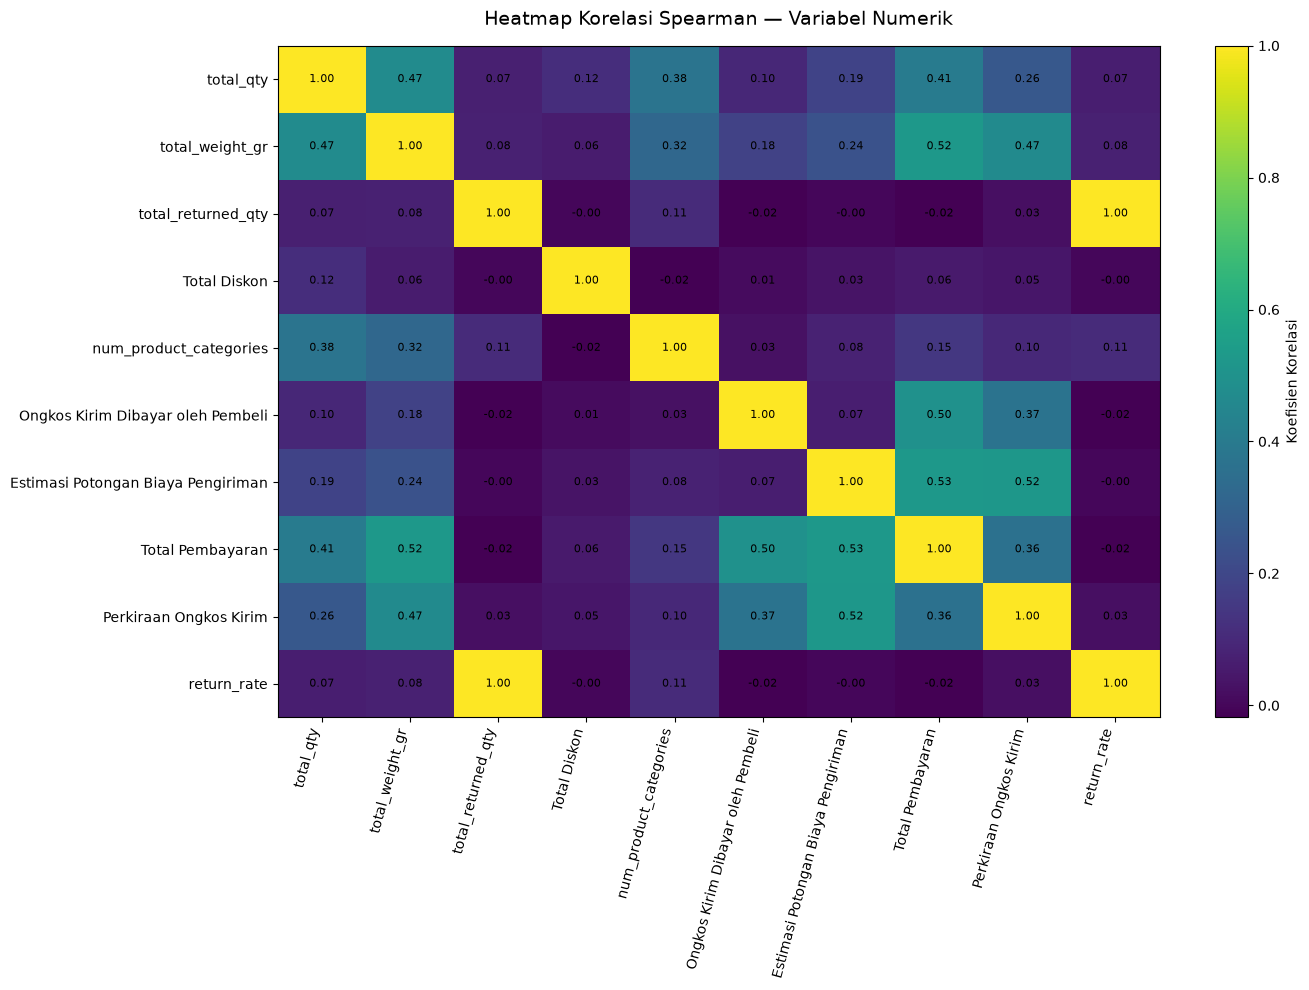


G. SCREENING POTENSI MULTIKOLINEARITAS
Pasangan dengan |Spearman| >= 0.80:
        Variabel_1  Variabel_2  Korelasi_Spearman    Kekuatan
total_returned_qty return_rate                1.0 Sangat Kuat

⚠ Pasangan di atas perlu diperhatikan pada tahap pemodelan karena memiliki hubungan yang sangat kuat.

H. INSIGHT AWAL
✓ Hubungan numerik terkuat ditemukan antara 'total_returned_qty' dan 'return_rate' dengan korelasi Spearman 1.000.
✓ Hubungan tersebut bersifat positif, yang menunjukkan bahwa kenaikan salah satu variabel cenderung diikuti kenaikan variabel lainnya.
✓ Korelasi Spearman digunakan sebagai analisis utama karena beberapa variabel numerik memiliki distribusi yang sangat skewed berdasarkan Step 8.1.
✓ Analisis korelasi pada tahap ini bersifat eksploratif dan belum digunakan untuk menghapus variabel.

KESIMPULAN STEP 8.3
✓ Hubungan antarvariabel numerik telah berhasil dianalisis menggunakan korelasi Pearson dan Spearman.
✓ Korelasi Spearman digunakan sebagai acuan utama karena d

In [84]:
# ================================================================
#  STEP 8.3 — EDA: NUMERICAL CORRELATION ANALYSIS
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print(" STEP 8.3 — EDA: NUMERICAL CORRELATION ANALYSIS")
print("=" * 70)


# ================================================================
# 1. IDENTIFIKASI DATASET FINAL
# ================================================================

# Mencari dataframe yang sudah digunakan pada tahap sebelumnya
candidate_names = [
    "df_final",
    "df_clean",
    "df_processed",
    "df",
    "data_final",
    "dataset_final"
]

df_data = None
df_name = None

for name in candidate_names:
    if name in globals():
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            df_data = obj.copy()
            df_name = name
            break

if df_data is None:
    raise NameError(
        "DataFrame final tidak ditemukan. "
        "Pastikan dataset final menggunakan salah satu nama: "
        "df_final, df_clean, df_processed, df, data_final, atau dataset_final."
    )

print("\n=== INFORMASI DATASET ===")
print(f"DataFrame yang digunakan : {df_name}")
print(f"Jumlah baris             : {len(df_data):,}")
print(f"Jumlah kolom             : {df_data.shape[1]}")


# ================================================================
# 2. DAFTAR VARIABEL NUMERIK
# ================================================================

numeric_columns_expected = [
    "total_qty",
    "total_weight_gr",
    "total_returned_qty",
    "Total Diskon",
    "num_product_categories",
    "Ongkos Kirim Dibayar oleh Pembeli",
    "Estimasi Potongan Biaya Pengiriman",
    "Total Pembayaran",
    "Perkiraan Ongkos Kirim",
    "return_rate"
]

# Hanya mengambil kolom yang benar-benar tersedia
numeric_columns = [
    col for col in numeric_columns_expected
    if col in df_data.columns
]

print("\n=== KOLOM NUMERIK YANG DIANALISIS ===")

for col in numeric_columns:
    print(f"✓ {col}")

missing_expected = [
    col for col in numeric_columns_expected
    if col not in df_data.columns
]

if missing_expected:
    print("\n⚠ Kolom yang tidak ditemukan:")
    for col in missing_expected:
        print(f"- {col}")


# ================================================================
# 3. VALIDASI TIPE DATA NUMERIK
# ================================================================

print("\n=== VALIDASI TIPE DATA ===")

for col in numeric_columns:
    print(
        f"{'✓' if pd.api.types.is_numeric_dtype(df_data[col]) else '⚠'} "
        f"{col} : {df_data[col].dtype}"
    )


# ================================================================
# 4. DATAFRAME NUMERIK
# ================================================================

df_numeric = df_data[numeric_columns].copy()

# Memastikan kolom numerik benar-benar bertipe numerik
for col in numeric_columns:
    df_numeric[col] = pd.to_numeric(
        df_numeric[col],
        errors="coerce"
    )

print("\n=== MISSING VALUE PADA VARIABEL NUMERIK ===")

missing_numeric = df_numeric.isna().sum()

missing_table = pd.DataFrame({
    "Kolom": missing_numeric.index,
    "Jumlah_Missing": missing_numeric.values,
    "Missing_%": (
        missing_numeric.values / len(df_numeric) * 100
    ).round(2)
})

print(missing_table.to_string(index=False))


# ================================================================
# 5. KORELASI PEARSON
# ================================================================

print("\n" + "=" * 70)
print("A. MATRIKS KORELASI PEARSON")
print("=" * 70)

corr_pearson = df_numeric.corr(
    method="pearson"
)

print(
    corr_pearson.round(3).to_string()
)


# ================================================================
# 6. KORELASI SPEARMAN
# ================================================================

print("\n" + "=" * 70)
print("B. MATRIKS KORELASI SPEARMAN")
print("=" * 70)

corr_spearman = df_numeric.corr(
    method="spearman"
)

print(
    corr_spearman.round(3).to_string()
)


# ================================================================
# 7. RANKING PASANGAN KORELASI
# ================================================================

print("\n" + "=" * 70)
print("C. RANKING PASANGAN KORELASI SPEARMAN")
print("=" * 70)

correlation_pairs = []

for i in range(len(numeric_columns)):
    for j in range(i + 1, len(numeric_columns)):

        col1 = numeric_columns[i]
        col2 = numeric_columns[j]

        corr_value = corr_spearman.loc[col1, col2]

        if pd.notna(corr_value):
            correlation_pairs.append({
                "Variabel_1": col1,
                "Variabel_2": col2,
                "Korelasi_Spearman": corr_value,
                "Absolute_Correlation": abs(corr_value)
            })

corr_pairs_df = pd.DataFrame(
    correlation_pairs
).sort_values(
    "Absolute_Correlation",
    ascending=False
).reset_index(drop=True)

print(
    corr_pairs_df[
        [
            "Variabel_1",
            "Variabel_2",
            "Korelasi_Spearman"
        ]
    ].round(3).to_string(index=False)
)


# ================================================================
# 8. KATEGORI KEKUATAN KORELASI
# ================================================================

def correlation_strength(value):

    value = abs(value)

    if value < 0.20:
        return "Sangat Lemah"

    elif value < 0.40:
        return "Lemah"

    elif value < 0.60:
        return "Sedang"

    elif value < 0.80:
        return "Kuat"

    else:
        return "Sangat Kuat"


corr_pairs_df["Kekuatan"] = (
    corr_pairs_df["Korelasi_Spearman"]
    .apply(correlation_strength)
)

print("\n" + "=" * 70)
print("D. PASANGAN DENGAN KORELASI KUAT")
print("=" * 70)

strong_corr = corr_pairs_df[
    corr_pairs_df["Absolute_Correlation"] >= 0.60
].copy()

if len(strong_corr) > 0:

    print(
        strong_corr[
            [
                "Variabel_1",
                "Variabel_2",
                "Korelasi_Spearman",
                "Kekuatan"
            ]
        ].round(3).to_string(index=False)
    )

else:

    print(
        "Tidak ditemukan pasangan variabel dengan "
        "korelasi Spearman >= 0.60."
    )


# ================================================================
# 9. IDENTIFIKASI KORELASI NEGATIF
# ================================================================

print("\n" + "=" * 70)
print("E. PASANGAN DENGAN KORELASI NEGATIF")
print("=" * 70)

negative_corr = corr_pairs_df[
    corr_pairs_df["Korelasi_Spearman"] < 0
].copy()

if len(negative_corr) > 0:

    print(
        negative_corr[
            [
                "Variabel_1",
                "Variabel_2",
                "Korelasi_Spearman",
                "Kekuatan"
            ]
        ].round(3).to_string(index=False)
    )

else:

    print(
        "Tidak ditemukan korelasi negatif "
        "antarvariabel numerik."
    )


# ================================================================
# 10. HEATMAP KORELASI SPEARMAN
# ================================================================

print("\n" + "=" * 70)
print("F. HEATMAP KORELASI SPEARMAN")
print("=" * 70)

fig, ax = plt.subplots(
    figsize=(14, 10)
)

im = ax.imshow(
    corr_spearman.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(numeric_columns))
)

ax.set_yticks(
    np.arange(len(numeric_columns))
)

ax.set_xticklabels(
    numeric_columns,
    rotation=75,
    ha="right"
)

ax.set_yticklabels(
    numeric_columns
)

# Menampilkan nilai korelasi di setiap sel
for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):

        value = corr_spearman.iloc[i, j]

        if pd.notna(value):

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

ax.set_title(
    "Heatmap Korelasi Spearman — Variabel Numerik",
    fontsize=14,
    pad=15
)

plt.colorbar(
    im,
    ax=ax,
    label="Koefisien Korelasi"
)

plt.tight_layout()
plt.show()


# ================================================================
# 11. IDENTIFIKASI POTENSI MULTIKOLINEARITAS AWAL
# ================================================================

print("\n" + "=" * 70)
print("G. SCREENING POTENSI MULTIKOLINEARITAS")
print("=" * 70)

high_corr = corr_pairs_df[
    corr_pairs_df["Absolute_Correlation"] >= 0.80
].copy()

if len(high_corr) > 0:

    print(
        "Pasangan dengan |Spearman| >= 0.80:"
    )

    print(
        high_corr[
            [
                "Variabel_1",
                "Variabel_2",
                "Korelasi_Spearman",
                "Kekuatan"
            ]
        ].round(3).to_string(index=False)
    )

    print(
        "\n⚠ Pasangan di atas perlu diperhatikan "
        "pada tahap pemodelan karena memiliki hubungan "
        "yang sangat kuat."
    )

else:

    print(
        "✓ Tidak ditemukan pasangan variabel dengan "
        "|Spearman| >= 0.80."
    )


# ================================================================
# 12. INSIGHT OTOMATIS
# ================================================================

print("\n" + "=" * 70)
print("H. INSIGHT AWAL")
print("=" * 70)

if len(corr_pairs_df) > 0:

    strongest = corr_pairs_df.iloc[0]

    print(
        f"✓ Hubungan numerik terkuat ditemukan antara "
        f"'{strongest['Variabel_1']}' dan "
        f"'{strongest['Variabel_2']}' "
        f"dengan korelasi Spearman "
        f"{strongest['Korelasi_Spearman']:.3f}."
    )

    if strongest["Korelasi_Spearman"] > 0:

        print(
            "✓ Hubungan tersebut bersifat positif, "
            "yang menunjukkan bahwa kenaikan salah satu "
            "variabel cenderung diikuti kenaikan variabel lainnya."
        )

    elif strongest["Korelasi_Spearman"] < 0:

        print(
            "✓ Hubungan tersebut bersifat negatif, "
            "yang menunjukkan bahwa kenaikan salah satu "
            "variabel cenderung diikuti penurunan variabel lainnya."
        )

print(
    "✓ Korelasi Spearman digunakan sebagai analisis utama "
    "karena beberapa variabel numerik memiliki distribusi "
    "yang sangat skewed berdasarkan Step 8.1."
)

print(
    "✓ Analisis korelasi pada tahap ini bersifat eksploratif "
    "dan belum digunakan untuk menghapus variabel."
)


# ================================================================
# 13. KESIMPULAN STEP 8.3
# ================================================================

print("\n" + "=" * 70)
print("KESIMPULAN STEP 8.3")
print("=" * 70)

print(
    "✓ Hubungan antarvariabel numerik telah berhasil dianalisis "
    "menggunakan korelasi Pearson dan Spearman."
)

print(
    "✓ Korelasi Spearman digunakan sebagai acuan utama karena "
    "distribusi beberapa variabel numerik menunjukkan skewness tinggi."
)

print(
    "✓ Matriks korelasi dan ranking pasangan variabel telah "
    "berhasil dihitung."
)

print(
    "✓ Pasangan variabel dengan korelasi kuat telah "
    "diidentifikasi sebagai bahan evaluasi tahap berikutnya."
)

print(
    "✓ Screening awal multikolinearitas telah dilakukan berdasarkan "
    "nilai absolut korelasi Spearman."
)

print(
    "✓ Hasil korelasi digunakan untuk memahami pola hubungan "
    "antarvariabel numerik dan belum menjadi dasar penghapusan variabel."
)

print(
    "✓ Tidak dilakukan perubahan terhadap dataset pada tahap ini."
)

print(
    "\n✓ STEP 8.3 SELESAI"
)

print("=" * 70)

 STEP 8.4 — EDA: NUMERICAL OUTLIER ANALYSIS

=== INFORMASI DATASET ===
DataFrame yang digunakan : df_final
Jumlah baris             : 20,848
Jumlah kolom             : 20

=== KOLOM NUMERIK YANG DIANALISIS ===
✓ total_qty
✓ total_weight_gr
✓ total_returned_qty
✓ Total Diskon
✓ num_product_categories
✓ Ongkos Kirim Dibayar oleh Pembeli
✓ Estimasi Potongan Biaya Pengiriman
✓ Total Pembayaran
✓ Perkiraan Ongkos Kirim
✓ return_rate

Jumlah variabel numerik : 10

=== ANALISIS OUTLIER DENGAN METODE IQR ===

=== RINGKASAN OUTLIER ===


,Variabel,Jumlah_Data,Q1,Q3,IQR,Batas_Bawah,Batas_Atas,Jumlah_Outlier,Persentase_Outlier_%,Data_Non_Outlier,Kategori_Outlier
0,Ongkos Kirim Dibayar oleh Pembeli,20848,0.00,"3,000.00","3,000.00","-4,500.00","7,500.00",4048,19.42,16800,Tinggi
1,total_qty,20848,1.00,2.00,1.00,-0.50,3.50,2614,12.54,18234,Tinggi
2,total_weight_gr,20848,300.00,"1,600.00","1,300.00","-1,650.00","3,550.00",2448,11.74,18400,Tinggi
3,Total Pembayaran,20848,"13,480.00","41,600.00","28,120.00","-28,700.00","83,780.00",2309,11.08,18539,Tinggi
4,Perkiraan Ongkos Kirim,20848,"8,000.00","20,000.00","12,000.00","-10,000.00","38,000.00",1815,8.71,19033,Sedang
5,num_product_categories,20848,1.00,1.00,0.00,1.00,1.00,1504,7.21,19344,Sedang
6,Estimasi Potongan Biaya Pengiriman,20848,0.00,"15,000.00","15,000.00","-22,500.00","37,500.00",788,3.78,20060,Rendah
7,total_returned_qty,20848,0.00,0.00,0.00,0.00,0.00,157,0.75,20691,Sangat rendah
8,return_rate,20848,0.00,0.00,0.00,0.00,0.00,157,0.75,20691,Sangat rendah
9,Total Diskon,20848,0.00,0.00,0.00,0.00,0.00,135,0.65,20713,Sangat rendah



=== VARIABEL DENGAN OUTLIER ===
• Ongkos Kirim Dibayar oleh Pembeli : 4,048 outlier (19.42%) — Tinggi
• total_qty : 2,614 outlier (12.54%) — Tinggi
• total_weight_gr : 2,448 outlier (11.74%) — Tinggi
• Total Pembayaran : 2,309 outlier (11.08%) — Tinggi
• Perkiraan Ongkos Kirim : 1,815 outlier (8.71%) — Sedang
• num_product_categories : 1,504 outlier (7.21%) — Sedang
• Estimasi Potongan Biaya Pengiriman : 788 outlier (3.78%) — Rendah
• total_returned_qty : 157 outlier (0.75%) — Sangat rendah
• return_rate : 157 outlier (0.75%) — Sangat rendah
• Total Diskon : 135 outlier (0.65%) — Sangat rendah

=== TOP 5 VARIABEL DENGAN OUTLIER TERBANYAK ===
1. Ongkos Kirim Dibayar oleh Pembeli → 4,048 (19.42%)
2. total_qty → 2,614 (12.54%)
3. total_weight_gr → 2,448 (11.74%)
4. Total Pembayaran → 2,309 (11.08%)
5. Perkiraan Ongkos Kirim → 1,815 (8.71%)

=== BOXPLOT VARIABEL NUMERIK ===


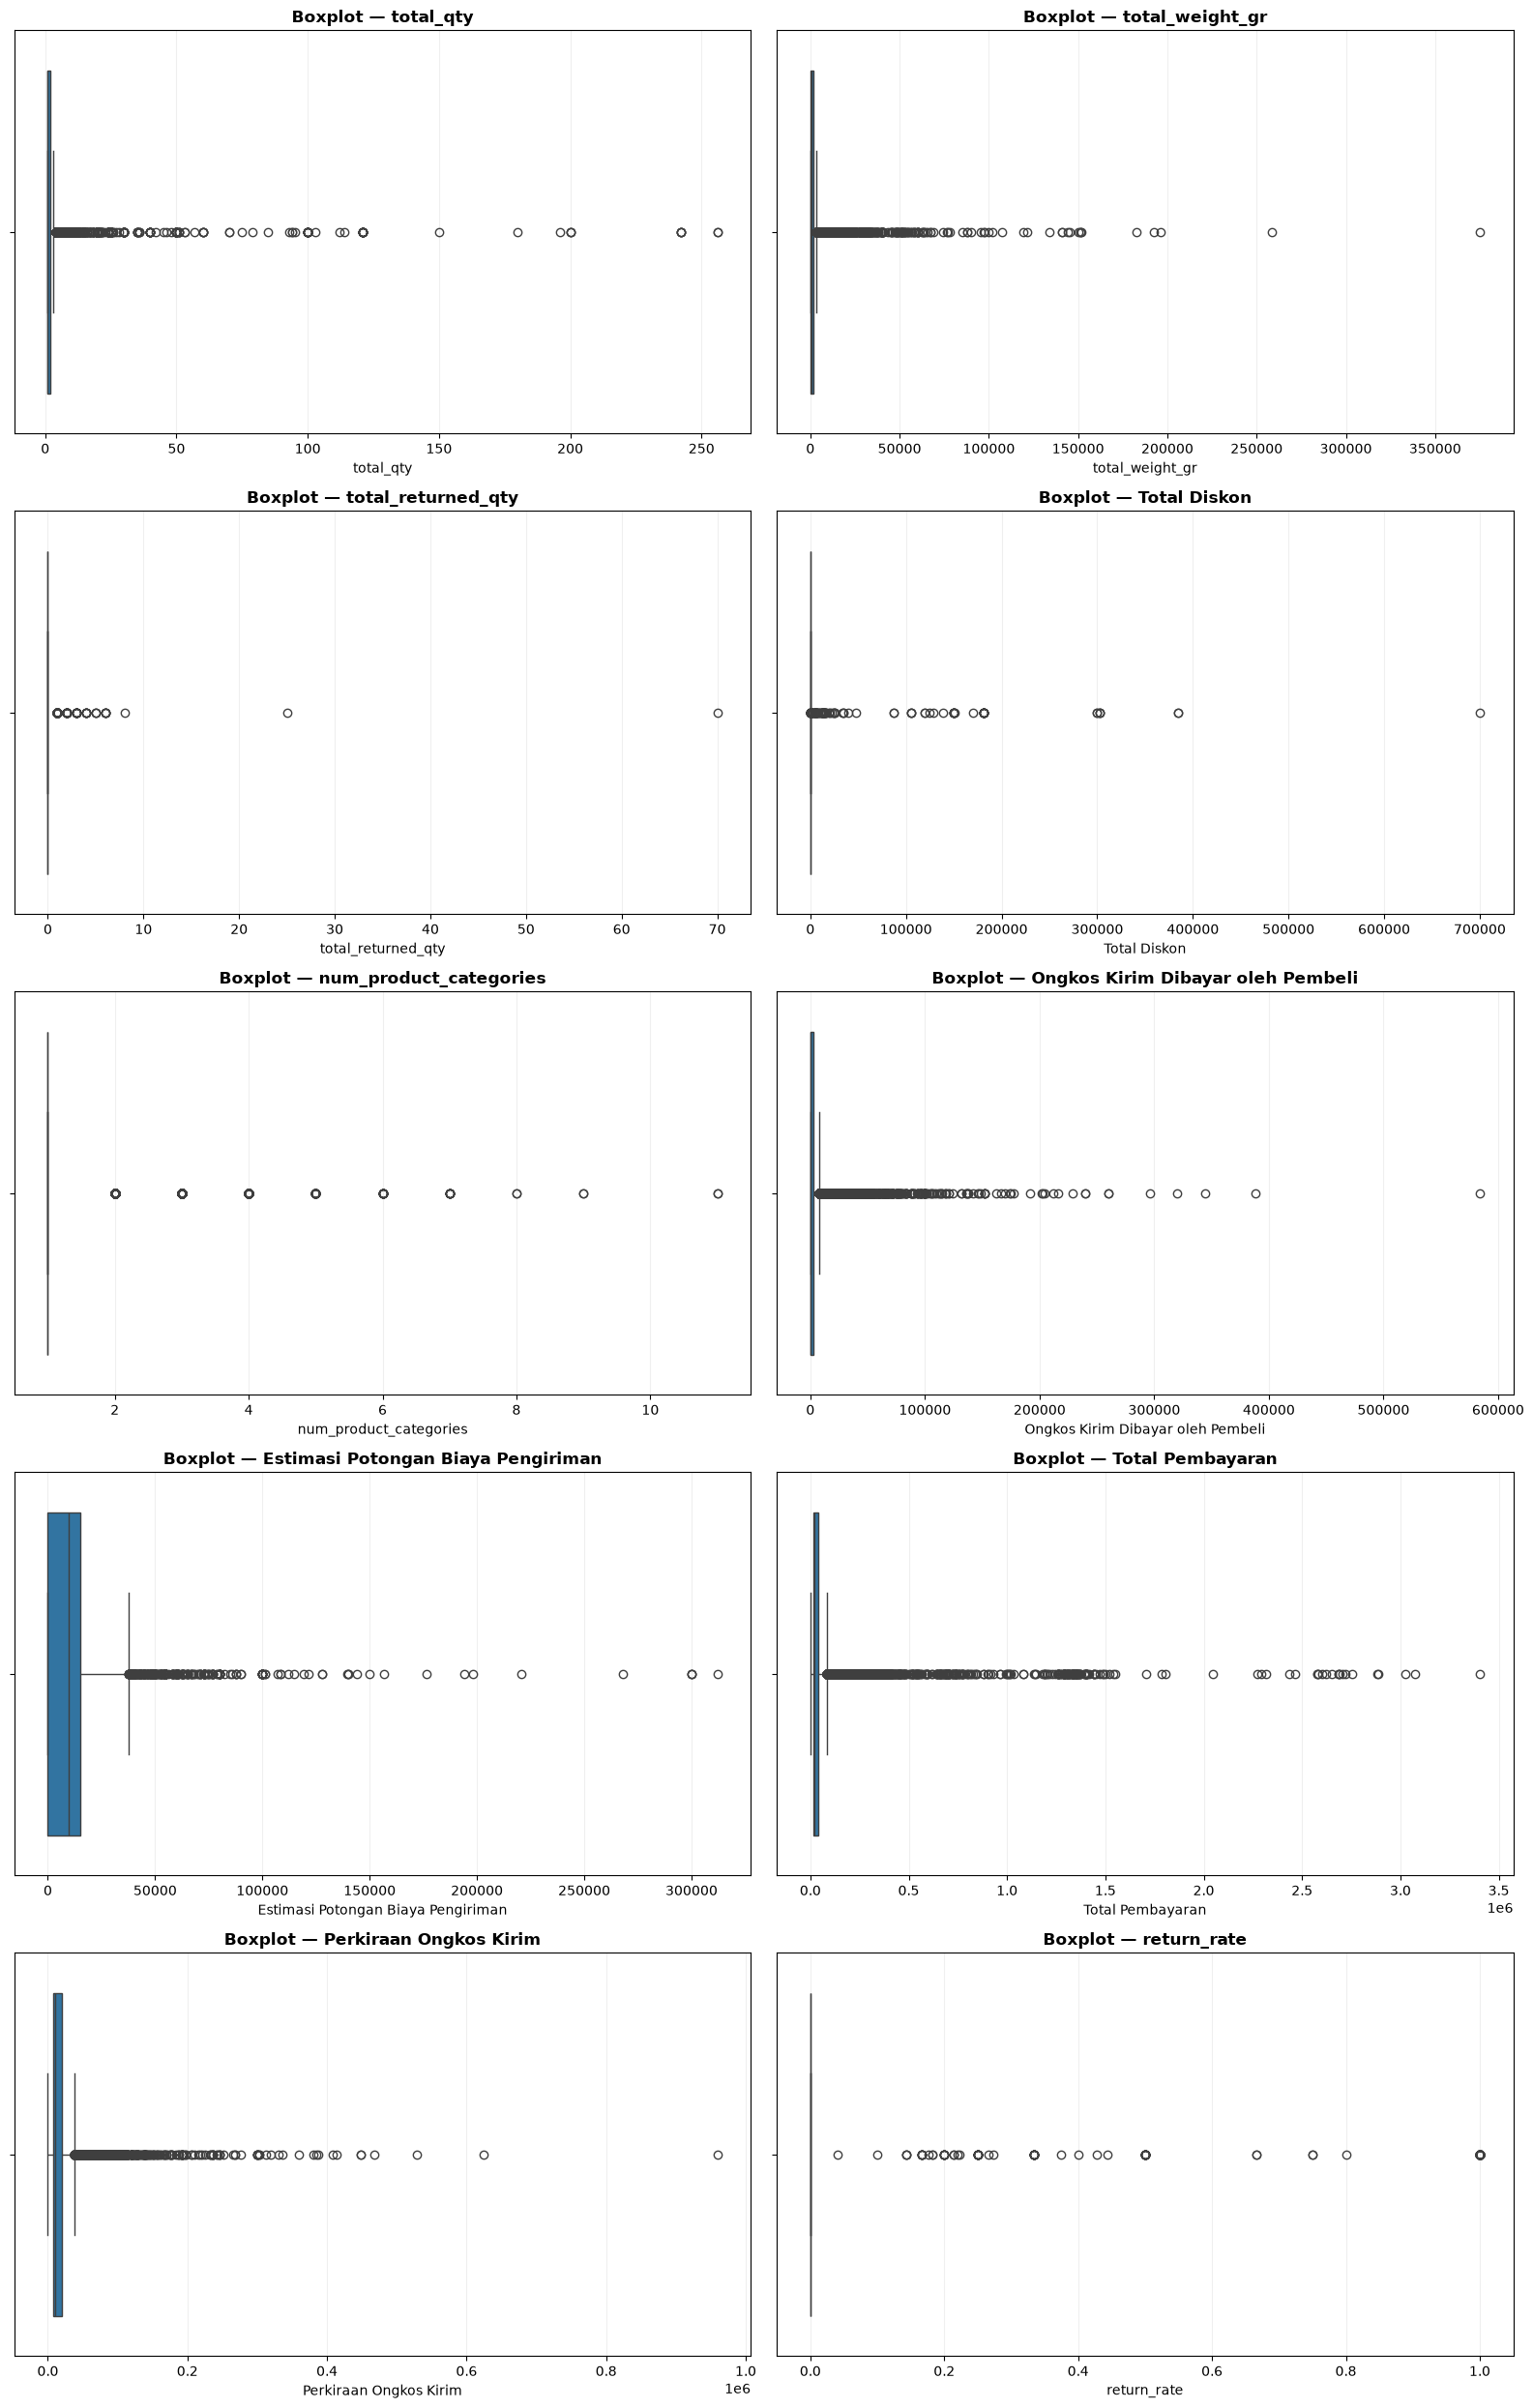


=== NILAI EKSTREM ===

[total_qty]
Minimum outlier : 4.00
Maksimum outlier: 256.00
Jumlah outlier  : 2,614

[total_weight_gr]
Minimum outlier : 3,570.00
Maksimum outlier: 375,000.00
Jumlah outlier  : 2,448

[total_returned_qty]
Minimum outlier : 1.00
Maksimum outlier: 70.00
Jumlah outlier  : 157

[Total Diskon]
Minimum outlier : 1.00
Maksimum outlier: 700,000.00
Jumlah outlier  : 135

[num_product_categories]
Minimum outlier : 2.00
Maksimum outlier: 11.00
Jumlah outlier  : 1,504

[Ongkos Kirim Dibayar oleh Pembeli]
Minimum outlier : 7,600.00
Maksimum outlier: 584,000.00
Jumlah outlier  : 4,048

[Estimasi Potongan Biaya Pengiriman]
Minimum outlier : 37,600.00
Maksimum outlier: 312,000.00
Jumlah outlier  : 788

[Total Pembayaran]
Minimum outlier : 83,800.00
Maksimum outlier: 3,403,591.00
Jumlah outlier  : 2,309

[Perkiraan Ongkos Kirim]
Minimum outlier : 38,300.00
Maksimum outlier: 959,200.00
Jumlah outlier  : 1,815

[return_rate]
Minimum outlier : 0.04
Maksimum outlier: 1.00
Jumlah out

In [85]:
# ============================================================
#  STEP 8.4 — EDA: NUMERICAL OUTLIER ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print(" STEP 8.4 — EDA: NUMERICAL OUTLIER ANALYSIS")
print("=" * 70)

# ============================================================
# A. INFORMASI DATASET
# ============================================================

print("\n=== INFORMASI DATASET ===")

print(f"DataFrame yang digunakan : df_final")
print(f"Jumlah baris             : {df_final.shape[0]:,}")
print(f"Jumlah kolom             : {df_final.shape[1]}")

# ============================================================
# B. IDENTIFIKASI KOLOM NUMERIK
# ============================================================

numeric_cols = df_final.select_dtypes(include=np.number).columns.tolist()

print("\n=== KOLOM NUMERIK YANG DIANALISIS ===")

if len(numeric_cols) == 0:
    print("Tidak ditemukan kolom numerik.")
else:
    for col in numeric_cols:
        print(f"✓ {col}")

print(f"\nJumlah variabel numerik : {len(numeric_cols)}")

# ============================================================
# C. FUNGSI KLASIFIKASI OUTLIER
# ============================================================

def classify_outlier_percentage(pct):
    if pct == 0:
        return "Tidak ada"
    elif pct < 1:
        return "Sangat rendah"
    elif pct < 5:
        return "Rendah"
    elif pct < 10:
        return "Sedang"
    elif pct < 20:
        return "Tinggi"
    else:
        return "Sangat tinggi"


# ============================================================
# D. ANALISIS IQR
# ============================================================

print("\n" + "=" * 70)
print("=== ANALISIS OUTLIER DENGAN METODE IQR ===")
print("=" * 70)

outlier_results = []

for col in numeric_cols:

    series = pd.to_numeric(df_final[col], errors="coerce").dropna()

    if len(series) == 0:
        continue

    # Quartile
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    # IQR
    iqr = q3 - q1

    # Batas outlier
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Identifikasi outlier
    outlier_mask = (
        (series < lower_bound) |
        (series > upper_bound)
    )

    outlier_count = outlier_mask.sum()
    total_valid = len(series)

    outlier_pct = (
        outlier_count / total_valid * 100
        if total_valid > 0 else 0
    )

    non_outlier_count = total_valid - outlier_count

    outlier_results.append({
        "Variabel": col,
        "Jumlah_Data": total_valid,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Batas_Bawah": lower_bound,
        "Batas_Atas": upper_bound,
        "Jumlah_Outlier": int(outlier_count),
        "Persentase_Outlier_%": outlier_pct,
        "Data_Non_Outlier": int(non_outlier_count),
        "Kategori_Outlier": classify_outlier_percentage(outlier_pct)
    })


# ============================================================
# E. TABEL HASIL OUTLIER
# ============================================================

outlier_summary = pd.DataFrame(outlier_results)

if not outlier_summary.empty:

    outlier_summary = outlier_summary.sort_values(
        by="Jumlah_Outlier",
        ascending=False
    ).reset_index(drop=True)

    print("\n=== RINGKASAN OUTLIER ===")

    display(
        outlier_summary.style.format({
            "Q1": "{:,.2f}",
            "Q3": "{:,.2f}",
            "IQR": "{:,.2f}",
            "Batas_Bawah": "{:,.2f}",
            "Batas_Atas": "{:,.2f}",
            "Persentase_Outlier_%": "{:.2f}"
        })
    )

else:
    print("Tidak ada hasil analisis outlier.")


# ============================================================
# F. VARIABEL DENGAN OUTLIER
# ============================================================

print("\n" + "=" * 70)
print("=== VARIABEL DENGAN OUTLIER ===")
print("=" * 70)

if not outlier_summary.empty:

    variables_with_outlier = outlier_summary[
        outlier_summary["Jumlah_Outlier"] > 0
    ]

    if len(variables_with_outlier) > 0:

        for _, row in variables_with_outlier.iterrows():

            print(
                f"• {row['Variabel']} : "
                f"{row['Jumlah_Outlier']:,} outlier "
                f"({row['Persentase_Outlier_%']:.2f}%) "
                f"— {row['Kategori_Outlier']}"
            )

    else:
        print("Tidak ditemukan outlier berdasarkan metode IQR.")


# ============================================================
# G. TOP 5 VARIABEL DENGAN OUTLIER TERBANYAK
# ============================================================

print("\n" + "=" * 70)
print("=== TOP 5 VARIABEL DENGAN OUTLIER TERBANYAK ===")
print("=" * 70)

if not outlier_summary.empty:

    top5_outlier = outlier_summary.head(5)

    for i, (_, row) in enumerate(
        top5_outlier.iterrows(),
        start=1
    ):

        print(
            f"{i}. {row['Variabel']} → "
            f"{row['Jumlah_Outlier']:,} "
            f"({row['Persentase_Outlier_%']:.2f}%)"
        )


# ============================================================
# H. BOXPLOT
# ============================================================

print("\n" + "=" * 70)
print("=== BOXPLOT VARIABEL NUMERIK ===")
print("=" * 70)

# Gunakan hanya variabel yang memiliki data
plot_cols = [
    col for col in numeric_cols
    if df_final[col].notna().sum() > 0
]

if len(plot_cols) > 0:

    n_cols = 2
    n_rows = int(np.ceil(len(plot_cols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, 5 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):

        sns.boxplot(
            x=df_final[col],
            ax=axes[i]
        )

        axes[i].set_title(
            f"Boxplot — {col}",
            fontsize=12,
            fontweight="bold"
        )

        axes[i].set_xlabel(col)

        axes[i].grid(
            axis="x",
            alpha=0.2
        )

    # Matikan axis kosong
    for j in range(len(plot_cols), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# I. DETEKSI NILAI EKSTREM
# ============================================================

print("\n" + "=" * 70)
print("=== NILAI EKSTREM ===")
print("=" * 70)

for col in numeric_cols:

    series = pd.to_numeric(
        df_final[col],
        errors="coerce"
    ).dropna()

    if len(series) == 0:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    extreme_values = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    if len(extreme_values) > 0:

        print(f"\n[{col}]")

        print(
            f"Minimum outlier : "
            f"{extreme_values.min():,.2f}"
        )

        print(
            f"Maksimum outlier: "
            f"{extreme_values.max():,.2f}"
        )

        print(
            f"Jumlah outlier  : "
            f"{len(extreme_values):,}"
        )


# ============================================================
# J. INSIGHT AWAL
# ============================================================

print("\n" + "=" * 70)
print("=== INSIGHT AWAL ===")
print("=" * 70)

if not outlier_summary.empty:

    total_variables = len(outlier_summary)

    variables_with_outlier = outlier_summary[
        outlier_summary["Jumlah_Outlier"] > 0
    ]

    variables_without_outlier = outlier_summary[
        outlier_summary["Jumlah_Outlier"] == 0
    ]

    print(
        f"✓ Sebanyak {len(variables_with_outlier)} "
        f"dari {total_variables} variabel numerik "
        f"memiliki outlier berdasarkan metode IQR."
    )

    print(
        f"✓ Sebanyak {len(variables_without_outlier)} "
        f"variabel tidak memiliki outlier berdasarkan metode IQR."
    )

    if len(variables_with_outlier) > 0:

        highest = outlier_summary.iloc[0]

        print(
            f"✓ Variabel dengan jumlah outlier terbanyak adalah "
            f"'{highest['Variabel']}' dengan "
            f"{highest['Jumlah_Outlier']:,} outlier "
            f"({highest['Persentase_Outlier_%']:.2f}%)."
        )

    high_outlier = outlier_summary[
        outlier_summary["Persentase_Outlier_%"] >= 10
    ]

    if len(high_outlier) > 0:

        print(
            f"✓ Terdapat {len(high_outlier)} variabel "
            f"dengan persentase outlier ≥ 10%."
        )

        print(
            "✓ Variabel tersebut perlu diperiksa lebih lanjut "
            "sebelum tahap feature engineering atau pemodelan."
        )

    else:

        print(
            "✓ Tidak terdapat variabel dengan persentase "
            "outlier ≥ 10%."
        )

    print(
        "✓ Keberadaan outlier tidak langsung dianggap sebagai "
        "kesalahan data."
    )

    print(
        "✓ Outlier akan dipertimbangkan berdasarkan konteks "
        "bisnis dan tujuan analisis."
    )

    print(
        "✓ Tidak dilakukan penghapusan atau perubahan terhadap "
        "dataset pada tahap ini."
    )


# ============================================================
# K. KESIMPULAN STEP 8.4
# ============================================================

print("\n" + "=" * 70)
print("KESIMPULAN STEP 8.4")
print("=" * 70)

print(
    "✓ Analisis outlier variabel numerik telah dilakukan "
    "menggunakan metode Interquartile Range (IQR)."
)

print(
    "✓ Q1, Q3, IQR, batas bawah, batas atas, jumlah outlier, "
    "dan persentase outlier telah dihitung."
)

print(
    "✓ Distribusi outlier divisualisasikan menggunakan boxplot."
)

print(
    "✓ Variabel dengan jumlah dan persentase outlier tertinggi "
    "telah diidentifikasi."
)

print(
    "✓ Outlier tidak langsung dianggap sebagai kesalahan data "
    "karena dapat merepresentasikan kondisi transaksi yang valid."
)

print(
    "✓ Hasil analisis outlier akan menjadi pertimbangan "
    "pada tahap feature engineering dan pemodelan."
)

print(
    "✓ Tidak dilakukan perubahan terhadap dataset pada tahap ini."
)

print("\n✓ STEP 8.4 SELESAI")

print("=" * 70)

In [80]:
# ============================================================
# STEP 8.5 — BUSINESS PERFORMANCE OVERVIEW
# ============================================================

import pandas as pd
import numpy as np

print("=" * 65)
print("STEP 8.5 — BUSINESS PERFORMANCE OVERVIEW")
print("=" * 65)

# ------------------------------------------------------------
# 1. JUMLAH TRANSAKSI
# ------------------------------------------------------------

total_transactions = len(df_final)


# ------------------------------------------------------------
# 2. TOTAL QUANTITY
# ------------------------------------------------------------

total_qty = df_final["total_qty"].sum()


# ------------------------------------------------------------
# 3. TOTAL PEMBAYARAN
# ------------------------------------------------------------

total_payment = df_final["Total Pembayaran"].sum()


# ------------------------------------------------------------
# 4. RATA-RATA NILAI TRANSAKSI
# ------------------------------------------------------------

average_payment = df_final["Total Pembayaran"].mean()


# ------------------------------------------------------------
# 5. MEDIAN NILAI TRANSAKSI
# ------------------------------------------------------------

median_payment = df_final["Total Pembayaran"].median()


# ------------------------------------------------------------
# 6. TOTAL DISKON
# ------------------------------------------------------------

total_discount = df_final["Total Diskon"].sum()


# ------------------------------------------------------------
# 7. TOTAL ONGKOS KIRIM
# ------------------------------------------------------------

total_shipping = df_final[
    "Ongkos Kirim Dibayar oleh Pembeli"
].sum()


# ------------------------------------------------------------
# 8. TOTAL BARANG DIRETUR
# ------------------------------------------------------------

total_returned = df_final["total_returned_qty"].sum()


# ------------------------------------------------------------
# 9. RETURN RATE
# ------------------------------------------------------------

if total_qty > 0:
    overall_return_rate = total_returned / total_qty
else:
    overall_return_rate = np.nan


# ============================================================
# HASIL KPI
# ============================================================

print("\n" + "=" * 65)
print("BUSINESS PERFORMANCE KPI")
print("=" * 65)

print(f"Total Transaksi       : {total_transactions:,.0f}")
print(f"Total Quantity        : {total_qty:,.0f}")
print(f"Total Pembayaran      : Rp {total_payment:,.2f}")
print(f"Rata-rata Transaksi   : Rp {average_payment:,.2f}")
print(f"Median Transaksi      : Rp {median_payment:,.2f}")
print(f"Total Diskon          : Rp {total_discount:,.2f}")
print(f"Total Ongkos Kirim    : Rp {total_shipping:,.2f}")
print(f"Total Barang Diretur  : {total_returned:,.0f}")
print(f"Overall Return Rate   : {overall_return_rate:.2%}")


# ============================================================
# KPI DATAFRAME
# ============================================================

kpi_business = pd.DataFrame({
    "KPI": [
        "Total Transactions",
        "Total Quantity",
        "Total Payment",
        "Average Transaction Value",
        "Median Transaction Value",
        "Total Discount",
        "Total Shipping Cost",
        "Total Returned Quantity",
        "Overall Return Rate"
    ],
    "Value": [
        total_transactions,
        total_qty,
        total_payment,
        average_payment,
        median_payment,
        total_discount,
        total_shipping,
        total_returned,
        overall_return_rate
    ]
})

print("\n" + "=" * 65)
print("KPI TABLE")
print("=" * 65)

display(kpi_business)


# ============================================================
# INSIGHT AWAL
# ============================================================

print("\n" + "=" * 65)
print("INSIGHT AWAL")
print("=" * 65)

print(
    f"✓ Dataset mencakup {total_transactions:,.0f} transaksi."
)

print(
    f"✓ Total quantity yang tercatat sebanyak "
    f"{total_qty:,.0f} unit."
)

print(
    f"✓ Total nilai pembayaran mencapai "
    f"Rp {total_payment:,.2f}."
)

print(
    f"✓ Nilai rata-rata transaksi sebesar "
    f"Rp {average_payment:,.2f}."
)

print(
    f"✓ Total barang yang diretur sebanyak "
    f"{total_returned:,.0f} unit."
)

print(
    f"✓ Overall return rate sebesar "
    f"{overall_return_rate:.2%}."
)

print("\n✓ STEP 8.5 SELESAI")
print("=" * 65)

STEP 8.5 — BUSINESS PERFORMANCE OVERVIEW

BUSINESS PERFORMANCE KPI
Total Transaksi       : 20,848
Total Quantity        : 53,388
Total Pembayaran      : Rp 1,056,651,631.00
Rata-rata Transaksi   : Rp 50,683.60
Median Transaksi      : Rp 21,800.00
Total Diskon          : Rp 8,447,596.00
Total Ongkos Kirim    : Rp 87,352,926.00
Total Barang Diretur  : 370
Overall Return Rate   : 0.69%

KPI TABLE


,KPI,Value
0,Total Transactions,2.084800e+04
1,Total Quantity,5.338800e+04
2,Total Payment,1.056652e+09
3,Average Transaction Value,5.068360e+04
4,Median Transaction Value,2.180000e+04
5,Total Discount,8.447596e+06
6,Total Shipping Cost,8.735293e+07
7,Total Returned Quantity,3.700000e+02
8,Overall Return Rate,6.930396e-03



INSIGHT AWAL
✓ Dataset mencakup 20,848 transaksi.
✓ Total quantity yang tercatat sebanyak 53,388 unit.
✓ Total nilai pembayaran mencapai Rp 1,056,651,631.00.
✓ Nilai rata-rata transaksi sebesar Rp 50,683.60.
✓ Total barang yang diretur sebanyak 370 unit.
✓ Overall return rate sebesar 0.69%.

✓ STEP 8.5 SELESAI


STEP 8.6 — SALES & PAYMENT ANALYSIS

=== INFORMASI DATASET ===
DataFrame yang digunakan : df_final
Jumlah transaksi         : 20,848

=== VALIDASI KOLOM ===
✓ Total Pembayaran
✓ total_qty
✓ total_weight_gr
✓ Total Diskon
✓ Ongkos Kirim Dibayar oleh Pembeli
✓ Perkiraan Ongkos Kirim

=== STATISTIK TOTAL PEMBAYARAN ===


,Statistik,Nilai
0,Jumlah Data,2.084800e+04
1,Minimum,0.000000e+00
2,Q1,1.348000e+04
3,Median,2.180000e+04
4,Mean,5.068360e+04
5,Q3,4.160000e+04
6,Maksimum,3.403591e+06
7,Std Deviasi,1.440193e+05



=== SEGMENTASI NILAI TRANSAKSI ===


,Segmen,Jumlah_Transaksi,Persentase_%
0,Rendah (≤ Q1),5227,25.071949
1,Menengah (Q1–Q3),10416,49.961627
2,Tinggi (> Q3),5205,24.966424



=== TOP 10 TRANSAKSI DENGAN NILAI PEMBAYARAN TERTINGGI ===


,Total Pembayaran,total_qty,total_weight_gr,Total Diskon,Ongkos Kirim Dibayar oleh Pembeli,Perkiraan Ongkos Kirim
9706,3403591,196,196000,0,70000,80000
19178,3076000,2,24000,0,344000,384000
5830,3023425,4,52000,0,0,121500
8956,2889700,2,24000,0,87700,87700
17711,2884000,8,32000,0,0,150000
2724,2756000,2,24000,0,10000,110000
1513,2718000,2,24000,0,0,87700
13173,2703000,2,24000,0,0,87700
4293,2692454,2,24000,0,115200,155200
19633,2684500,200,60000,700000,106500,206500



=== HUBUNGAN VARIABEL DENGAN TOTAL PEMBAYARAN ===


,Variabel,Spearman_Correlation,Kekuatan
0,total_weight_gr,0.523641,Sedang
1,Ongkos Kirim Dibayar oleh Pembeli,0.497874,Sedang
2,total_qty,0.406744,Sedang
3,Perkiraan Ongkos Kirim,0.361523,Lemah
4,Total Diskon,0.056910,Sangat lemah



=== DISTRIBUSI TOTAL PEMBAYARAN ===


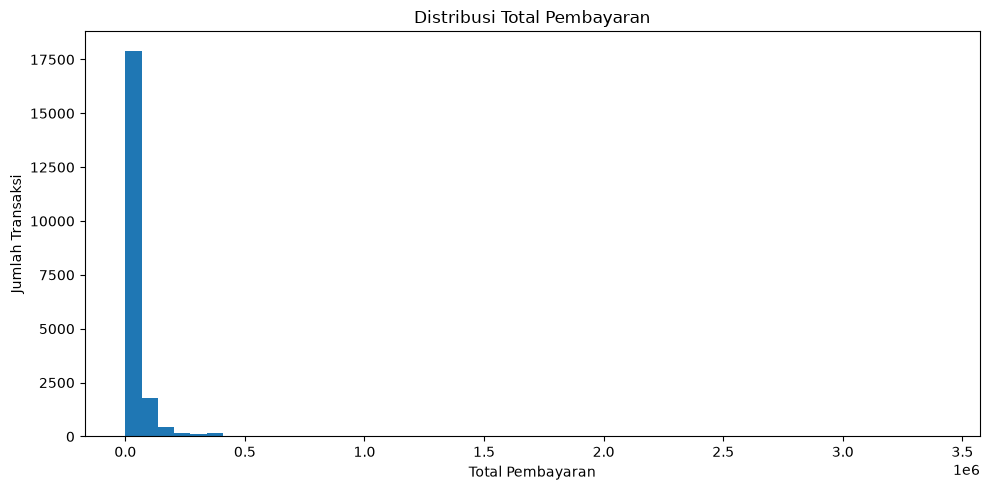

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14148\157716221.py:235: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(payment, vert=False)


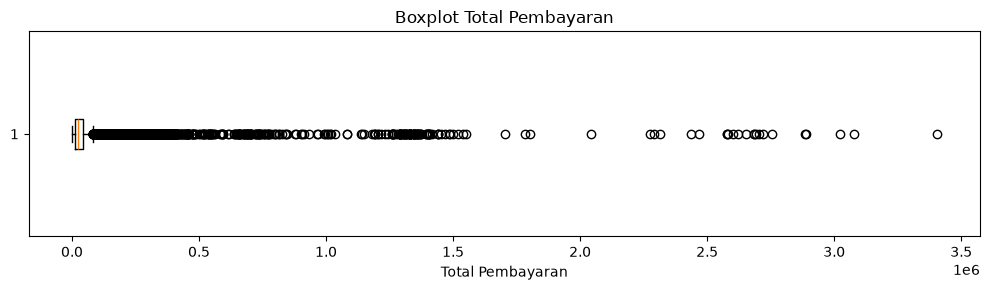


=== INSIGHT AWAL ===
✓ Total transaksi yang dianalisis sebanyak 20,848 transaksi.
✓ Nilai median transaksi sebesar Rp 21,800.00.
✓ Nilai rata-rata transaksi sebesar Rp 50,683.60.
✓ Mean lebih tinggi daripada median, menunjukkan adanya kecenderungan transaksi bernilai tinggi yang memengaruhi rata-rata.
✓ Nilai transaksi minimum sebesar Rp 0.00.
✓ Nilai transaksi maksimum sebesar Rp 3,403,591.00.
✓ Transaksi bernilai tinggi (> Q3) sebanyak 5,205 transaksi (24.97%).
✓ Hubungan numerik terkuat dengan Total Pembayaran adalah 'total_weight_gr' dengan korelasi Spearman 0.524.

KESIMPULAN STEP 8.6
✓ Distribusi nilai pembayaran telah dianalisis.
✓ Statistik deskriptif Total Pembayaran telah dihitung.
✓ Transaksi telah dikelompokkan berdasarkan kuartil.
✓ Transaksi dengan nilai pembayaran tertinggi telah diidentifikasi.
✓ Hubungan Total Pembayaran dengan variabel numerik lainnya telah dianalisis menggunakan korelasi Spearman.
✓ Distribusi dan outlier Total Pembayaran telah divisualisasikan.
✓ A

In [78]:
# ============================================================
# STEP 8.6 — SALES & PAYMENT ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 8.6 — SALES & PAYMENT ANALYSIS")
print("=" * 70)


# ============================================================
# 1. INFORMASI DATASET
# ============================================================

print("\n=== INFORMASI DATASET ===")

print(f"DataFrame yang digunakan : df_final")
print(f"Jumlah transaksi         : {len(df_final):,}")


# ============================================================
# 2. VALIDASI KOLOM
# ============================================================

required_columns = [
    "Total Pembayaran",
    "total_qty",
    "total_weight_gr",
    "Total Diskon",
    "Ongkos Kirim Dibayar oleh Pembeli",
    "Perkiraan Ongkos Kirim"
]

print("\n=== VALIDASI KOLOM ===")

missing_columns = [
    col for col in required_columns
    if col not in df_final.columns
]

if missing_columns:

    print("⚠ Kolom berikut tidak ditemukan:")
    
    for col in missing_columns:
        print(f"  - {col}")

    raise KeyError(
        "Kolom yang diperlukan untuk Step 8.2 tidak lengkap."
    )

else:

    for col in required_columns:
        print(f"✓ {col}")


# ============================================================
# 3. STATISTIK TOTAL PEMBAYARAN
# ============================================================

print("\n" + "=" * 70)
print("=== STATISTIK TOTAL PEMBAYARAN ===")

payment = df_final["Total Pembayaran"].dropna()

payment_stats = pd.DataFrame({
    "Statistik": [
        "Jumlah Data",
        "Minimum",
        "Q1",
        "Median",
        "Mean",
        "Q3",
        "Maksimum",
        "Std Deviasi"
    ],
    "Nilai": [
        payment.count(),
        payment.min(),
        payment.quantile(0.25),
        payment.median(),
        payment.mean(),
        payment.quantile(0.75),
        payment.max(),
        payment.std()
    ]
})

display(payment_stats)


# ============================================================
# 4. SEGMENTASI NILAI TRANSAKSI
# ============================================================

print("\n" + "=" * 70)
print("=== SEGMENTASI NILAI TRANSAKSI ===")

q1_payment = payment.quantile(0.25)
q3_payment = payment.quantile(0.75)

low_transaction = (payment <= q1_payment).sum()
middle_transaction = (
    (payment > q1_payment) &
    (payment <= q3_payment)
).sum()
high_transaction = (payment > q3_payment).sum()

transaction_segment = pd.DataFrame({
    "Segmen": [
        "Rendah (≤ Q1)",
        "Menengah (Q1–Q3)",
        "Tinggi (> Q3)"
    ],
    "Jumlah_Transaksi": [
        low_transaction,
        middle_transaction,
        high_transaction
    ]
})

transaction_segment["Persentase_%"] = (
    transaction_segment["Jumlah_Transaksi"]
    / len(payment)
    * 100
)

display(transaction_segment)


# ============================================================
# 5. TOP 10 TRANSAKSI DENGAN NILAI PEMBAYARAN TERTINGGI
# ============================================================

print("\n" + "=" * 70)
print("=== TOP 10 TRANSAKSI DENGAN NILAI PEMBAYARAN TERTINGGI ===")

top_payment = (
    df_final[
        [
            "Total Pembayaran",
            "total_qty",
            "total_weight_gr",
            "Total Diskon",
            "Ongkos Kirim Dibayar oleh Pembeli",
            "Perkiraan Ongkos Kirim"
        ]
    ]
    .sort_values(
        "Total Pembayaran",
        ascending=False
    )
    .head(10)
)

display(top_payment)


# ============================================================
# 6. KORELASI DENGAN TOTAL PEMBAYARAN
# ============================================================

print("\n" + "=" * 70)
print("=== HUBUNGAN VARIABEL DENGAN TOTAL PEMBAYARAN ===")

correlation_columns = [
    "Total Pembayaran",
    "total_qty",
    "total_weight_gr",
    "Total Diskon",
    "Ongkos Kirim Dibayar oleh Pembeli",
    "Perkiraan Ongkos Kirim"
]

corr_spearman = (
    df_final[correlation_columns]
    .corr(method="spearman")["Total Pembayaran"]
    .drop("Total Pembayaran")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

correlation_table = pd.DataFrame({
    "Variabel": corr_spearman.index,
    "Spearman_Correlation": corr_spearman.values
})

correlation_table["Kekuatan"] = correlation_table[
    "Spearman_Correlation"
].abs().apply(
    lambda x:
        "Sangat kuat" if x >= 0.80
        else "Kuat" if x >= 0.60
        else "Sedang" if x >= 0.40
        else "Lemah" if x >= 0.20
        else "Sangat lemah"
)

display(correlation_table)


# ============================================================
# 7. VISUALISASI DISTRIBUSI PEMBAYARAN
# ============================================================

print("\n" + "=" * 70)
print("=== DISTRIBUSI TOTAL PEMBAYARAN ===")

plt.figure(figsize=(10, 5))

plt.hist(
    payment,
    bins=50
)

plt.title("Distribusi Total Pembayaran")
plt.xlabel("Total Pembayaran")
plt.ylabel("Jumlah Transaksi")
plt.tight_layout()
plt.show()


# ============================================================
# 8. BOXPLOT TOTAL PEMBAYARAN
# ============================================================

plt.figure(figsize=(10, 3))

plt.boxplot(payment, vert=False)

plt.title("Boxplot Total Pembayaran")
plt.xlabel("Total Pembayaran")
plt.tight_layout()
plt.show()


# ============================================================
# 9. INSIGHT AWAL
# ============================================================

print("\n" + "=" * 70)
print("=== INSIGHT AWAL ===")

print(
    f"✓ Total transaksi yang dianalisis sebanyak "
    f"{len(payment):,} transaksi."
)

print(
    f"✓ Nilai median transaksi sebesar "
    f"Rp {payment.median():,.2f}."
)

print(
    f"✓ Nilai rata-rata transaksi sebesar "
    f"Rp {payment.mean():,.2f}."
)

if payment.mean() > payment.median():

    print(
        "✓ Mean lebih tinggi daripada median, "
        "menunjukkan adanya kecenderungan transaksi "
        "bernilai tinggi yang memengaruhi rata-rata."
    )

print(
    f"✓ Nilai transaksi minimum sebesar "
    f"Rp {payment.min():,.2f}."
)

print(
    f"✓ Nilai transaksi maksimum sebesar "
    f"Rp {payment.max():,.2f}."
)

print(
    f"✓ Transaksi bernilai tinggi (> Q3) sebanyak "
    f"{high_transaction:,} transaksi "
    f"({high_transaction / len(payment) * 100:.2f}%)."
)

strongest_variable = correlation_table.iloc[0]

print(
    f"✓ Hubungan numerik terkuat dengan Total Pembayaran "
    f"adalah '{strongest_variable['Variabel']}' "
    f"dengan korelasi Spearman "
    f"{strongest_variable['Spearman_Correlation']:.3f}."
)


# ============================================================
# 10. KESIMPULAN
# ============================================================

print("\n" + "=" * 70)
print("KESIMPULAN STEP 8.6")
print("=" * 70)

print(
    "✓ Distribusi nilai pembayaran telah dianalisis."
)

print(
    "✓ Statistik deskriptif Total Pembayaran telah dihitung."
)

print(
    "✓ Transaksi telah dikelompokkan berdasarkan kuartil."
)

print(
    "✓ Transaksi dengan nilai pembayaran tertinggi telah diidentifikasi."
)

print(
    "✓ Hubungan Total Pembayaran dengan variabel numerik "
    "lainnya telah dianalisis menggunakan korelasi Spearman."
)

print(
    "✓ Distribusi dan outlier Total Pembayaran telah divisualisasikan."
)

print(
    "✓ Analisis bersifat eksploratif dan tidak melakukan "
    "perubahan terhadap dataset."
)

print("\n✓ STEP 8.6 SELESAI")
print("=" * 70)

STEP 8.7 — PRODUCT & CATEGORY PERFORMANCE ANALYSIS

=== INFORMASI DATASET ===
DataFrame yang digunakan : df_final
Jumlah transaksi         : 20,848
Jumlah kolom             : 20

=== IDENTIFIKASI KOLOM KATEGORI ===
✓ Kolom kategori yang digunakan : product_categories

=== DISTRIBUSI KATEGORI PRODUK ===
              Kategori  Jumlah_Transaksi  Persentase_%
              Celengan              5514         26.45
 Mangkok Sambal / Saus              3609         17.31
       Aksesoris Pintu              2721         13.05
         Nampan / Tray              1308          6.27
    Seal / Baut / Roof               672          3.22
   Rak / Rak Serbaguna               592          2.84
Baskom / Mangkok Besar               574          2.75
   Lunch Box / Rantang               529          2.54
             Keranjang               503          2.41
                 Other               502          2.41
           Tempat Nasi               444          2.13
   Saringan / Strainer              

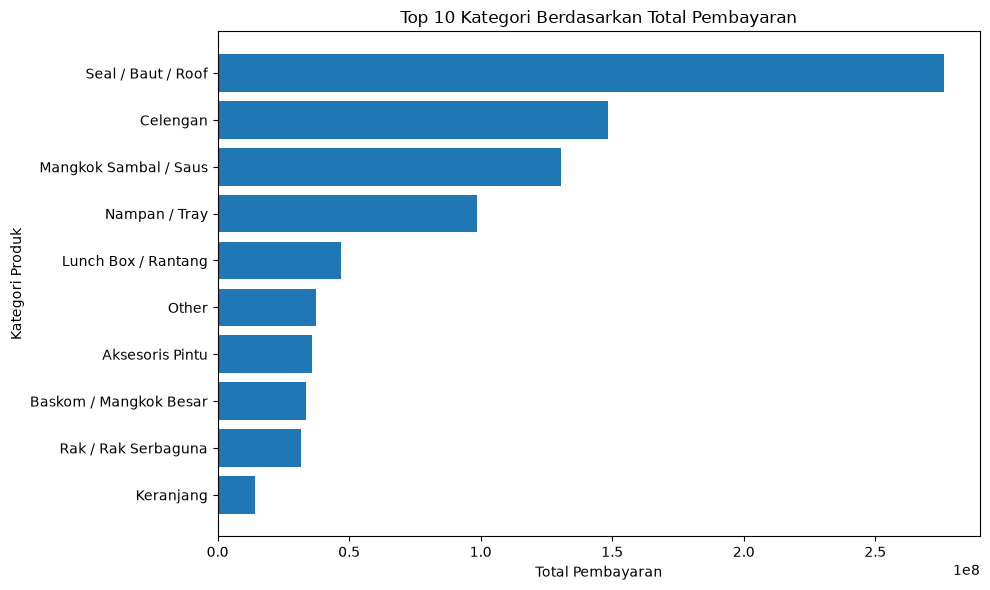


=== INSIGHT AWAL ===
✓ Kategori dengan total pembayaran tertinggi: Seal / Baut / Roof
  Total pembayaran: Rp 275,995,451
✓ Kategori dengan quantity tertinggi: Nampan / Tray
  Total quantity: 9,942 unit
✓ Kategori dengan return rate tertinggi: Mangkok Sambal / Saus, Pisau / Alat Potong, Plastik / Wadah Plastik, Toples / Sealware
  Return rate: 100.00%

KESIMPULAN STEP 8.7
✓ Distribusi kategori produk telah dianalisis.
✓ Performance kategori berdasarkan transaksi telah dihitung.
✓ Total quantity setiap kategori telah dianalisis.
✓ Total pembayaran setiap kategori telah dibandingkan.
✓ Return rate kategori telah dianalisis.
✓ Kategori dengan performa tertinggi telah diidentifikasi.
✓ Analisis bersifat eksploratif.
✓ Tidak dilakukan perubahan terhadap dataset.

✓ STEP 8.7 SELESAI


In [73]:
# ================================================================
# STEP 8.7 — PRODUCT & CATEGORY PERFORMANCE ANALYSIS
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 8.7 — PRODUCT & CATEGORY PERFORMANCE ANALYSIS")
print("=" * 70)

# ================================================================
# 1. INFORMASI DATASET
# ================================================================

print("\n=== INFORMASI DATASET ===")
print(f"DataFrame yang digunakan : df_final")
print(f"Jumlah transaksi         : {len(df_final):,}")
print(f"Jumlah kolom             : {df_final.shape[1]}")


# ================================================================
# 2. IDENTIFIKASI KOLOM KATEGORI
# ================================================================

print("\n=== IDENTIFIKASI KOLOM KATEGORI ===")

category_candidates = [
    "product_categories",
    "product_category",
    "category",
    "kategori_produk"
]

category_col = next(
    (col for col in category_candidates if col in df_final.columns),
    None
)

if category_col is None:
    print("⚠ Kolom kategori produk tidak ditemukan.")
    print("Kolom yang tersedia:")
    print(df_final.columns.tolist())
else:
    print(f"✓ Kolom kategori yang digunakan : {category_col}")


# ================================================================
# 3. DISTRIBUSI KATEGORI PRODUK
# ================================================================

if category_col is not None:

    print("\n" + "=" * 70)
    print("=== DISTRIBUSI KATEGORI PRODUK ===")
    print("=" * 70)

    category_distribution = (
        df_final[category_col]
        .value_counts(dropna=False)
        .reset_index()
    )

    category_distribution.columns = [
        "Kategori",
        "Jumlah_Transaksi"
    ]

    category_distribution["Persentase_%"] = (
        category_distribution["Jumlah_Transaksi"]
        / len(df_final) * 100
    ).round(2)

    print(category_distribution.head(15).to_string(index=False))


    # ============================================================
    # 4. PERFORMANCE BERDASARKAN KATEGORI
    # ============================================================

    print("\n" + "=" * 70)
    print("=== PERFORMANCE KATEGORI PRODUK ===")
    print("=" * 70)

    category_performance = (
        df_final
        .groupby(category_col, dropna=False)
        .agg(
            Jumlah_Transaksi=("order_id", "count")
            if "order_id" in df_final.columns
            else (category_col, "count"),

            Total_Quantity=("total_qty", "sum"),

            Total_Pembayaran=("Total Pembayaran", "sum"),

            Rata_Rata_Pembayaran=("Total Pembayaran", "mean"),

            Total_Return=("total_returned_qty", "sum")
            if "total_returned_qty" in df_final.columns
            else ("total_qty", "sum")
        )
        .reset_index()
    )

    category_performance["Persentase_Transaksi_%"] = (
        category_performance["Jumlah_Transaksi"]
        / len(df_final) * 100
    ).round(2)

    category_performance["Return_Rate_%"] = np.where(
        category_performance["Total_Quantity"] > 0,
        category_performance["Total_Return"]
        / category_performance["Total_Quantity"] * 100,
        0
    ).round(2)

    # Urutkan berdasarkan total pembayaran
    category_performance = category_performance.sort_values(
        "Total_Pembayaran",
        ascending=False
    )

    print(
        category_performance
        .head(15)
        .to_string(index=False)
    )


    # ============================================================
    # 5. TOP 10 KATEGORI BERDASARKAN TOTAL PEMBAYARAN
    # ============================================================

    print("\n" + "=" * 70)
    print("=== TOP 10 KATEGORI BERDASARKAN TOTAL PEMBAYARAN ===")
    print("=" * 70)

    top_category_payment = (
        category_performance
        .head(10)
        [[
            category_col,
            "Jumlah_Transaksi",
            "Total_Quantity",
            "Total_Pembayaran",
            "Rata_Rata_Pembayaran",
            "Return_Rate_%"
        ]]
    )

    print(top_category_payment.to_string(index=False))


    # ============================================================
    # 6. TOP 10 KATEGORI BERDASARKAN QUANTITY
    # ============================================================

    print("\n" + "=" * 70)
    print("=== TOP 10 KATEGORI BERDASARKAN QUANTITY ===")
    print("=" * 70)

    top_category_quantity = (
        category_performance
        .sort_values("Total_Quantity", ascending=False)
        .head(10)
        [[
            category_col,
            "Jumlah_Transaksi",
            "Total_Quantity",
            "Total_Pembayaran"
        ]]
    )

    print(top_category_quantity.to_string(index=False))


    # ============================================================
    # 7. KATEGORI DENGAN RETURN RATE TERTINGGI
    # ============================================================

    print("\n" + "=" * 70)
    print("=== KATEGORI DENGAN RETURN RATE TERTINGGI ===")
    print("=" * 70)

    top_return_category = (
        category_performance
        .sort_values("Return_Rate_%", ascending=False)
        .head(10)
        [[
            category_col,
            "Total_Quantity",
            "Total_Return",
            "Return_Rate_%"
        ]]
    )

    print(top_return_category.to_string(index=False))


    # ============================================================
    # 8. VISUALISASI
    # ============================================================

    plot_data = (
        category_performance
        .head(10)
        .sort_values("Total_Pembayaran")
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        plot_data[category_col].astype(str),
        plot_data["Total_Pembayaran"]
    )

    plt.title("Top 10 Kategori Berdasarkan Total Pembayaran")
    plt.xlabel("Total Pembayaran")
    plt.ylabel("Kategori Produk")
    plt.tight_layout()
    plt.show()


    # ============================================================
    # 9. INSIGHT OTOMATIS
    # ============================================================

    print("\n" + "=" * 70)
    print("=== INSIGHT AWAL ===")
    print("=" * 70)

    top_payment = category_performance.iloc[0]

    top_quantity = (
        category_performance
        .sort_values("Total_Quantity", ascending=False)
        .iloc[0]
    )

    top_return = (
        category_performance
        .sort_values("Return_Rate_%", ascending=False)
        .iloc[0]
    )

    print(
        f"✓ Kategori dengan total pembayaran tertinggi: "
        f"{top_payment[category_col]}"
    )

    print(
        f"  Total pembayaran: "
        f"Rp {top_payment['Total_Pembayaran']:,.0f}"
    )

    print(
        f"✓ Kategori dengan quantity tertinggi: "
        f"{top_quantity[category_col]}"
    )

    print(
        f"  Total quantity: "
        f"{top_quantity['Total_Quantity']:,.0f} unit"
    )

    print(
        f"✓ Kategori dengan return rate tertinggi: "
        f"{top_return[category_col]}"
    )

    print(
        f"  Return rate: "
        f"{top_return['Return_Rate_%']:.2f}%"
    )


# ================================================================
# 10. KESIMPULAN
# ================================================================

print("\n" + "=" * 70)
print("KESIMPULAN STEP 8.7")
print("=" * 70)

print("✓ Distribusi kategori produk telah dianalisis.")
print("✓ Performance kategori berdasarkan transaksi telah dihitung.")
print("✓ Total quantity setiap kategori telah dianalisis.")
print("✓ Total pembayaran setiap kategori telah dibandingkan.")
print("✓ Return rate kategori telah dianalisis.")
print("✓ Kategori dengan performa tertinggi telah diidentifikasi.")
print("✓ Analisis bersifat eksploratif.")
print("✓ Tidak dilakukan perubahan terhadap dataset.")

print("\n✓ STEP 8.7 SELESAI")
print("=" * 70)

STEP 8.8 — RETURN & OPERATIONAL PERFORMANCE ANALYSIS

=== INFORMASI DATASET ===
DataFrame yang digunakan : df_final
Jumlah transaksi        : 20,848
Jumlah kolom            : 20

=== IDENTIFIKASI KOLOM RETURN ===
✓ total_returned_qty
✓ return_rate
✓ total_qty

=== VALIDASI DATA RETURN ===
✓ Tipe total_returned_qty : int64
✓ Tipe total_qty : int64

=== RETURN PERFORMANCE KPI ===
Total transaksi              : 20,848
Total quantity               : 53,388
Total quantity diretur       : 370
Transaksi dengan return      : 157
Return rate berdasarkan qty  : 0.69%
Return rate transaksi        : 0.75%

=== DISTRIBUSI TRANSAKSI RETURN ===
          Status  Jumlah_Transaksi  Persentase_%
Tidak Ada Return             20691      99.24693
      Ada Return               157       0.75307

=== TOP 10 TRANSAKSI DENGAN RETURN TERBESAR ===
   order_id  total_qty  total_returned_qty  return_rate  Total Pembayaran                                                                     product_categories
ORD_0

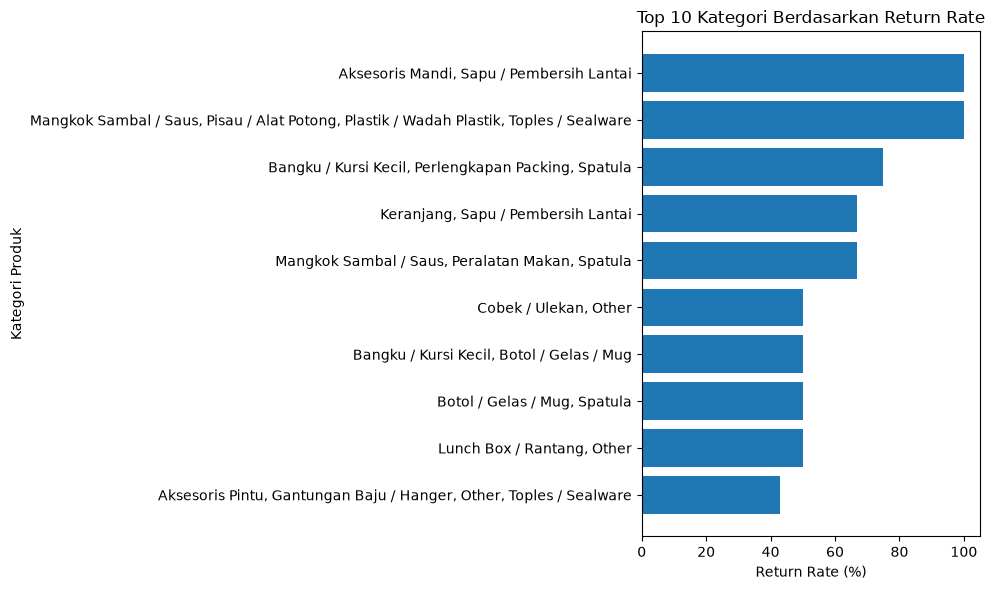

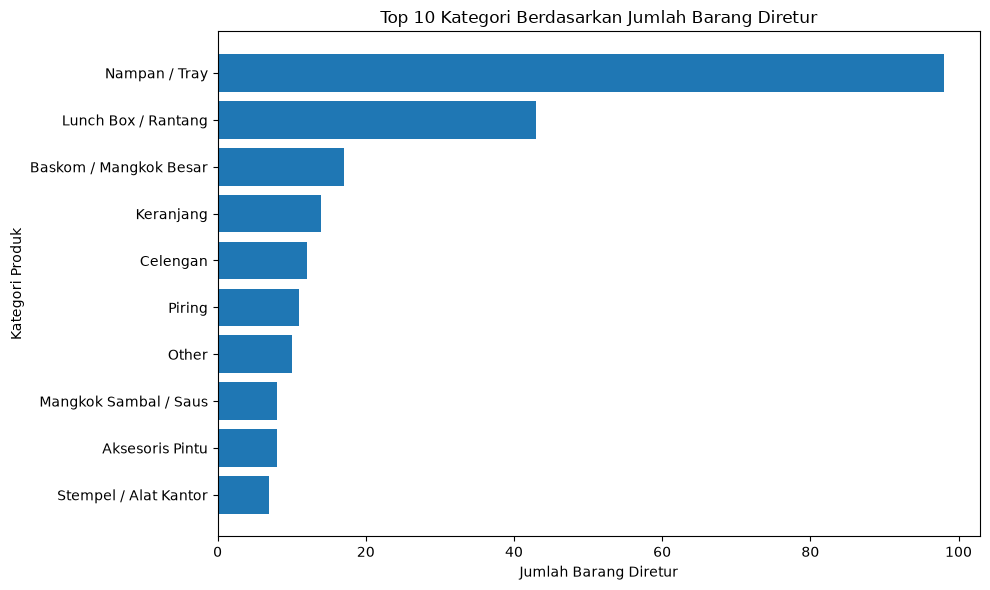


=== INSIGHT AWAL ===
✓ Total barang yang dianalisis sebanyak 53,388 unit.
✓ Total barang yang diretur sebanyak 370 unit.
✓ Return rate berdasarkan quantity sebesar 0.69%.
✓ Terdapat 157 transaksi yang memiliki return.
✓ Persentase transaksi yang memiliki return sebesar 0.75%.
✓ Kategori dengan jumlah return terbesar: Nampan / Tray (98 unit).
✓ Return rate tertinggi ditemukan pada kategori Mangkok Sambal / Saus, Pisau / Alat Potong, Plastik / Wadah Plastik, Toples / Sealware sebesar 100.00%.

=== CATATAN ANALITIS ===
✓ Return rate digunakan untuk melihat proporsi barang yang dikembalikan terhadap total quantity.
✓ Kategori dengan return rate tinggi perlu dibandingkan dengan jumlah transaksi dan quantity agar tidak bias akibat ukuran sampel kecil.
✓ Analisis pada tahap ini bersifat eksploratif.
✓ Tidak dilakukan penghapusan atau perubahan terhadap dataset.

KESIMPULAN STEP 8.8
✓ Return performance telah dianalisis.
✓ Total quantity dan total quantity return telah dihitung.
✓ Transaksi y

In [75]:
# ================================================================
# STEP 8.8 — RETURN & OPERATIONAL PERFORMANCE ANALYSIS
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 8.8 — RETURN & OPERATIONAL PERFORMANCE ANALYSIS")
print("=" * 70)


# ================================================================
# 1. INFORMASI DATASET
# ================================================================

print("\n=== INFORMASI DATASET ===")

print(f"DataFrame yang digunakan : df_final")
print(f"Jumlah transaksi        : {len(df_final):,}")
print(f"Jumlah kolom            : {df_final.shape[1]}")


# ================================================================
# 2. IDENTIFIKASI KOLOM
# ================================================================

print("\n=== IDENTIFIKASI KOLOM RETURN ===")

required_cols = [
    "total_returned_qty",
    "return_rate",
    "total_qty"
]

for col in required_cols:
    if col in df_final.columns:
        print(f"✓ {col}")
    else:
        print(f"⚠ {col} tidak ditemukan")


# ================================================================
# 3. VALIDASI DATA RETURN
# ================================================================

print("\n=== VALIDASI DATA RETURN ===")

return_qty_col = "total_returned_qty"
return_rate_col = "return_rate"
qty_col = "total_qty"

if return_qty_col not in df_final.columns:
    raise KeyError(
        "Kolom 'total_returned_qty' tidak ditemukan pada df_final."
    )

if qty_col not in df_final.columns:
    raise KeyError(
        "Kolom 'total_qty' tidak ditemukan pada df_final."
    )

# Pastikan numerik
return_qty = pd.to_numeric(
    df_final[return_qty_col],
    errors="coerce"
).fillna(0)

total_qty = pd.to_numeric(
    df_final[qty_col],
    errors="coerce"
).fillna(0)

print(f"✓ Tipe {return_qty_col} : {return_qty.dtype}")
print(f"✓ Tipe {qty_col} : {total_qty.dtype}")


# ================================================================
# 4. KPI RETURN
# ================================================================

print("\n" + "=" * 70)
print("=== RETURN PERFORMANCE KPI ===")
print("=" * 70)

total_transactions = len(df_final)

total_quantity = total_qty.sum()
total_returned = return_qty.sum()

transactions_with_return = (return_qty > 0).sum()

overall_return_rate = (
    total_returned / total_quantity
    if total_quantity > 0
    else 0
)

transaction_return_rate = (
    transactions_with_return / total_transactions
    if total_transactions > 0
    else 0
)

print(f"Total transaksi              : {total_transactions:,}")
print(f"Total quantity               : {total_quantity:,.0f}")
print(f"Total quantity diretur       : {total_returned:,.0f}")
print(f"Transaksi dengan return      : {transactions_with_return:,}")
print(f"Return rate berdasarkan qty  : {overall_return_rate:.2%}")
print(f"Return rate transaksi        : {transaction_return_rate:.2%}")


# ================================================================
# 5. DISTRIBUSI TRANSAKSI RETURN
# ================================================================

print("\n" + "=" * 70)
print("=== DISTRIBUSI TRANSAKSI RETURN ===")
print("=" * 70)

return_distribution = pd.DataFrame({
    "Status": [
        "Tidak Ada Return",
        "Ada Return"
    ],
    "Jumlah_Transaksi": [
        (return_qty == 0).sum(),
        (return_qty > 0).sum()
    ]
})

return_distribution["Persentase_%"] = (
    return_distribution["Jumlah_Transaksi"]
    / total_transactions
    * 100
)

print(return_distribution.to_string(index=False))


# ================================================================
# 6. TOP TRANSAKSI DENGAN RETURN TERBESAR
# ================================================================

print("\n" + "=" * 70)
print("=== TOP 10 TRANSAKSI DENGAN RETURN TERBESAR ===")
print("=" * 70)

available_cols = [
    col for col in [
        "order_id",
        "total_qty",
        "total_returned_qty",
        "return_rate",
        "Total Pembayaran",
        "product_categories"
    ]
    if col in df_final.columns
]

top_returns = (
    df_final[available_cols]
    .copy()
)

top_returns["_return_qty"] = pd.to_numeric(
    top_returns["total_returned_qty"],
    errors="coerce"
).fillna(0)

top_returns = (
    top_returns
    .sort_values("_return_qty", ascending=False)
    .head(10)
    .drop(columns="_return_qty")
)

print(top_returns.to_string(index=False))


# ================================================================
# 7. ANALISIS RETURN PER KATEGORI
# ================================================================

print("\n" + "=" * 70)
print("=== RETURN PERFORMANCE PER KATEGORI ===")
print("=" * 70)

category_col = "product_categories"

if category_col in df_final.columns:

    category_return = (
        df_final
        .groupby(category_col)
        .agg(
            Jumlah_Transaksi=(category_col, "size"),
            Total_Quantity=(qty_col, "sum"),
            Total_Returned=(return_qty_col, "sum")
        )
        .reset_index()
    )

    category_return["Return_Rate_%"] = np.where(
        category_return["Total_Quantity"] > 0,
        category_return["Total_Returned"]
        / category_return["Total_Quantity"]
        * 100,
        0
    )

    category_return = category_return.sort_values(
        "Return_Rate_%",
        ascending=False
    )

    print(
        category_return
        .head(15)
        .to_string(index=False)
    )

else:
    print("⚠ Kolom product_categories tidak ditemukan.")
    category_return = pd.DataFrame()


# ================================================================
# 8. KATEGORI DENGAN RETURN TERBANYAK
# ================================================================

print("\n" + "=" * 70)
print("=== TOP KATEGORI BERDASARKAN JUMLAH RETURN ===")
print("=" * 70)

if not category_return.empty:

    top_return_qty = (
        category_return
        .sort_values(
            "Total_Returned",
            ascending=False
        )
        .head(10)
    )

    print(
        top_return_qty[
            [
                category_col,
                "Jumlah_Transaksi",
                "Total_Quantity",
                "Total_Returned",
                "Return_Rate_%"
            ]
        ].to_string(index=False)
    )


# ================================================================
# 9. KATEGORI RETURN RATE TERTINGGI
# ================================================================

print("\n" + "=" * 70)
print("=== KATEGORI DENGAN RETURN RATE TERTINGGI ===")
print("=" * 70)

if not category_return.empty:

    high_return_categories = (
        category_return[
            category_return["Total_Returned"] > 0
        ]
        .sort_values(
            "Return_Rate_%",
            ascending=False
        )
        .head(10)
    )

    print(
        high_return_categories[
            [
                category_col,
                "Jumlah_Transaksi",
                "Total_Quantity",
                "Total_Returned",
                "Return_Rate_%"
            ]
        ].to_string(index=False)
    )


# ================================================================
# 10. VISUALISASI RETURN RATE PER KATEGORI
# ================================================================

if not category_return.empty:

    plot_data = (
        category_return[
            category_return["Total_Returned"] > 0
        ]
        .sort_values(
            "Return_Rate_%",
            ascending=True
        )
        .tail(10)
    )

    if len(plot_data) > 0:

        plt.figure(figsize=(10, 6))

        plt.barh(
            plot_data[category_col],
            plot_data["Return_Rate_%"]
        )

        plt.xlabel("Return Rate (%)")
        plt.ylabel("Kategori Produk")
        plt.title("Top 10 Kategori Berdasarkan Return Rate")

        plt.tight_layout()
        plt.show()


# ================================================================
# 11. VISUALISASI RETURN QUANTITY
# ================================================================

if not category_return.empty:

    plot_return_qty = (
        category_return
        .sort_values(
            "Total_Returned",
            ascending=True
        )
        .tail(10)
    )

    if len(plot_return_qty) > 0:

        plt.figure(figsize=(10, 6))

        plt.barh(
            plot_return_qty[category_col],
            plot_return_qty["Total_Returned"]
        )

        plt.xlabel("Jumlah Barang Diretur")
        plt.ylabel("Kategori Produk")
        plt.title("Top 10 Kategori Berdasarkan Jumlah Barang Diretur")

        plt.tight_layout()
        plt.show()


# ================================================================
# 12. INSIGHT AWAL
# ================================================================

print("\n" + "=" * 70)
print("=== INSIGHT AWAL ===")
print("=" * 70)

print(
    f"✓ Total barang yang dianalisis sebanyak "
    f"{total_quantity:,.0f} unit."
)

print(
    f"✓ Total barang yang diretur sebanyak "
    f"{total_returned:,.0f} unit."
)

print(
    f"✓ Return rate berdasarkan quantity sebesar "
    f"{overall_return_rate:.2%}."
)

print(
    f"✓ Terdapat {transactions_with_return:,} transaksi "
    f"yang memiliki return."
)

print(
    f"✓ Persentase transaksi yang memiliki return sebesar "
    f"{transaction_return_rate:.2%}."
)

if not category_return.empty:

    top_category_return = (
        category_return
        .sort_values(
            "Total_Returned",
            ascending=False
        )
        .iloc[0]
    )

    print(
        f"✓ Kategori dengan jumlah return terbesar: "
        f"{top_category_return[category_col]} "
        f"({top_category_return['Total_Returned']:,.0f} unit)."
    )

    positive_return = category_return[
        category_return["Total_Returned"] > 0
    ]

    if len(positive_return) > 0:

        highest_rate = (
            positive_return
            .sort_values(
                "Return_Rate_%",
                ascending=False
            )
            .iloc[0]
        )

        print(
            f"✓ Return rate tertinggi ditemukan pada kategori "
            f"{highest_rate[category_col]} "
            f"sebesar {highest_rate['Return_Rate_%']:.2f}%."
        )


# ================================================================
# 13. CATATAN ANALITIS
# ================================================================

print("\n" + "=" * 70)
print("=== CATATAN ANALITIS ===")
print("=" * 70)

print(
    "✓ Return rate digunakan untuk melihat proporsi barang "
    "yang dikembalikan terhadap total quantity."
)

print(
    "✓ Kategori dengan return rate tinggi perlu dibandingkan "
    "dengan jumlah transaksi dan quantity agar tidak bias "
    "akibat ukuran sampel kecil."
)

print(
    "✓ Analisis pada tahap ini bersifat eksploratif."
)

print(
    "✓ Tidak dilakukan penghapusan atau perubahan terhadap dataset."
)


# ================================================================
# 14. KESIMPULAN STEP 8.8
# ================================================================

print("\n" + "=" * 70)
print("KESIMPULAN STEP 8.8")
print("=" * 70)

print("✓ Return performance telah dianalisis.")
print("✓ Total quantity dan total quantity return telah dihitung.")
print("✓ Transaksi yang memiliki return telah diidentifikasi.")
print("✓ Return rate keseluruhan telah dihitung.")
print("✓ Performance return per kategori telah dianalisis.")
print("✓ Kategori dengan return terbesar telah diidentifikasi.")
print("✓ Visualisasi return telah dibuat.")
print("✓ Analisis tetap bersifat eksploratif.")
print("✓ Tidak dilakukan perubahan terhadap dataset.")
print("\n✓ STEP 8.8 SELESAI")

print("=" * 70)

In [77]:
# ================================================================
# STEP 8.9 — FINAL BUSINESS INSIGHT & RECOMMENDATION
# ================================================================

print("=" * 70)
print("STEP 8.9 — FINAL BUSINESS INSIGHT & RECOMMENDATION")
print("=" * 70)

# ================================================================
# 1. INFORMASI DATASET
# ================================================================

print("\n=== INFORMASI DATASET ===")

print(f"DataFrame yang digunakan : df_final")
print(f"Jumlah transaksi        : {len(df_final):,}")
print(f"Jumlah kolom            : {df_final.shape[1]}")

# ================================================================
# 2. KPI UTAMA
# ================================================================

total_transaksi = len(df_final)

total_qty = df_final["total_qty"].sum()

total_payment = df_final["Total Pembayaran"].sum()

avg_payment = df_final["Total Pembayaran"].mean()

median_payment = df_final["Total Pembayaran"].median()

total_discount = df_final["Total Diskon"].sum()

total_shipping = df_final["Perkiraan Ongkos Kirim"].sum()

total_returned = df_final["total_returned_qty"].sum()

return_transactions = (
    df_final["total_returned_qty"] > 0
).sum()

return_rate_qty = (
    total_returned / total_qty * 100
    if total_qty > 0 else 0
)

return_rate_transaction = (
    return_transactions / total_transaksi * 100
    if total_transaksi > 0 else 0
)

print("\n=== KPI UTAMA ===")

print(f"Total transaksi             : {total_transaksi:,}")
print(f"Total quantity              : {total_qty:,} unit")
print(f"Total pembayaran            : Rp {total_payment:,.2f}")
print(f"Rata-rata transaksi         : Rp {avg_payment:,.2f}")
print(f"Median transaksi            : Rp {median_payment:,.2f}")
print(f"Total diskon                : Rp {total_discount:,.2f}")
print(f"Total estimasi ongkos kirim : Rp {total_shipping:,.2f}")
print(f"Total quantity diretur      : {total_returned:,} unit")
print(f"Transaksi dengan return     : {return_transactions:,}")
print(f"Return rate quantity        : {return_rate_qty:.2f}%")
print(f"Return rate transaksi       : {return_rate_transaction:.2f}%")

# ================================================================
# 3. TOP KATEGORI BERDASARKAN PEMBAYARAN
# ================================================================

print("\n=== TOP KATEGORI BERDASARKAN TOTAL PEMBAYARAN ===")

category_payment = (
    df_final
    .groupby("product_categories")["Total Pembayaran"]
    .sum()
    .sort_values(ascending=False)
)

top_category_payment = category_payment.index[0]
top_category_payment_value = category_payment.iloc[0]

print(
    f"Kategori tertinggi : {top_category_payment}"
)
print(
    f"Total pembayaran  : Rp {top_category_payment_value:,.2f}"
)

# ================================================================
# 4. TOP KATEGORI BERDASARKAN QUANTITY
# ================================================================

print("\n=== TOP KATEGORI BERDASARKAN QUANTITY ===")

category_qty = (
    df_final
    .groupby("product_categories")["total_qty"]
    .sum()
    .sort_values(ascending=False)
)

top_category_qty = category_qty.index[0]
top_category_qty_value = category_qty.iloc[0]

print(f"Kategori tertinggi : {top_category_qty}")
print(f"Total quantity     : {top_category_qty_value:,} unit")

# ================================================================
# 5. TOP KATEGORI BERDASARKAN RETURN
# ================================================================

print("\n=== TOP KATEGORI BERDASARKAN RETURN ===")

category_return = (
    df_final
    .groupby("product_categories")["total_returned_qty"]
    .sum()
    .sort_values(ascending=False)
)

top_return_category = category_return.index[0]
top_return_value = category_return.iloc[0]

print(f"Kategori return terbesar : {top_return_category}")
print(f"Quantity return          : {top_return_value:,} unit")

# ================================================================
# 6. HUBUNGAN DENGAN TOTAL PEMBAYARAN
# ================================================================

print("\n=== VARIABEL TERKAIT TOTAL PEMBAYARAN ===")

correlation_columns = [
    "total_qty",
    "total_weight_gr",
    "Total Diskon",
    "Ongkos Kirim Dibayar oleh Pembeli",
    "Perkiraan Ongkos Kirim"
]

corr_result = {}

for col in correlation_columns:

    if col in df_final.columns:

        corr = df_final[[col, "Total Pembayaran"]].corr(
            method="spearman"
        ).iloc[0, 1]

        corr_result[col] = corr

for col, corr in sorted(
    corr_result.items(),
    key=lambda x: abs(x[1]),
    reverse=True
):

    print(f"{col:40s}: {corr:.3f}")

# ================================================================
# 7. IDENTIFIKASI HUBUNGAN TERKUAT
# ================================================================

if corr_result:

    strongest_variable = max(
        corr_result,
        key=lambda x: abs(corr_result[x])
    )

    strongest_corr = corr_result[strongest_variable]

    print("\nHubungan numerik terkuat:")
    print(f"{strongest_variable} → {strongest_corr:.3f}")

# ================================================================
# 8. INSIGHT BISNIS
# ================================================================

print("\n" + "=" * 70)
print("FINAL BUSINESS INSIGHTS")
print("=" * 70)

print(
    f"\n✓ Dataset mencakup {total_transaksi:,} transaksi "
    f"dengan total {total_qty:,} unit barang."
)

print(
    f"✓ Total nilai pembayaran mencapai "
    f"Rp {total_payment:,.2f}."
)

print(
    f"✓ Nilai rata-rata transaksi sebesar "
    f"Rp {avg_payment:,.2f}, sedangkan median sebesar "
    f"Rp {median_payment:,.2f}."
)

if avg_payment > median_payment:

    print(
        "✓ Mean lebih tinggi daripada median, "
        "menunjukkan distribusi transaksi cenderung "
        "dipengaruhi oleh transaksi bernilai tinggi."
    )

print(
    f"✓ Return rate berdasarkan quantity sebesar "
    f"{return_rate_qty:.2f}%."
)

print(
    f"✓ Kategori dengan total pembayaran tertinggi adalah "
    f"{top_category_payment}."
)

print(
    f"✓ Kategori dengan quantity terbesar adalah "
    f"{top_category_qty}."
)

print(
    f"✓ Kategori dengan jumlah return terbesar adalah "
    f"{top_return_category} dengan {top_return_value:,} unit."
)

if corr_result:

    print(
        f"✓ Variabel yang memiliki hubungan numerik terkuat "
        f"dengan Total Pembayaran adalah "
        f"{strongest_variable} "
        f"(Spearman = {strongest_corr:.3f})."
    )

# ================================================================
# 9. REKOMENDASI BISNIS
# ================================================================

print("\n" + "=" * 70)
print("REKOMENDASI BISNIS")
print("=" * 70)

print("""
1. Fokus mempertahankan performa kategori dengan kontribusi
   pembayaran dan quantity yang tinggi.

2. Lakukan monitoring khusus terhadap kategori dengan jumlah
   return tinggi.

3. Kategori dengan return rate sangat tinggi perlu diperiksa
   bersama jumlah transaksi dan quantity agar tidak terjadi
   kesimpulan yang bias akibat ukuran sampel kecil.

4. Transaksi bernilai tinggi perlu dipantau karena dapat
   memberikan pengaruh besar terhadap rata-rata nilai transaksi.

5. Hubungan antara quantity, berat barang, ongkos kirim,
   diskon, dan total pembayaran dapat digunakan sebagai dasar
   evaluasi strategi penjualan dan operasional.

6. Hasil analisis ini dapat digunakan sebagai dasar pembuatan
   dashboard business performance.
""")

# ================================================================
# 10. VALIDASI AKHIR
# ================================================================

print("=" * 70)
print("VALIDASI STEP 8.9")
print("=" * 70)

print("✓ KPI utama berhasil dirangkum.")
print("✓ Insight kategori berhasil dirangkum.")
print("✓ Return performance berhasil dirangkum.")
print("✓ Hubungan antarvariabel berhasil dirangkum.")
print("✓ Rekomendasi bisnis berhasil dibuat.")
print("✓ Tidak dilakukan perubahan terhadap dataset.")

print("\n✓ STEP 8.9 SELESAI")
print("=" * 70)

STEP 8.9 — FINAL BUSINESS INSIGHT & RECOMMENDATION

=== INFORMASI DATASET ===
DataFrame yang digunakan : df_final
Jumlah transaksi        : 20,848
Jumlah kolom            : 20

=== KPI UTAMA ===
Total transaksi             : 20,848
Total quantity              : 53,388 unit
Total pembayaran            : Rp 1,056,651,631.00
Rata-rata transaksi         : Rp 50,683.60
Median transaksi            : Rp 21,800.00
Total diskon                : Rp 8,447,596.00
Total estimasi ongkos kirim : Rp 384,137,458.00
Total quantity diretur      : 370 unit
Transaksi dengan return     : 157
Return rate quantity        : 0.69%
Return rate transaksi       : 0.75%

=== TOP KATEGORI BERDASARKAN TOTAL PEMBAYARAN ===
Kategori tertinggi : Seal / Baut / Roof
Total pembayaran  : Rp 275,995,451.00

=== TOP KATEGORI BERDASARKAN QUANTITY ===
Kategori tertinggi : Nampan / Tray
Total quantity     : 9,942 unit

=== TOP KATEGORI BERDASARKAN RETURN ===
Kategori return terbesar : Nampan / Tray
Quantity return          : 98 

In [ ]:
# ================================================================
# STEP 9 — FINAL DATA QUALITY VALIDATION
# ================================================================

# ================================================================
# STEP 9.1 — FINAL DATA QUALITY VALIDATION
# ================================================================


print("=" * 70)
print("STEP 9.1 — FINAL DATA QUALITY VALIDATION")
print("=" * 70)

# ------------------------------------------------
# 1. VALIDASI DATASET
# ------------------------------------------------

print("\n=== DATASET FINAL ===")

print(f"DataFrame              : df_final")
print(f"Jumlah transaksi       : {len(df_final):,}")
print(f"Jumlah kolom           : {df_final.shape[1]:,}")

# ------------------------------------------------
# 2. VALIDASI DUPLIKAT
# ------------------------------------------------

duplicate_count = df_final.duplicated().sum()

print("\n=== DUPLICATE CHECK ===")
print(f"Duplikat baris         : {duplicate_count:,}")

if duplicate_count == 0:
    print("✓ Tidak ditemukan duplicate row.")
else:
    print("⚠ Masih terdapat duplicate row.")

# ------------------------------------------------
# 3. VALIDASI MISSING VALUE
# ------------------------------------------------

missing_total = df_final.isna().sum().sum()

print("\n=== MISSING VALUE CHECK ===")
print(f"Total missing value    : {missing_total:,}")

if missing_total == 0:
    print("✓ Tidak terdapat missing value.")
else:
    print("⚠ Masih terdapat missing value.")

# ------------------------------------------------
# 4. VALIDASI KOLOM UTAMA
# ------------------------------------------------

required_columns = [
    "Total Pembayaran",
    "total_qty",
    "total_weight_gr",
    "Total Diskon",
    "total_returned_qty",
    "product_categories"
]

print("\n=== REQUIRED COLUMN CHECK ===")

missing_columns = [
    col for col in required_columns
    if col not in df_final.columns
]

if len(missing_columns) == 0:
    print("✓ Seluruh kolom utama tersedia.")
else:
    print("⚠ Kolom yang tidak ditemukan:")
    for col in missing_columns:
        print(f"  - {col}")

# ------------------------------------------------
# 5. VALIDASI NUMERIC COLUMN
# ------------------------------------------------

numeric_columns = [
    "Total Pembayaran",
    "total_qty",
    "total_weight_gr",
    "Total Diskon",
    "total_returned_qty"
]

print("\n=== NUMERIC COLUMN CHECK ===")

for col in numeric_columns:
    if col in df_final.columns:
        print(f"✓ {col:<35} {df_final[col].dtype}")

# ------------------------------------------------
# 6. FINAL KPI VALIDATION
# ------------------------------------------------

print("\n=== FINAL KPI VALIDATION ===")

total_transactions = len(df_final)

total_quantity = df_final["total_qty"].sum()

total_payment = df_final["Total Pembayaran"].sum()

average_transaction = df_final["Total Pembayaran"].mean()

median_transaction = df_final["Total Pembayaran"].median()

total_discount = df_final["Total Diskon"].sum()

total_returned = df_final["total_returned_qty"].sum()

return_rate_quantity = (
    total_returned / total_quantity
    if total_quantity > 0 else 0
)

return_transactions = (
    (df_final["total_returned_qty"] > 0).sum()
)

return_rate_transaction = (
    return_transactions / total_transactions
    if total_transactions > 0 else 0
)

print(f"Total transaksi       : {total_transactions:,}")
print(f"Total quantity        : {total_quantity:,}")
print(f"Total pembayaran      : Rp {total_payment:,.2f}")
print(f"Rata-rata transaksi   : Rp {average_transaction:,.2f}")
print(f"Median transaksi      : Rp {median_transaction:,.2f}")
print(f"Total diskon          : Rp {total_discount:,.2f}")
print(f"Total quantity return : {total_returned:,}")
print(f"Return rate quantity  : {return_rate_quantity:.2%}")
print(f"Transaksi dengan return: {return_transactions:,}")
print(f"Return rate transaksi : {return_rate_transaction:.2%}")

# ------------------------------------------------
# 7. VALIDASI NILAI NEGATIF
# ------------------------------------------------

print("\n=== NEGATIVE VALUE CHECK ===")

negative_found = False

for col in numeric_columns:
    if col in df_final.columns:
        negative_count = (df_final[col] < 0).sum()

        if negative_count > 0:
            print(f"⚠ {col}: {negative_count:,} nilai negatif")
            negative_found = True

if not negative_found:
    print("✓ Tidak ditemukan nilai negatif pada kolom numerik utama.")

# ------------------------------------------------
# 8. FINAL STATUS
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION STATUS")
print("=" * 70)

if (
    duplicate_count == 0
    and missing_total == 0
    and len(missing_columns) == 0
    and not negative_found
):
    print("✓ DATA FINAL VALID")
    print("✓ KPI FINAL BERHASIL DIHITUNG")
    print("✓ DATASET SIAP UNTUK FINAL REPORT / DASHBOARD")
else:
    print("⚠ DATASET MASIH MEMERLUKAN REVIEW")

print("\n✓ STEP 9.1 SELESAI")
print("=" * 70)

STEP 9.1 — FINAL DATA VALIDATION

=== DATASET FINAL ===
DataFrame              : df_final
Jumlah transaksi       : 20,848
Jumlah kolom           : 20

=== DUPLICATE CHECK ===
Duplikat baris         : 0
✓ Tidak ditemukan duplicate row.

=== MISSING VALUE CHECK ===
Total missing value    : 19,998
⚠ Masih terdapat missing value.

=== REQUIRED COLUMN CHECK ===
✓ Seluruh kolom utama tersedia.

=== NUMERIC COLUMN CHECK ===
✓ Total Pembayaran                    int64
✓ total_qty                           int64
✓ total_weight_gr                     int64
✓ Total Diskon                        int64
✓ total_returned_qty                  int64

=== FINAL KPI VALIDATION ===
Total transaksi       : 20,848
Total quantity        : 53,388
Total pembayaran      : Rp 1,056,651,631.00
Rata-rata transaksi   : Rp 50,683.60
Median transaksi      : Rp 21,800.00
Total diskon          : Rp 8,447,596.00
Total quantity return : 370
Return rate quantity  : 0.69%
Transaksi dengan return: 157
Return rate transaksi 

STEP 9.1 — FINAL DATA QUALITY VALIDATION

=== DATASET FINAL ===
DataFrame              : df_final
Jumlah transaksi       : 20,848
Jumlah kolom           : 20

=== DUPLICATE CHECK ===
Duplikat baris         : 0
✓ Tidak ditemukan duplicate row.

=== MISSING VALUE CHECK ===
Total missing value    : 19,998
⚠ Masih terdapat missing value.

=== REQUIRED COLUMN CHECK ===
✓ Seluruh kolom utama tersedia.

=== NUMERIC COLUMN CHECK ===
✓ Total Pembayaran                    int64
✓ total_qty                           int64
✓ total_weight_gr                     int64
✓ Total Diskon                        int64
✓ total_returned_qty                  int64

=== FINAL KPI VALIDATION ===
Total transaksi       : 20,848
Total quantity        : 53,388
Total pembayaran      : Rp 1,056,651,631.00
Rata-rata transaksi   : Rp 50,683.60
Median transaksi      : Rp 21,800.00
Total diskon          : Rp 8,447,596.00
Total quantity return : 370
Return rate quantity  : 0.69%
Transaksi dengan return: 157
Return rate tr

In [87]:
# ================================================================
# STEP 9.1.1 — FINAL MISSING VALUE DIAGNOSTIC
# ================================================================

print("=" * 70)
print("STEP 9.1.1 — FINAL MISSING VALUE DIAGNOSTIC")
print("=" * 70)

missing_report = pd.DataFrame({
    "Missing_Count": df_final.isna().sum(),
    "Missing_Percentage": (
        df_final.isna().mean() * 100
    )
})

missing_report = (
    missing_report[
        missing_report["Missing_Count"] > 0
    ]
    .sort_values("Missing_Count", ascending=False)
)

print("\n=== MISSING VALUE PER COLUMN ===")

if len(missing_report) == 0:
    print("✓ Tidak terdapat missing value.")
else:
    print(missing_report.to_string())

print("\n=== TOTAL ===")

print(
    f"Total missing value : "
    f"{df_final.isna().sum().sum():,}"
)

print("\n" + "=" * 70)
print("✓ STEP 9.1.1 SELESAI")
print("=" * 70)

STEP 9.1.1 — FINAL MISSING VALUE DIAGNOSTIC

=== MISSING VALUE PER COLUMN ===
                      Missing_Count  Missing_Percentage
Alasan Pembatalan             18018           86.425556
Waktu Pesanan Dibuat           1980            9.497314

=== TOTAL ===
Total missing value : 19,998

✓ STEP 9.1.1 SELESAI


In [92]:
# ================================================================
# STEP 9.1.2 — MISSING VALUE BUSINESS CONTEXT VALIDATION
# ================================================================

print("=" * 70)
print("STEP 9.1.2 — BUSINESS CONTEXT VALIDATION")
print("=" * 70)

# Cari kolom yang berkaitan dengan status pesanan
print("\n=== KOLOM YANG BERKAITAN DENGAN STATUS ===")

status_candidates = [
    col for col in df_final.columns
    if any(
        keyword in col.lower()
        for keyword in ["status", "batal", "cancel"]
    )
]

for col in status_candidates:
    print(f"✓ {col}")

# ------------------------------------------------
# ANALISIS ALASAN PEMBATALAN
# ------------------------------------------------

if "Alasan Pembatalan" in df_final.columns:

    print("\n=== DISTRIBUSI ALASAN PEMBATALAN ===")

    print(
        df_final["Alasan Pembatalan"]
        .value_counts(dropna=False)
        .head(15)
    )

# ------------------------------------------------
# ANALISIS WAKTU PESANAN
# ------------------------------------------------

if "Waktu Pesanan Dibuat" in df_final.columns:

    print("\n=== WAKTU PESANAN DIBUAT ===")

    missing_time = df_final["Waktu Pesanan Dibuat"].isna().sum()
    total_data = len(df_final)

    print(f"Total transaksi       : {total_data:,}")
    print(f"Missing waktu         : {missing_time:,}")
    print(
        f"Persentase missing    : "
        f"{missing_time / total_data:.2%}"
    )

# ------------------------------------------------
# STATUS FINAL
# ------------------------------------------------

print("\n" + "=" * 70)
print("✓ STEP 9.1.2 SELESAI")
print("=" * 70)

STEP 9.1.2 — BUSINESS CONTEXT VALIDATION

=== KOLOM YANG BERKAITAN DENGAN STATUS ===
✓ Status Pesanan
✓ Alasan Pembatalan

=== DISTRIBUSI ALASAN PEMBATALAN ===
Alasan Pembatalan
NaN                                                                                              18018
Dibatalkan oleh Pembeli. Alasan: Lainnya/ berubah pikiran                                          662
Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan yang Ada                                             558
Dibatalkan secara otomatis oleh sistem. Alasan: Pesanan belum dibayar                              447
Dibatalkan oleh Pembeli. Alasan: Need to change delivery address                                   306
Dibatalkan secara otomatis oleh sistem. Alasan: Pengiriman gagal                                   255
Dibatalkan secara otomatis oleh sistem. Alasan: Penjual gagal mengirimkan pesanan tepat waktu      113
Dibatalkan oleh Pembeli. Alasan: Perlu mengubah pesanan                                            11

In [93]:
# ================================================================
# STEP 9.1.3 — CANCELLATION & ORDER TIME MISSING LOGIC VALIDATION
# ================================================================

print("=" * 70)
print("STEP 9.1.3 — CANCELLATION & ORDER TIME MISSING LOGIC VALIDATIONG")
print("=" * 70)


# ================================================================
# 1. VALIDASI MISSING ALASAN PEMBATALAN
# ================================================================

status_col = "Status Pesanan"
cancel_reason_col = "Alasan Pembatalan"

print("\n=== VALIDASI ALASAN PEMBATALAN ===")

if status_col in df_final.columns and cancel_reason_col in df_final.columns:

    # Missing alasan pembatalan
    missing_reason = df_final[cancel_reason_col].isna()

    # Status pesanan
    status_distribution = (
        df_final.loc[missing_reason, status_col]
        .value_counts(dropna=False)
    )

    print("\nStatus Pesanan pada data dengan Alasan Pembatalan kosong:")
    print(status_distribution)

    print(
        f"\nTotal missing Alasan Pembatalan : "
        f"{missing_reason.sum():,}"
    )


# ================================================================
# 2. CEK APAKAH PESANAN YANG TIDAK DIBATALKAN
#    MEMILIKI ALASAN PEMBATALAN KOSONG
# ================================================================

print("\n=== VALIDASI LOGIKA PEMBATALAN ===")

if status_col in df_final.columns and cancel_reason_col in df_final.columns:

    status_text = (
        df_final[status_col]
        .astype(str)
        .str.lower()
    )

    # Identifikasi status yang mengandung kata batal
    is_cancelled = status_text.str.contains(
        "batal|cancel",
        regex=True,
        na=False
    )

    # Pesanan batal tetapi alasan kosong
    cancelled_without_reason = (
        is_cancelled &
        df_final[cancel_reason_col].isna()
    )

    # Pesanan tidak batal tetapi memiliki alasan
    non_cancelled_with_reason = (
        ~is_cancelled &
        df_final[cancel_reason_col].notna()
    )

    print(
        "Pesanan dibatalkan tetapi alasan kosong :",
        cancelled_without_reason.sum()
    )

    print(
        "Pesanan tidak dibatalkan tetapi memiliki alasan :",
        non_cancelled_with_reason.sum()
    )


# ================================================================
# 3. VALIDASI MISSING WAKTU PESANAN DIBUAT
# ================================================================

time_col = "Waktu Pesanan Dibuat"

print("\n=== VALIDASI WAKTU PESANAN ===")

if time_col in df_final.columns:

    missing_time = df_final[time_col].isna()

    print(
        f"Total missing {time_col} : "
        f"{missing_time.sum():,}"
    )

    print(
        f"Persentase missing        : "
        f"{missing_time.mean() * 100:.2f}%"
    )


# ================================================================
# 4. RINGKASAN MISSING VALUE
# ================================================================

print("\n=== RINGKASAN VALIDASI MISSING ===")

missing_summary = (
    df_final.isna()
    .sum()
    .reset_index()
)

missing_summary.columns = [
    "Kolom",
    "Missing_Count"
]

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"]
    / len(df_final)
    * 100
)

missing_summary = (
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
    .sort_values(
        "Missing_Count",
        ascending=False
    )
)

print(missing_summary.to_string(index=False))


# ================================================================
# 5. BUSINESS INTERPRETATION
# ================================================================

print("\n=== INTERPRETASI BISNIS ===")

if cancel_reason_col in df_final.columns:

    print(
        "✓ Missing pada Alasan Pembatalan telah diperiksa "
        "berdasarkan Status Pesanan."
    )

if time_col in df_final.columns:

    print(
        "✓ Missing pada Waktu Pesanan Dibuat telah "
        "diidentifikasi untuk evaluasi kualitas data."
    )

if (
    status_col in df_final.columns
    and cancel_reason_col in df_final.columns
):

    print(
        f"✓ Pesanan batal tanpa alasan tercatat: "
        f"{cancelled_without_reason.sum():,}."
    )

    print(
        f"✓ Pesanan tidak batal tetapi memiliki alasan: "
        f"{non_cancelled_with_reason.sum():,}."
    )


# ================================================================
# 6. KESIMPULAN
# ================================================================

print("\n" + "=" * 70)
print("KESIMPULAN STEP 9.1.3")
print("=" * 70)

print("✓ Missing value telah divalidasi berdasarkan konteks bisnis.")
print("✓ Kolom Alasan Pembatalan telah dibandingkan dengan Status Pesanan.")
print("✓ Missing Waktu Pesanan Dibuat telah diperiksa.")
print("✓ Potensi missing yang tidak konsisten telah diidentifikasi.")
print("✓ Tidak dilakukan penghapusan atau perubahan terhadap dataset.")

print("\n✓ STEP 9.1.3 SELESAI")
print("=" * 70)

STEP 9.1.3 — CANCELLATION & ORDER TIME MISSING LOGIC VALIDATIONG

=== VALIDASI ALASAN PEMBATALAN ===

Status Pesanan pada data dengan Alasan Pembatalan kosong:
Status Pesanan
Selesai                                                                                   17768
Sedang Dikirim                                                                               59
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-08.       38
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-06.       34
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-07.       34
Telah Dikirim                                                                                30
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-05.       25
Pesanan diterima, namun Pembeli masih dapat mengajukan pengembalian hingga 2025-12-09.       22
Pesanan diterima, namun Pembeli masih dapat mengajukan pe

In [94]:
# ================================================================
# STEP 9.1.4 — ORDER CREATION TIME MISSING IMPACT VALIDATION
# ================================================================

print("=" * 70)
print("STEP 9.1.4 — ORDER CREATION TIME MISSING IMPACT VALIDATION")
print("=" * 70)


# ================================================================
# 1. IDENTIFIKASI KOLOM
# ================================================================

time_col = "Waktu Pesanan Dibuat"
status_col = "Status Pesanan"

print("\n=== IDENTIFIKASI KOLOM ===")

if time_col in df_final.columns:
    print(f"✓ Kolom ditemukan : {time_col}")
else:
    print(f"✗ Kolom tidak ditemukan : {time_col}")


# ================================================================
# 2. JUMLAH MISSING
# ================================================================

print("\n=== MISSING VALUE ===")

missing_time = df_final[time_col].isna()

missing_count = missing_time.sum()
missing_percentage = missing_time.mean() * 100

print(f"Total missing              : {missing_count:,}")
print(f"Persentase missing         : {missing_percentage:.2f}%")


# ================================================================
# 3. DISTRIBUSI STATUS PESANAN PADA DATA MISSING
# ================================================================

print("\n=== STATUS PESANAN PADA DATA DENGAN WAKTU KOSONG ===")

if status_col in df_final.columns:

    status_missing_time = (
        df_final.loc[missing_time, status_col]
        .value_counts(dropna=False)
    )

    print(status_missing_time)


# ================================================================
# 4. CEK APAKAH MISSING TERKONSENTRASI PADA STATUS TERTENTU
# ================================================================

print("\n=== PROPORSI MISSING BERDASARKAN STATUS ===")

if status_col in df_final.columns:

    status_total = df_final[status_col].value_counts(dropna=False)

    status_missing = (
        df_final.loc[missing_time, status_col]
        .value_counts(dropna=False)
    )

    status_validation = pd.DataFrame({
        "Total_Transaksi": status_total,
        "Missing_Waktu": status_missing
    }).fillna(0)

    status_validation["Missing_Percentage"] = (
        status_validation["Missing_Waktu"]
        / status_validation["Total_Transaksi"]
        * 100
    )

    status_validation = status_validation.sort_values(
        "Missing_Waktu",
        ascending=False
    )

    print(status_validation)


# ================================================================
# 5. CEK TIPE DATA
# ================================================================

print("\n=== TIPE DATA ===")

print(
    f"Tipe data {time_col} : "
    f"{df_final[time_col].dtype}"
)


# ================================================================
# 6. CEK DATA WAKTU YANG VALID
# ================================================================

print("\n=== VALIDASI DATA WAKTU ===")

valid_time_count = df_final[time_col].notna().sum()

print(
    f"Data waktu tersedia : {valid_time_count:,}"
)

print(
    f"Data waktu missing  : {missing_count:,}"
)


# ================================================================
# 7. BUSINESS IMPACT
# ================================================================

print("\n=== BUSINESS IMPACT ===")

print(
    "Kolom Waktu Pesanan Dibuat diperlukan untuk analisis "
    "berbasis waktu seperti tren harian, bulanan, dan periode transaksi."
)

print(
    f"Dari {len(df_final):,} transaksi, "
    f"{missing_count:,} transaksi ({missing_percentage:.2f}%) "
    f"tidak memiliki informasi waktu pesanan."
)


# ================================================================
# 8. KEPUTUSAN DATA QUALITY
# ================================================================

print("\n=== KEPUTUSAN DATA QUALITY ===")

if missing_percentage == 0:

    print(
        "✓ Tidak ditemukan missing value pada "
        "Waktu Pesanan Dibuat."
    )

elif missing_percentage < 10:

    print(
        "⚠ Missing value berada di bawah 10%."
    )

    print(
        "✓ Data tetap dapat digunakan untuk analisis "
        "non-time-series."
    )

    print(
        "⚠ Analisis berbasis waktu perlu memperhatikan "
        "data yang tidak memiliki timestamp."
    )

else:

    print(
        "⚠ Missing value cukup tinggi dan perlu "
        "perhatian khusus untuk analisis berbasis waktu."
    )


# ================================================================
# 9. KESIMPULAN
# ================================================================

print("\n" + "=" * 70)
print("KESIMPULAN STEP 9.1.4")
print("=" * 70)

print(
    f"✓ Missing Waktu Pesanan Dibuat: "
    f"{missing_count:,} ({missing_percentage:.2f}%)."
)

print(
    "✓ Distribusi missing berdasarkan Status Pesanan "
    "telah diperiksa."
)

print(
    "✓ Dampak missing terhadap analisis berbasis waktu "
    "telah diidentifikasi."
)

print(
    "✓ Tidak dilakukan imputasi, penghapusan, "
    "atau perubahan terhadap dataset."
)

print(
    "✓ Missing akan dipertahankan sebagai bagian "
    "dari kondisi asli dataset."
)

print("\n✓ STEP 9.1.4 SELESAI")
print("=" * 70)

STEP 9.1.4 — ORDER CREATION TIME MISSING IMPACT VALIDATION

=== IDENTIFIKASI KOLOM ===
✓ Kolom ditemukan : Waktu Pesanan Dibuat

=== MISSING VALUE ===
Total missing              : 1,980
Persentase missing         : 9.50%

=== STATUS PESANAN PADA DATA DENGAN WAKTU KOSONG ===
Status Pesanan
Selesai    1723
Batal       257
Name: count, dtype: int64

=== PROPORSI MISSING BERDASARKAN STATUS ===
                                                    Total_Transaksi  \
Status Pesanan                                                        
Selesai                                                       17768   
Batal                                                          2830   
Pesanan diterima, namun Pembeli masih dapat men...               25   
Pesanan diterima, namun Pembeli masih dapat men...               34   
Pesanan diterima, namun Pembeli masih dapat men...               34   
Pesanan diterima, namun Pembeli masih dapat men...               22   
Pesanan diterima, namun Pembeli masih d

In [95]:
# ================================================================
#  STEP 9.2 — FINAL DATA QUALITY DECISION
# ================================================================

print("=" * 70)
print(" STEP 9.2 — FINAL DATA QUALITY DECISION")
print("=" * 70)

# ------------------------------------------------
# 1. KPI UTAMA
# ------------------------------------------------

total_transaksi = len(df_final)

total_qty = df_final["total_qty"].sum()

total_pembayaran = df_final["Total Pembayaran"].sum()

total_diskon = df_final["Total Diskon"].sum()

total_returned = df_final["total_returned_qty"].sum()

return_rate_qty = (
    total_returned / total_qty
    if total_qty > 0 else 0
)

return_transactions = (
    (df_final["total_returned_qty"] > 0).sum()
)

return_rate_transaction = (
    return_transactions / total_transaksi
    if total_transaksi > 0 else 0
)

average_transaction = (
    total_pembayaran / total_transaksi
    if total_transaksi > 0 else 0
)

median_transaction = df_final["Total Pembayaran"].median()


# ------------------------------------------------
# 2. TOP CATEGORY BERDASARKAN PEMBAYARAN
# ------------------------------------------------

category_payment = (
    df_final.groupby("product_categories")["Total Pembayaran"]
    .sum()
    .sort_values(ascending=False)
)

top_payment_category = category_payment.index[0]
top_payment_value = category_payment.iloc[0]


# ------------------------------------------------
# 3. TOP CATEGORY BERDASARKAN QUANTITY
# ------------------------------------------------

category_qty = (
    df_final.groupby("product_categories")["total_qty"]
    .sum()
    .sort_values(ascending=False)
)

top_qty_category = category_qty.index[0]
top_qty_value = category_qty.iloc[0]


# ------------------------------------------------
# 4. TOP CATEGORY RETURN
# ------------------------------------------------

category_return = (
    df_final.groupby("product_categories")
    .agg(
        total_qty=("total_qty", "sum"),
        returned_qty=("total_returned_qty", "sum")
    )
)

category_return["return_rate"] = (
    category_return["returned_qty"]
    / category_return["total_qty"]
    * 100
)

category_return = category_return[
    category_return["total_qty"] > 0
]

top_return_category = (
    category_return["return_rate"]
    .sort_values(ascending=False)
    .index[0]
)

top_return_rate = (
    category_return["return_rate"]
    .sort_values(ascending=False)
    .iloc[0]
)


# ------------------------------------------------
# 5. TAMPILKAN FINAL KPI
# ------------------------------------------------

print("\n=== FINAL KPI ===")

print(f"Total transaksi              : {total_transaksi:,}")
print(f"Total quantity               : {total_qty:,} unit")
print(f"Total pembayaran             : Rp {total_pembayaran:,.2f}")
print(f"Rata-rata transaksi          : Rp {average_transaction:,.2f}")
print(f"Median transaksi             : Rp {median_transaction:,.2f}")
print(f"Total diskon                 : Rp {total_diskon:,.2f}")
print(f"Total quantity diretur       : {total_returned:,} unit")
print(f"Transaksi dengan return      : {return_transactions:,}")
print(f"Return rate quantity         : {return_rate_qty * 100:.2f}%")
print(f"Return rate transaksi        : {return_rate_transaction * 100:.2f}%")


# ------------------------------------------------
# 6. BUSINESS INSIGHT
# ------------------------------------------------

print("\n=== FINAL BUSINESS INSIGHT ===")

print(
    f"✓ Dataset mencakup {total_transaksi:,} transaksi "
    f"dengan total {total_qty:,} unit barang."
)

print(
    f"✓ Total nilai pembayaran mencapai "
    f"Rp {total_pembayaran:,.2f}."
)

print(
    f"✓ Nilai rata-rata transaksi sebesar "
    f"Rp {average_transaction:,.2f}, "
    f"sedangkan median sebesar Rp {median_transaction:,.2f}."
)

print(
    f"✓ Kategori dengan total pembayaran tertinggi adalah "
    f"'{top_payment_category}' dengan nilai "
    f"Rp {top_payment_value:,.2f}."
)

print(
    f"✓ Kategori dengan jumlah quantity tertinggi adalah "
    f"'{top_qty_category}' dengan total "
    f"{top_qty_value:,} unit."
)

print(
    f"✓ Total barang yang diretur sebanyak "
    f"{total_returned:,} unit."
)

print(
    f"✓ Terdapat {return_transactions:,} transaksi "
    f"yang memiliki return."
)

print(
    f"✓ Return rate berdasarkan quantity sebesar "
    f"{return_rate_qty * 100:.2f}%."
)

print(
    f"✓ Return rate berdasarkan transaksi sebesar "
    f"{return_rate_transaction * 100:.2f}%."
)

print(
    f"✓ Kategori dengan return rate tertinggi adalah "
    f"'{top_return_category}' sebesar "
    f"{top_return_rate:.2f}%."
)


# ------------------------------------------------
# 7. KESIMPULAN
# ------------------------------------------------

print("\n" + "=" * 70)
print("KESIMPULAN STEP 9.2")
print("=" * 70)

print("✓ KPI bisnis utama telah dirangkum.")
print("✓ Performance pembayaran telah dirangkum.")
print("✓ Performance kategori produk telah dirangkum.")
print("✓ Return performance telah dirangkum.")
print("✓ Insight bisnis utama telah diidentifikasi.")
print("✓ Analisis bersifat eksploratif.")
print("✓ Tidak dilakukan perubahan terhadap dataset.")

print("\n✓ STEP 9.2 SELESAI")
print("=" * 70)

 STEP 9.2 — FINAL DATA QUALITY DECISION

=== FINAL KPI ===
Total transaksi              : 20,848
Total quantity               : 53,388 unit
Total pembayaran             : Rp 1,056,651,631.00
Rata-rata transaksi          : Rp 50,683.60
Median transaksi             : Rp 21,800.00
Total diskon                 : Rp 8,447,596.00
Total quantity diretur       : 370 unit
Transaksi dengan return      : 157
Return rate quantity         : 0.69%
Return rate transaksi        : 0.75%

=== FINAL BUSINESS INSIGHT ===
✓ Dataset mencakup 20,848 transaksi dengan total 53,388 unit barang.
✓ Total nilai pembayaran mencapai Rp 1,056,651,631.00.
✓ Nilai rata-rata transaksi sebesar Rp 50,683.60, sedangkan median sebesar Rp 21,800.00.
✓ Kategori dengan total pembayaran tertinggi adalah 'Seal / Baut / Roof' dengan nilai Rp 275,995,451.00.
✓ Kategori dengan jumlah quantity tertinggi adalah 'Nampan / Tray' dengan total 9,942 unit.
✓ Total barang yang diretur sebanyak 370 unit.
✓ Terdapat 157 transaksi yang memili